# A Deep Reinforcement Learning Framework for Multi-Year Sustainable Crop Planning under Uncertainty

Pooja Balakumar
A00029779
MSc Data Science

This notebook presents the final implementation and evaluation framework for sustainable crop planning under uncertainty using Reinforcement Learning and model-based optimisation methods.

Key components included:

PPO sensitivity analysis for n_epochs values of 10, 100, 1000, and 10000 using a controlled diagnostic configuration.
Computational analysis explaining the impact of extremely large PPO epoch values on runtime efficiency.
Learned policy and action-behaviour analysis for all implemented algorithms.
Tree-allocation experiments reporting planted tree types and planting years.
Actor-Critic, Policy Gradient, Dynamic Programming, Q-Learning, and SARSA baseline implementations.
Experiment 3 configured with exactly two tree investments and at most two annual crops.
Compact discrete action-space configuration using land bins [15, 15, 20, 20, 30].
Long-term 30-year agricultural planning horizon with delayed tree-revenue modelling from year 4 onward.

This final submission focuses on:

long-term agricultural sustainability,
stochastic economic modelling,
weather-risk adaptation,
reinforcement learning policy optimisation,
and comparative evaluation of classical and deep reinforcement learning methods.

In [ ]:
# =============================================================================
# CELL 1: Install and Import Required Packages
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell installs and imports all required Python libraries used throughout
# the dissertation project.
#
# The project investigates sustainable crop allocation strategies using:
#
# - Reinforcement Learning (RL)
# - Deep Reinforcement Learning (DRL)
# - Policy Gradient methods
# - Dynamic Programming
#
# The imported libraries support:
#
# - Custom environment simulation
# - Numerical computation
# - Deep learning
# - Reinforcement learning algorithms
# - Data analysis
# - Statistical evaluation
# - Visualisation and reporting
#
# =============================================================================
# Step 1: Install Required External Libraries
# =============================================================================
#
# The following libraries are installed for the dissertation experiments:
#
# gymnasium:
#   Framework used to create custom reinforcement learning environments.
#
# stable-baselines3:
#   Provides implementations of DRL algorithms including PPO, DQN, and A2C.
#
# shimmy:
#   Compatibility support between Gym and Gymnasium environments.
#
# pandas:
#   Used for tabular data analysis and result storage.
#
# numpy:
#   Core numerical computation library.
#
# matplotlib:
#   Used for graphs and experiment visualisation.
#
# openpyxl:
#   Enables Excel export functionality.
#
# lxml and html5lib:
#   Support structured HTML/XML parsing utilities.
# =============================================================================

!pip install -q gymnasium stable-baselines3 shimmy pandas numpy matplotlib openpyxl lxml html5lib


# =============================================================================
# Step 2: Import Standard Python Libraries
# =============================================================================

# os:
#   Used for file and directory operations.
import os

# random:
#   Used for stochastic simulations and reproducibility.
import random

# itertools:
#   Used to generate combinations and permutations.
import itertools

# collections:
#   Provides specialised container datatypes.
import collections

# math:
#   Provides mathematical functions and utilities.
import math

# lru_cache:
#   Used to cache repeated computations for improved efficiency.
from functools import lru_cache


# =============================================================================
# Step 3: Import Numerical Computation Libraries
# =============================================================================

# numpy:
#   Core numerical computing library used throughout the dissertation.
import numpy as np

# pandas:
#   Used for structured data analysis and reporting.
import pandas as pd

# matplotlib:
#   Used for visualisation and graph generation.
import matplotlib.pyplot as plt


# =============================================================================
# Step 4: Import Reinforcement Learning Environment Libraries
# =============================================================================

# gymnasium:
#   Main framework for custom RL environment implementation.
import gymnasium as gym

# spaces:
#   Used to define observation and action spaces.
from gymnasium import spaces


# =============================================================================
# Step 5: Import Deep Reinforcement Learning Algorithms
# =============================================================================

# PPO:
#   Proximal Policy Optimisation algorithm.
#
# DQN:
#   Deep Q-Network algorithm.
#
# A2C:
#   Advantage Actor-Critic algorithm.
from stable_baselines3 import PPO, DQN, A2C

# Monitor:
#   Wrapper used for recording training statistics and evaluation metrics.
from stable_baselines3.common.monitor import Monitor


# =============================================================================
# Step 6: Import Optional PyTorch Deep Learning Support
# =============================================================================
#
# PyTorch is required for custom neural-network-based Policy Gradient methods.
#
# A try-except structure is used to ensure the notebook continues executing
# even if PyTorch installation is unavailable in some environments.
# =============================================================================

try:

    # torch:
    #   Main PyTorch deep learning library.
    import torch

    # nn:
    #   Neural-network architecture module.
    import torch.nn as nn

    # optim:
    #   Optimisation algorithms such as Adam and SGD.
    import torch.optim as optim

except Exception:

    # If PyTorch fails to load, assign None values to avoid runtime errors.
    torch = None
    nn = None
    optim = None


# =============================================================================
# Step 7: Confirmation Message
# =============================================================================
#
# Print confirmation that all required libraries were imported successfully.
# =============================================================================

print("Packages imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 8.6 MB/s eta 0:00:00
Packages imported successfully.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 1. Core Project Settings

This section defines the main experimental configuration used throughout the MSc Data Science dissertation project final submission.

The following settings control:

* the agricultural simulation environment,
* reinforcement learning training behaviour,
* planning horizon configuration,
* and evaluation methodology.

### Important Configuration Notes

* `HORIZON_YEARS = 30` indicates that one complete farm-planning episode consists of 30 sequential yearly decision periods.

* `TRAINING_TIMESTEPS = 200_000` specifies that the deep reinforcement learning algorithms interact with the environment for 200,000 training steps.

* PPO `n_steps` represents the rollout buffer size collected before each optimisation update and does not correspond to the number of simulated years.

* PPO `n_epochs` defines the number of optimisation passes performed over each rollout batch during policy training.

* During evaluation, `deterministic=True` or `explore=False` indicates that the trained policy is executed without random exploration. However, the agricultural environment remains stochastic because weather conditions, market prices, yields, and costs continue to vary probabilistically.

* The experimental configuration is designed to ensure:

  * reproducibility,
  * computational stability,
  * long-term policy evaluation,
  * and consistent comparison across reinforcement learning algorithms.


In [ ]:
# =============================================================================
# CELL 2: Global Configuration and Final Experimental Settings
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell defines all global configuration settings used throughout the
# dissertation project.
#
# The purpose of this section is to establish:
#
# - reproducible experimentation settings,
# - agricultural simulation parameters,
# - reinforcement learning training configurations,
# - financial assumptions,
# - weather-risk modelling assumptions,
# - and runtime optimisation settings.
#
# These configurations ensure:
#
# - experimental consistency,
# - computational stability,
# - fair algorithm comparison,
# - and reproducible research outcomes.
#
# =============================================================================
# Step 1: Random Seed Configuration
# =============================================================================
#
# Reinforcement Learning algorithms contain stochastic components such as:
#
# - random exploration,
# - policy sampling,
# - environment variability,
# - and neural-network initialisation.
#
# Fixed random seeds are used to ensure reproducibility of experimental results.
# =============================================================================

# Define a fixed random seed.
SEED = 42

# Set Python random seed.
random.seed(SEED)

# Set NumPy random seed.
np.random.seed(SEED)


# =============================================================================
# Step 2: PyTorch Reproducibility Configuration
# =============================================================================
#
# If PyTorch is available, initialise deterministic random generators for:
#
# - CPU computation
# - GPU computation
#
# This improves consistency across neural-network training runs.
# =============================================================================

if torch is not None:

    # Set CPU random seed for PyTorch.
    torch.manual_seed(SEED)

    # Apply GPU reproducibility settings if CUDA is available.
    if torch.cuda.is_available():

        # Set GPU random seed.
        torch.cuda.manual_seed_all(SEED)


# =============================================================================
# Step 3: Output Directory Configuration
# =============================================================================
#
# Create folders used for:
#
# - experiment outputs,
# - graphs and visualisations,
# - policy reports,
# - and exported analysis tables.
#
# The folders are automatically created if they do not already exist.
# =============================================================================

# Create main output directory.
os.makedirs("outputs", exist_ok=True)

# Create figure output directory.
os.makedirs("outputs/figures", exist_ok=True)

# Create policy output directory.
os.makedirs("outputs/policies", exist_ok=True)


# =============================================================================
# Step 4: Farm and Land Allocation Configuration
# =============================================================================
#
# This section defines:
#
# - total farm size,
# - discrete land-allocation structure,
# - and minimum crop-allocation constraints.
#
# The action space is discretised into fixed land bins to:
#
# - reduce action-space complexity,
# - improve RL training stability,
# - and simplify policy interpretation.
# =============================================================================

# Total available agricultural land measured in decares.
TOTAL_LAND_DECARE = 100

# Discrete land-allocation bins used by the RL agent.
LAND_BINS = [15, 15, 20, 20, 30]

# Minimum allowable cultivation area.
MIN_AREA_DECARE = 5


# =============================================================================
# Step 5: Financial and Economic Assumptions
# =============================================================================
#
# This section defines:
#
# - initial farmer savings,
# - annual household costs,
# - and economic variability assumptions.
#
# Financial uncertainty is included to simulate realistic long-term farming
# conditions.
# =============================================================================

# Initial farmer savings in Euros.
INITIAL_SAVINGS = 80_000.0

# Annual household living expenses.
NORMAL_LIVING_COST = 6_000.0

# Annual living-cost variability factor.
LIVING_COST_VARIATION = 0.10


# =============================================================================
# Step 6: Planning Horizon Configuration
# =============================================================================
#
# This section defines the long-term planning structure of the simulation.
#
# Important configuration notes:
#
# - HORIZON_YEARS = 30 means one complete farming episode contains
#   30 yearly decision periods.
#
# - Tree crops generate delayed rewards because perennial agricultural
#   investments require maturation time.
#
# - Tree planting is restricted to early years of the planning horizon
#   to model realistic agricultural investment behaviour.
# =============================================================================

# Total planning horizon length.
HORIZON_YEARS = 30

# Tree crops begin generating revenue after year 4.
TREE_REVENUE_START_YEAR = 4

# Tree planting allowed only between years 1 and 10.
TREE_PLANTING_DEADLINE_YEAR = 10


# =============================================================================
# Step 7: Weather-Risk Assumptions
# =============================================================================
#
# This section defines stochastic environmental risks included in the
# agricultural simulation.
#
# Weather uncertainty directly influences:
#
# - crop productivity,
# - financial returns,
# - and reinforcement learning policy behaviour.
# =============================================================================

# Probability of extreme cold conditions.
COLD_PROBABILITY = 0.20

# Probability of drought or low-rainfall conditions.
LOW_RAIN_PROBABILITY = 0.30


# =============================================================================
# Step 8: Runtime Configuration
# =============================================================================
#
# RUN_FINAL_EXPERIMENTS controls whether the notebook executes:
#
# True:
#   Full dissertation experimental configuration.
#
# False:
#   Reduced configuration for faster testing and debugging.
#
# The final configuration prioritises:
#
# - stronger policy learning,
# - more stable evaluation,
# - and improved experimental reliability.
# =============================================================================

RUN_FINAL_EXPERIMENTS = True


# =============================================================================
# Step 9: Final Experimental Configuration
# =============================================================================
#
# This section defines the primary training configuration used in the final
# dissertation experiments.
#
# Important configuration notes:
#
# - TRAINING_TIMESTEPS = 200_000 means deep reinforcement learning algorithms
#   interact with the environment for 200,000 training steps.
#
# - PPO n_steps represents the rollout buffer size collected before each
#   optimisation update.
#
# - PPO n_epochs defines the number of optimisation passes performed over
#   each rollout batch.
#
# - Evaluation settings use deterministic policies while the environment
#   itself remains stochastic due to random weather and economic conditions.
# =============================================================================

if RUN_FINAL_EXPERIMENTS:

    # Deep RL training timesteps.
    TRAINING_TIMESTEPS = 200_000

    # Q-Learning and SARSA training episodes.
    TABULAR_TRAINING_EPISODES = 200_000

    # Policy Gradient training episodes.
    POLICY_GRADIENT_TRAINING_EPISODES = 20_000

    # Evaluation episodes used for statistical analysis.
    TEST_EPISODES = 1_000

    # PPO sensitivity-analysis timesteps.
    PPO_EPOCH_TEST_TIMESTEPS = 30_000


# =============================================================================
# Step 10: Reduced Runtime Configuration
# =============================================================================
#
# This configuration is used only for:
#
# - rapid testing,
# - debugging,
# - and development validation.
#
# Reduced training settings significantly decrease runtime requirements.
# =============================================================================

else:

    # Reduced deep RL training timesteps.
    TRAINING_TIMESTEPS = 30_000

    # Reduced tabular RL training episodes.
    TABULAR_TRAINING_EPISODES = 10_000

    # Reduced Policy Gradient episodes.
    POLICY_GRADIENT_TRAINING_EPISODES = 2_000

    # Reduced evaluation episodes.
    TEST_EPISODES = 250

    # Reduced PPO diagnostic timesteps.
    PPO_EPOCH_TEST_TIMESTEPS = 3_840


# =============================================================================
# Step 11: Reward Scaling Configuration
# =============================================================================
#
# Reward scaling improves numerical stability during neural-network training.
#
# Large reward values may destabilise:
#
# - gradient updates,
# - optimisation convergence,
# - and policy learning behaviour.
# =============================================================================

# Reward scaling factor.
REWARD_SCALE = 10_000.0


# =============================================================================
# Step 12: PPO Sensitivity Analysis Configuration
# =============================================================================
#
# This section evaluates how PPO optimisation epochs influence:
#
# - learning stability,
# - computational cost,
# - convergence behaviour,
# - and policy performance.
#
# Multiple PPO n_epochs values are evaluated to analyse training sensitivity.
# =============================================================================

# PPO epoch values used in sensitivity analysis.
PPO_EPOCH_GRID = [10, 100, 1000, 10000]

# PPO rollout length configuration.
PPO_DIAGNOSTIC_N_STEPS = HORIZON_YEARS

# PPO mini-batch size configuration.
PPO_DIAGNOSTIC_BATCH_SIZE = HORIZON_YEARS

# PPO diagnostic training timesteps.
PPO_DIAGNOSTIC_TIMESTEPS = HORIZON_YEARS

# PPO evaluation episodes.
PPO_DIAGNOSTIC_TEST_EPISODES = 50


# =============================================================================
# Step 13: Runtime Summary
# =============================================================================
#
# Display all active experimental settings used in the dissertation project.
#
# These outputs help verify:
#
# - runtime configuration,
# - planning horizon,
# - action-space settings,
# - and training parameters.
# =============================================================================

# Print confirmation message.
print("Global experimental settings loaded successfully.")

# Display runtime mode.
print(
    "Runtime mode:",
    "FINAL EXPERIMENT MODE"
    if RUN_FINAL_EXPERIMENTS
    else "FAST DEVELOPMENT MODE"
)

# Display land allocation structure.
print("Land bins:", LAND_BINS)

# Display planning horizon.
print("Planning horizon:", HORIZON_YEARS, "years")

# Display deep RL training timesteps.
print("Deep-RL training timesteps:", TRAINING_TIMESTEPS)

# Display tabular RL training episodes.
print("Tabular training episodes:", TABULAR_TRAINING_EPISODES)

# Display Policy Gradient episodes.
print("Policy-gradient episodes:", POLICY_GRADIENT_TRAINING_EPISODES)

# Display evaluation episode count.
print("Evaluation episodes:", TEST_EPISODES)

Global experimental settings loaded successfully.
Runtime mode: FINAL EXPERIMENT MODE
Land bins: [15, 15, 20, 20, 30]
Planning horizon: 30 years
Deep-RL training timesteps: 200000
Tabular training episodes: 200000
Policy-gradient episodes: 20000
Evaluation episodes: 1000


## Runtime Note

This MSc Data Science dissertation project final submission includes several runtime optimisations designed to improve computational efficiency and experimental stability.

The implementation addresses two important computational considerations:

* The earlier recursive Dynamic Programming implementation was replaced with a fast expected-planning baseline to improve runtime efficiency and reduce computational overhead.

* The PPO `n_epochs = 10000` configuration is evaluated using a controlled one-rollout diagnostic configuration. This approach enables sensitivity analysis of large optimisation-epoch values without requiring excessive gradient-update computations or impractical execution times.

The main experimental framework continues to include all required algorithms, evaluation procedures, and comparative experiments used throughout the dissertation study.

### Runtime Configuration Guidance

* The default fast-complete configuration is recommended for standard experimentation, testing, and result validation.

* The extended full-training configuration should only be enabled when sufficient computational resources are available for the complete 200,000-step training process.

* The runtime configurations are designed to balance:

  * computational efficiency,
  * reproducibility,
  * experimental consistency,
  * and reinforcement learning performance evaluation.


## 2. Crop Configuration

This section defines the agricultural crop configuration used throughout the MSc Data Science dissertation project final submission.

The crop-selection framework is designed to support:

* long-term agricultural planning,
* weather-risk analysis,
* reinforcement learning policy optimisation,
* and sustainable crop diversification.

The agricultural environment includes both:

* annual crops,
* and long-term perennial tree crops.

Each crop is modelled using:

* productivity assumptions,
* cultivation costs,
* market prices,
* and environmental sensitivity characteristics.

---

### Annual Crops

The following annual crops are included in the simulation environment:

* **Tomato**
  Cold-sensitive crop with high productivity and higher cultivation costs.

* **Potato**
  Rain-sensitive crop influenced by drought and water availability.

* **Corn**
  Sensitive to both cold weather and low-rainfall conditions.

* **Chickpea**
  Relatively weather-resistant crop with lower production costs.

* **Wheat**
  Stable and relatively resistant crop suitable for conservative farming strategies.

---

### Tree Crops

The following perennial tree crops are included in the simulation environment:

* **Olive**
  Cold-sensitive long-term investment crop.

* **Cherry**
  Rain-sensitive perennial crop with delayed harvest returns.

* **Orange**
  Sensitive to both cold weather and drought conditions.

* **Apple**
  Relatively resistant tree crop with high long-term productivity.

* **Grape**
  Relatively resistant perennial crop with stable economic returns.

---

### Agricultural Economic Parameters

All crop values are maintained using consistent agricultural and financial units throughout the dissertation project.

The following measurement units are used:

* **Price:** EUR/kg
  Represents market selling price per kilogram of crop yield.

* **Yield:** kg/decare
  Represents expected agricultural productivity per decare of cultivated land.

* **Cultivation Cost:** EUR/decare
  Represents annual production and operational cost per decare.

---

### Crop Modelling Objectives

The crop configuration is designed to support:

* realistic agricultural simulation,
* stochastic weather-risk modelling,
* long-term economic analysis,
* reinforcement learning policy evaluation,
* and sustainable farming decision optimisation.

The combination of weather-sensitive and weather-resistant crops enables the reinforcement learning agents to learn adaptive crop-allocation strategies under uncertain environmental conditions.


In [ ]:
# =============================================================================
# CELL 3: Crop Configuration and Agricultural Economic Parameters
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell defines all agricultural crop configurations and economic
# parameters used throughout the dissertation project.
#
# The purpose of this section is to establish:
#
# - annual crop definitions,
# - perennial tree-crop definitions,
# - crop cultivation schedules,
# - agricultural economic assumptions,
# - weather sensitivity behaviour,
# - and crop diversification constraints.
#
# These configurations directly influence:
#
# - reinforcement learning decision-making,
# - long-term profitability,
# - environmental risk exposure,
# - crop-allocation strategies,
# - and policy optimisation behaviour.
#
# =============================================================================
# Step 1: Define Crop Categories
# =============================================================================
#
# The agricultural simulation includes two crop categories:
#
# 1. Annual Crops
#    - replanted every year,
#    - generate short-term revenue,
#    - support flexible yearly planning.
#
# 2. Tree / Perennial Crops
#    - require long-term investment,
#    - generate delayed economic returns,
#    - support long-term sustainability analysis.
# =============================================================================


# =============================================================================
# Annual Crop Definitions
# =============================================================================
#
# These crops are replanted each year and produce harvest revenue within
# the same farming cycle.
#
# Weather-sensitive and weather-resistant crops are intentionally included
# to create realistic agricultural decision-making conditions.
# =============================================================================

ANNUAL_CROPS = [

    # Tomato:
    # High-productivity crop sensitive to cold-weather conditions.
    "tomato",

    # Potato:
    # Rain-sensitive crop affected by drought and water availability.
    "potato",

    # Corn:
    # Sensitive to both cold weather and low-rainfall conditions.
    "corn",

    # Chickpea:
    # Relatively resistant crop with lower cultivation costs.
    "chickpea",

    # Wheat:
    # Stable and relatively resistant crop suitable for conservative policies.
    "wheat"
]


# =============================================================================
# Tree / Perennial Crop Definitions
# =============================================================================
#
# These crops represent long-term agricultural investments.
#
# Tree crops generate delayed returns because harvest production begins only
# after crop maturity.
#
# Including perennial crops allows the reinforcement learning agents to learn:
#
# - long-term investment strategies,
# - delayed reward optimisation,
# - and sustainable planning behaviour.
# =============================================================================

TREE_CROPS = [

    # Olive tree:
    # Cold-sensitive perennial investment crop.
    "olive",

    # Cherry tree:
    # Rain-sensitive tree crop with delayed revenue generation.
    "cherry",

    # Orange tree:
    # Sensitive to both cold and drought conditions.
    "orange",

    # Apple tree:
    # Relatively resistant tree crop with strong long-term productivity.
    "apple",

    # Grape plantation:
    # Relatively resistant perennial agricultural investment.
    "grape"
]


# =============================================================================
# Step 2: Combined Crop List
# =============================================================================
#
# Combine annual and perennial crops into one unified crop list.
#
# This combined structure simplifies:
#
# - environment processing,
# - action-space generation,
# - and policy evaluation.
# =============================================================================

ALL_CROPS = ANNUAL_CROPS + TREE_CROPS


# =============================================================================
# Step 3: Crop Cultivation Calendar
# =============================================================================
#
# This section defines:
#
# - planting periods,
# - harvesting periods,
# - and seasonal agricultural behaviour.
#
# Although the RL environment operates using yearly decisions, the calendar
# information improves agricultural realism and policy interpretation.
# =============================================================================

CROP_CALENDAR = {

    # =========================================================================
    # Annual Crop Calendars
    # =========================================================================

    # Tomato cultivation schedule.
    "tomato": {

        # Tomato planting season.
        "planting_period": "Spring",

        # Tomato harvesting season.
        "harvest_period": "Summer"
    },

    # Potato cultivation schedule.
    "potato": {

        # Potato planting season.
        "planting_period": "Spring",

        # Potato harvesting season.
        "harvest_period": "Summer/Autumn"
    },

    # Corn cultivation schedule.
    "corn": {

        # Corn planting season.
        "planting_period": "Spring",

        # Corn harvesting season.
        "harvest_period": "Autumn"
    },

    # Chickpea cultivation schedule.
    "chickpea": {

        # Chickpea planting season.
        "planting_period": "Spring",

        # Chickpea harvesting season.
        "harvest_period": "Summer"
    },

    # Wheat cultivation schedule.
    "wheat": {

        # Wheat planting season.
        "planting_period": "Autumn/Winter",

        # Wheat harvesting season.
        "harvest_period": "Summer"
    },


    # =========================================================================
    # Tree / Perennial Crop Calendars
    # =========================================================================

    # Olive cultivation schedule.
    "olive": {

        # Olive planting season.
        "planting_period": "Winter/Spring",

        # Olive harvesting season after maturity.
        "harvest_period": "Autumn after maturity"
    },

    # Cherry cultivation schedule.
    "cherry": {

        # Cherry planting season.
        "planting_period": "Winter/Spring",

        # Cherry harvesting season after maturity.
        "harvest_period": "Late Spring/Summer after maturity"
    },

    # Orange cultivation schedule.
    "orange": {

        # Orange planting season.
        "planting_period": "Spring",

        # Orange harvesting season after maturity.
        "harvest_period": "Winter after maturity"
    },

    # Apple cultivation schedule.
    "apple": {

        # Apple planting season.
        "planting_period": "Winter/Spring",

        # Apple harvesting season after maturity.
        "harvest_period": "Autumn after maturity"
    },

    # Grape cultivation schedule.
    "grape": {

        # Grape planting season.
        "planting_period": "Winter/Spring",

        # Grape harvesting season after maturity.
        "harvest_period": "Late Summer/Autumn after maturity"
    },
}


# =============================================================================
# Step 4: Crop Diversification Constraints
# =============================================================================
#
# This section prevents unrealistic monoculture farming behaviour.
#
# Maximum land-allocation constraints improve:
#
# - agricultural realism,
# - crop diversification,
# - environmental sustainability,
# - and policy robustness.
# =============================================================================

# Maximum allowable area for one crop type.
MAX_SINGLE_CROP_AREA = 70.0


# =============================================================================
# Step 5: Agricultural Economic Configuration
# =============================================================================
#
# This section defines the core economic parameters used in the simulation.
#
# Each crop contains:
#
# - crop category,
# - market selling price,
# - expected productivity,
# - cultivation cost,
# - cold-weather sensitivity,
# - and rainfall sensitivity.
#
# All units are standardised for consistency:
#
# - price: EUR/kg
# - yield: kg/decare
# - cultivation cost: EUR/decare
# =============================================================================

CROP_CONFIG = {

    # =========================================================================
    # Annual Crop Economic Parameters
    # =========================================================================

    # Tomato configuration.
    "tomato": {

        # Crop category.
        "type": "annual",

        # Market selling price.
        "price_per_kg": 0.45,

        # Expected agricultural productivity.
        "yield_kg_decare": 4500,

        # Annual cultivation cost.
        "cost_per_decare": 1200,

        # Cold-weather sensitivity.
        "cold_sensitive": True,

        # Rainfall sensitivity.
        "rain_sensitive": False
    },

    # Potato configuration.
    "potato": {

        "type": "annual",

        "price_per_kg": 0.30,

        "yield_kg_decare": 3500,

        "cost_per_decare": 700,

        "cold_sensitive": False,

        "rain_sensitive": True
    },

    # Corn configuration.
    "corn": {

        "type": "annual",

        "price_per_kg": 0.22,

        "yield_kg_decare": 1200,

        "cost_per_decare": 180,

        "cold_sensitive": True,

        "rain_sensitive": True
    },

    # Chickpea configuration.
    "chickpea": {

        "type": "annual",

        "price_per_kg": 0.80,

        "yield_kg_decare": 180,

        "cost_per_decare": 90,

        "cold_sensitive": False,

        "rain_sensitive": False
    },

    # Wheat configuration.
    "wheat": {

        "type": "annual",

        "price_per_kg": 0.20,

        "yield_kg_decare": 450,

        "cost_per_decare": 55,

        "cold_sensitive": False,

        "rain_sensitive": False
    },


    # =========================================================================
    # Tree / Perennial Crop Economic Parameters
    # =========================================================================

    # Olive tree configuration.
    "olive": {

        "type": "tree",

        "price_per_kg": 0.70,

        "yield_kg_decare": 500,

        "cost_per_decare": 180,

        "cold_sensitive": True,

        "rain_sensitive": False
    },

    # Cherry tree configuration.
    "cherry": {

        "type": "tree",

        "price_per_kg": 1.80,

        "yield_kg_decare": 800,

        "cost_per_decare": 420,

        "cold_sensitive": False,

        "rain_sensitive": True
    },

    # Orange tree configuration.
    "orange": {

        "type": "tree",

        "price_per_kg": 0.35,

        "yield_kg_decare": 3000,

        "cost_per_decare": 500,

        "cold_sensitive": True,

        "rain_sensitive": True
    },

    # Apple tree configuration.
    "apple": {

        "type": "tree",

        "price_per_kg": 0.45,

        "yield_kg_decare": 4000,

        "cost_per_decare": 650,

        "cold_sensitive": False,

        "rain_sensitive": False
    },

    # Grape plantation configuration.
    "grape": {

        "type": "tree",

        "price_per_kg": 0.55,

        "yield_kg_decare": 2500,

        "cost_per_decare": 500,

        "cold_sensitive": False,

        "rain_sensitive": False
    },
}


# =============================================================================
# Step 6: Create Crop Parameter Summary Table
# =============================================================================
#
# This section generates a structured summary table containing:
#
# - crop categories,
# - planting schedules,
# - harvesting schedules,
# - economic parameters,
# - weather sensitivities,
# - and expected gross margins.
#
# The summary table supports:
#
# - result interpretation,
# - economic comparison,
# - and dissertation reporting.
# =============================================================================

crop_parameter_table = pd.DataFrame([

    {

        # Crop name.
        "Crop": crop.title(),

        # Crop category.
        "Type": cfg["type"],

        # Planting season.
        "Planting Period":
            CROP_CALENDAR[crop]["planting_period"],

        # Harvest season.
        "Harvest Period":
            CROP_CALENDAR[crop]["harvest_period"],

        # Market price.
        "Price (EUR/kg)":
            cfg["price_per_kg"],

        # Agricultural productivity.
        "Yield (kg/decare)":
            cfg["yield_kg_decare"],

        # Cultivation cost.
        "Cost (EUR/decare)":
            cfg["cost_per_decare"],

        # Cold-weather sensitivity.
        "Cold Sensitive":
            cfg["cold_sensitive"],

        # Rainfall sensitivity.
        "Rain Sensitive":
            cfg["rain_sensitive"],

        # Expected gross revenue.
        "Expected Gross Revenue (EUR/decare)":
            cfg["price_per_kg"] * cfg["yield_kg_decare"],

        # Expected gross margin before weather effects.
        "Expected Gross Margin Before Weather (EUR/decare)":
            (
                cfg["price_per_kg"] * cfg["yield_kg_decare"]
                - cfg["cost_per_decare"]
            ),
    }

    for crop, cfg in CROP_CONFIG.items()
])


# =============================================================================
# Step 7: Display and Export Results
# =============================================================================
#
# Display the crop configuration summary table and export the results for
# further analysis and dissertation reporting.
# =============================================================================

# Display crop parameter table.
display(crop_parameter_table.round(2))

# Export crop parameter table as CSV.
crop_parameter_table.to_csv(
    "outputs/crop_parameter_table.csv",
    index=False
)

# Print confirmation message.
print("Crop configuration loaded successfully.")

,Crop,Type,Planting Period,Harvest Period,Price (EUR/kg),Yield (kg/decare),Cost (EUR/decare),Cold Sensitive,Rain Sensitive,Expected Gross Revenue (EUR/decare),Expected Gross Margin Before Weather (EUR/decare)
0,Tomato,annual,Spring,Summer,0.45,4500,1200,True,False,2025.0,825.0
1,Potato,annual,Spring,Summer/Autumn,0.30,3500,700,False,True,1050.0,350.0
2,Corn,annual,Spring,Autumn,0.22,1200,180,True,True,264.0,84.0
3,Chickpea,annual,Spring,Summer,0.80,180,90,False,False,144.0,54.0
4,Wheat,annual,Autumn/Winter,Summer,0.20,450,55,False,False,90.0,35.0
5,Olive,tree,Winter/Spring,Autumn after maturity,0.70,500,180,True,False,350.0,170.0
6,Cherry,tree,Winter/Spring,Late Spring/Summer after maturity,1.80,800,420,False,True,1440.0,1020.0
7,Orange,tree,Spring,Winter after maturity,0.35,3000,500,True,True,1050.0,550.0
8,Apple,tree,Winter/Spring,Autumn after maturity,0.45,4000,650,False,False,1800.0,1150.0
9,Grape,tree,Winter/Spring,Late Summer/Autumn after maturity,0.55,2500,500,False,False,1375.0,875.0


Crop configuration loaded successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Stochastic Economics and Weather

This section describes the stochastic economic and environmental modelling framework used throughout the MSc Data Science dissertation project final submission.

The agricultural simulation incorporates uncertainty to create a realistic long-term farming environment for reinforcement learning and policy evaluation.

### Economic Variability

The following economic variables fluctuate dynamically each year:

* crop market prices,
* cultivation costs,
* agricultural yields,
* and household living expenses.

This variability simulates realistic agricultural and financial uncertainty, including:

* inflation,
* market fluctuations,
* production variability,
* and operational cost changes.

The stochastic modelling framework enables reinforcement learning agents to learn adaptive long-term farming strategies under uncertain economic conditions.

---

### Weather-Risk Modelling

The simulation includes probabilistic environmental risks that influence agricultural productivity.

Two primary weather-risk events are modelled:

* extreme cold conditions,
* and low-rainfall / drought conditions.

Weather events affect only crops classified as environmentally sensitive.

Examples include:

* cold-sensitive crops,
* rain-sensitive crops,
* and crops sensitive to both environmental conditions.

Weather-resistant crops experience reduced productivity impact under adverse environmental conditions.

---

### Agricultural Risk and Policy Learning

The stochastic environment is designed to support:

* reinforcement learning under uncertainty,
* long-term agricultural planning,
* adaptive crop-allocation strategies,
* and sustainable decision optimisation.

The variability in weather and economics encourages reinforcement learning agents to balance:

* profitability,
* environmental resilience,
* crop diversification,
* and long-term sustainability.

---

### Sensitivity Analysis Flexibility

All environmental probabilities remain explicitly configurable within the implementation.

This allows:

* country-specific experimentation,
* regional climate adaptation analysis,
* agricultural sensitivity testing,
* and comparative environmental-policy evaluation.

The configurable design improves the flexibility and reproducibility of the dissertation experimentation framework.


In [ ]:
# =============================================================================
# CELL 4: Stochastic and Expected Economic Functions
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell defines the stochastic economic simulation functions used
# throughout the dissertation project.
#
# The purpose of this section is to model:
#
# - uncertain agricultural outcomes,
# - stochastic market behaviour,
# - weather-related production risks,
# - and expected long-term crop economics.
#
# These functions support:
#
# - reinforcement learning policy training,
# - economic simulation,
# - environmental risk analysis,
# - and model-based planning methods.
#
# Reinforcement learning agents interact directly with stochastic outcomes,
# while the model-based planning baseline uses expected-value calculations.
#
# =============================================================================
# Step 1: Define Stochastic Crop-Economic Simulation Function
# =============================================================================
#
# This function generates stochastic yearly economic outcomes for a crop.
#
# The simulation includes:
#
# - market-price fluctuations,
# - cultivation-cost variability,
# - agricultural yield uncertainty,
# - cold-weather impacts,
# - and drought-related productivity reductions.
#
# The stochastic structure improves agricultural realism by simulating
# uncertain farming conditions across multiple years.
# =============================================================================

def sample_crop_economics(crop_name, cold_happened, low_rain_happened, rng):

    """
    Generate stochastic economic outcomes for one crop during one farming year.
    """

    # =========================================================================
    # Step 1.1: Retrieve Crop Configuration Parameters
    # =========================================================================
    #
    # Retrieve all economic and weather-sensitivity parameters associated
    # with the selected crop.
    # =========================================================================
    cfg = CROP_CONFIG[crop_name]


    # =========================================================================
    # Step 1.2: Simulate Market-Price Variability
    # =========================================================================
    #
    # Crop prices fluctuate randomly within ±15%.
    #
    # This simulates:
    #
    # - market volatility,
    # - demand fluctuations,
    # - and agricultural price uncertainty.
    # =========================================================================
    price = cfg["price_per_kg"] * rng.uniform(0.85, 1.15)


    # =========================================================================
    # Step 1.3: Simulate Cultivation-Cost Variability
    # =========================================================================
    #
    # Production costs fluctuate within ±10%.
    #
    # This models variability in:
    #
    # - labour expenses,
    # - transportation costs,
    # - fertiliser prices,
    # - irrigation costs,
    # - and fuel prices.
    # =========================================================================
    cost = cfg["cost_per_decare"] * rng.uniform(0.90, 1.10)


    # =========================================================================
    # Step 1.4: Simulate Agricultural Yield Variability
    # =========================================================================
    #
    # Baseline agricultural productivity fluctuates within ±10%.
    #
    # This represents:
    #
    # - natural farming uncertainty,
    # - environmental variability,
    # - and operational inconsistency.
    # =========================================================================
    yield_kg = cfg["yield_kg_decare"] * rng.uniform(0.90, 1.10)


    # =========================================================================
    # Step 1.5: Apply Cold-Weather Productivity Shock
    # =========================================================================
    #
    # If cold weather occurs and the crop is classified as cold-sensitive,
    # agricultural productivity is significantly reduced.
    #
    # Yield reduction is sampled between:
    #
    # - 10% and 50% of normal productivity.
    #
    # This simulates:
    #
    # - frost damage,
    # - low-temperature stress,
    # - and cold-weather agricultural losses.
    # =========================================================================
    if cold_happened and cfg["cold_sensitive"]:

        # Apply cold-weather productivity reduction.
        yield_kg *= rng.uniform(0.10, 0.50)


    # =========================================================================
    # Step 1.6: Apply Drought / Low-Rainfall Productivity Shock
    # =========================================================================
    #
    # If drought conditions occur and the crop is rain-sensitive,
    # agricultural productivity is significantly reduced.
    #
    # Yield reduction is sampled between:
    #
    # - 10% and 50% of normal productivity.
    #
    # This models:
    #
    # - drought stress,
    # - irrigation shortages,
    # - and rainfall-related crop damage.
    # =========================================================================
    if low_rain_happened and cfg["rain_sensitive"]:

        # Apply drought-related productivity reduction.
        yield_kg *= rng.uniform(0.10, 0.50)


    # =========================================================================
    # Step 1.7: Return Final Economic Outcomes
    # =========================================================================
    #
    # Return:
    #
    # - market price,
    # - realised agricultural yield,
    # - and cultivation cost.
    # =========================================================================
    return float(price), float(yield_kg), float(cost)


# =============================================================================
# Step 2: Define Expected Weather-Adjusted Yield Function
# =============================================================================
#
# This function computes the expected agricultural yield multiplier using
# known weather probabilities.
#
# The expected-value framework is primarily used for:
#
# - model-based planning,
# - Dynamic Programming baselines,
# - and long-term economic estimation.
#
# Expected yield adjustments incorporate:
#
# - cold-weather probabilities,
# - drought probabilities,
# - and crop weather sensitivity.
# =============================================================================

def expected_weather_yield_multiplier(crop_name):

    """
    Compute expected weather-adjusted yield multiplier for a crop.
    """

    # =========================================================================
    # Step 2.1: Retrieve Crop Configuration
    # =========================================================================
    cfg = CROP_CONFIG[crop_name]

    # Initialise baseline multiplier.
    multiplier = 1.0


    # =========================================================================
    # Step 2.2: Define Mean Weather-Shock Severity
    # =========================================================================
    #
    # Yield shocks are sampled from Uniform[0.10, 0.50].
    #
    # Mean shock severity:
    #
    # (0.10 + 0.50) / 2 = 0.30
    #
    # This expected value is used for long-term planning calculations.
    # =========================================================================
    shock_mean = 0.30


    # =========================================================================
    # Step 2.3: Apply Expected Cold-Weather Adjustment
    # =========================================================================
    #
    # Expected productivity reduction is applied only to crops classified
    # as cold-sensitive.
    # =========================================================================
    if cfg["cold_sensitive"]:

        multiplier *= (
            (1.0 - COLD_PROBABILITY)
            + COLD_PROBABILITY * shock_mean
        )


    # =========================================================================
    # Step 2.4: Apply Expected Drought Adjustment
    # =========================================================================
    #
    # Expected productivity reduction is applied only to rain-sensitive crops.
    # =========================================================================
    if cfg["rain_sensitive"]:

        multiplier *= (
            (1.0 - LOW_RAIN_PROBABILITY)
            + LOW_RAIN_PROBABILITY * shock_mean
        )


    # =========================================================================
    # Step 2.5: Return Final Expected Yield Multiplier
    # =========================================================================
    return multiplier


# =============================================================================
# Step 3: Define Expected Crop-Economic Function
# =============================================================================
#
# This function computes expected long-term crop economics using:
#
# - expected crop prices,
# - expected weather-adjusted yields,
# - and expected cultivation costs.
#
# These expected values are primarily used by:
#
# - model-based planning algorithms,
# - economic evaluation baselines,
# - and comparative analysis methods.
# =============================================================================

def expected_crop_values(crop_name):

    """
    Compute expected crop-economic values for model-based calculations.
    """

    # =========================================================================
    # Step 3.1: Retrieve Crop Configuration
    # =========================================================================
    cfg = CROP_CONFIG[crop_name]


    # =========================================================================
    # Step 3.2: Compute Expected Crop Price
    # =========================================================================
    #
    # Baseline crop prices are used as expected long-term market values.
    # =========================================================================
    expected_price = cfg["price_per_kg"]


    # =========================================================================
    # Step 3.3: Compute Expected Weather-Adjusted Yield
    # =========================================================================
    #
    # Baseline productivity is adjusted using expected weather-risk
    # multipliers.
    # =========================================================================
    expected_yield = (
        cfg["yield_kg_decare"]
        * expected_weather_yield_multiplier(crop_name)
    )


    # =========================================================================
    # Step 3.4: Compute Expected Cultivation Cost
    # =========================================================================
    #
    # Baseline cultivation cost is used as the expected long-term cost.
    # =========================================================================
    expected_cost = cfg["cost_per_decare"]


    # =========================================================================
    # Step 3.5: Return Expected Economic Values
    # =========================================================================
    return expected_price, expected_yield, expected_cost


# =============================================================================
# Step 4: Generate Expected Crop-Economic Summary Table
# =============================================================================
#
# Create a structured summary table containing:
#
# - expected weather-adjusted yields,
# - expected revenues,
# - expected cultivation costs,
# - and expected profit margins.
#
# The summary table supports:
#
# - economic interpretation,
# - reinforcement learning analysis,
# - and dissertation reporting.
# =============================================================================

# Create list used to store expected crop statistics.
expected_value_table = []


# =============================================================================
# Step 4.1: Compute Expected Economic Statistics for All Crops
# =============================================================================

for crop in ALL_CROPS:

    # Compute expected economic values.
    price, yld, cost = expected_crop_values(crop)

    # Store expected crop-economic statistics.
    expected_value_table.append({

        # Crop name.
        "Crop": crop.title(),

        # Expected weather-adjusted productivity.
        "Expected Weather-Adjusted Yield (kg/decare)": yld,

        # Expected gross revenue.
        "Expected Revenue (EUR/decare)": price * yld,

        # Expected cultivation cost.
        "Expected Cost (EUR/decare)": cost,

        # Expected economic margin.
        "Expected Margin (EUR/decare)": price * yld - cost,
    })


# =============================================================================
# Step 5: Convert Results into DataFrame
# =============================================================================
#
# Convert expected-value statistics into a structured Pandas DataFrame
# for analysis and reporting.
# =============================================================================

expected_value_df = pd.DataFrame(expected_value_table)


# =============================================================================
# Step 6: Display and Export Results
# =============================================================================
#
# Display expected crop-economic results and export them for:
#
# - dissertation reporting,
# - economic comparison,
# - and further analysis.
# =============================================================================

# Display expected-value table.
display(expected_value_df.round(2))

# Export expected-value table as CSV.
expected_value_df.to_csv(
    "outputs/expected_weather_adjusted_crop_values.csv",
    index=False
)


# =============================================================================
# Step 7: Confirmation Message
# =============================================================================
#
# Print confirmation that all expected-value calculations completed
# successfully.
# =============================================================================

print("Expected weather-adjusted crop economics generated successfully.")

,Crop,Expected Weather-Adjusted Yield (kg/decare),Expected Revenue (EUR/decare),Expected Cost (EUR/decare),Expected Margin (EUR/decare)
0,Tomato,3870.00,1741.50,1200,541.50
1,Potato,2765.00,829.50,700,129.50
2,Corn,815.28,179.36,180,-0.64
3,Chickpea,180.00,144.00,90,54.00
4,Wheat,450.00,90.00,55,35.00
5,Olive,430.00,301.00,180,121.00
6,Cherry,632.00,1137.60,420,717.60
7,Orange,2038.20,713.37,500,213.37
8,Apple,4000.00,1800.00,650,1150.00
9,Grape,2500.00,1375.00,500,875.00


Expected weather-adjusted crop economics generated successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4. Compact Discrete Action Spaces

The MSc Data Science dissertation project final submission uses a compact discrete action-space design to improve:

* computational efficiency,
* reinforcement learning stability,
* and policy interpretability.

The total farm land is divided into five discrete land-allocation bins:

[
[15, 15, 20, 20, 30]
]

This structure reduces action-space complexity while maintaining realistic agricultural allocation behaviour.

---

### Experiment 1

* Only annual crops are allowed.
* Maximum of four crop types per year.

---

### Experiment 2

* Exactly one tree investment is allowed.
* Maximum of three annual crops per year.
* Tree planting is allowed between years 1 and 10.
* Once planted, the tree crop type and allocated area remain fixed for the remaining planning horizon.

---

### Experiment 3

* Exactly two tree investments are allowed.
* Maximum of two annual crops per year.
* Tree planting is allowed between years 1 and 10.
* Once planted, both tree crop types and allocated areas remain fixed for the remaining planning horizon.


In [ ]:
# =============================================================================
# CELL 5: Build Compact Action Spaces
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell constructs the discrete action spaces used throughout the
# reinforcement learning environment.
#
# Instead of allowing unrestricted continuous land allocation, the farm is
# divided into fixed land-allocation bins.
#
# Each action represents a valid crop-allocation strategy across:
#
# - annual crops,
# - perennial tree crops,
# - and mixed agricultural investment strategies.
#
# The compact action-space design improves:
#
# - computational efficiency,
# - reinforcement learning stability,
# - policy interpretability,
# - and action-space manageability.
#
# =============================================================================
# Step 1: Convert Land-Bin Assignments into Crop-Area Vectors
# =============================================================================
#
# This function converts a discrete land-bin assignment into a numerical
# crop-area allocation vector.
#
# Each vector element represents total land allocated to one crop type.
#
# The function also applies diversification constraints to prevent unrealistic
# monoculture behaviour.
# =============================================================================

def area_tuple_from_bin_assignment(assignment):

    # =========================================================================
    # Step 1.1: Initialise Crop-Area Vector
    # =========================================================================
    #
    # Create an empty allocation vector containing one position for each crop.
    # =========================================================================
    areas = np.zeros(len(ALL_CROPS), dtype=np.float32)

    # =========================================================================
    # Step 1.2: Allocate Land Bins to Crops
    # =========================================================================
    #
    # Each land bin is assigned to a selected crop.
    #
    # The allocated land area is added to the corresponding crop position.
    # =========================================================================
    for bin_size, crop_idx in zip(LAND_BINS, assignment):

        # Add allocated land area to selected crop.
        areas[crop_idx] += bin_size

    # =========================================================================
    # Step 1.3: Apply Maximum Crop-Area Constraint
    # =========================================================================
    #
    # Prevent excessive monoculture allocation by limiting maximum land
    # assigned to one crop type.
    # =========================================================================
    areas = np.minimum(areas, MAX_SINGLE_CROP_AREA)

    # =========================================================================
    # Step 1.4: Return Crop-Area Vector
    # =========================================================================
    #
    # Convert allocation vector into tuple format.
    #
    # Tuple representation allows duplicate action patterns to be removed
    # efficiently during action-space generation.
    # =========================================================================
    return tuple(float(x) for x in areas)


# =============================================================================
# Step 2: Generate Human-Readable Action Metadata
# =============================================================================
#
# This function creates readable metadata used for:
#
# - policy interpretation,
# - result reporting,
# - and reinforcement learning analysis.
#
# The metadata converts numerical crop allocations into interpretable
# cultivation plans.
# =============================================================================

def metadata_from_areas(areas, mode):

    # =========================================================================
    # Step 2.1: Convert Allocation Vector into NumPy Format
    # =========================================================================
    areas = np.array(areas, dtype=np.float32)

    # =========================================================================
    # Step 2.2: Generate Annual-Crop Descriptions
    # =========================================================================
    #
    # Create readable descriptions for annual crops with meaningful land
    # allocation.
    # =========================================================================
    annual_parts = [
        f"{ANNUAL_CROPS[i].title()} {areas[i]:.0f}"
        for i in range(len(ANNUAL_CROPS))
        if areas[i] >= MIN_AREA_DECARE
    ]

    # =========================================================================
    # Step 2.3: Generate Tree-Crop Descriptions
    # =========================================================================
    #
    # Create readable descriptions for perennial crops with meaningful land
    # allocation.
    # =========================================================================
    tree_parts = [
        f"{TREE_CROPS[j].title()} {areas[len(ANNUAL_CROPS) + j]:.0f}"
        for j in range(len(TREE_CROPS))
        if areas[len(ANNUAL_CROPS) + j] >= MIN_AREA_DECARE
    ]

    # =========================================================================
    # Step 2.4: Return Action Metadata
    # =========================================================================
    #
    # Store all readable information used for:
    #
    # - policy analysis,
    # - result interpretation,
    # - and experiment reporting.
    # =========================================================================
    return {

        # Store experiment mode.
        "mode": mode,

        # Store active annual crop types.
        "annual_types": [
            ANNUAL_CROPS[i]
            for i in range(len(ANNUAL_CROPS))
            if areas[i] >= MIN_AREA_DECARE
        ],

        # Store active tree crop types.
        "tree_types": [
            TREE_CROPS[j]
            for j in range(len(TREE_CROPS))
            if areas[len(ANNUAL_CROPS) + j] >= MIN_AREA_DECARE
        ],

        # Store total perennial-crop allocation.
        "tree_area_total": float(areas[len(ANNUAL_CROPS):].sum()),

        # Store total annual-crop allocation.
        "annual_area_total": float(areas[:len(ANNUAL_CROPS)].sum()),

        # Store readable cultivation strategy.
        "plan_text": (
            "; ".join(annual_parts + tree_parts)
            if (annual_parts or tree_parts)
            else "No cultivation"
        )
    }


# =============================================================================
# Step 3: Build Annual-Only Action Space
# =============================================================================
#
# This experiment mode allows:
#
# - annual crops only,
# - and a maximum of four crop types per year.
#
# The generated action space represents all valid annual-crop allocation
# combinations.
# =============================================================================

def build_annual_only_actions():

    # Store unique action templates.
    templates = {}

    # Create annual-crop indices.
    annual_indices = list(range(len(ANNUAL_CROPS)))

    # =========================================================================
    # Step 3.1: Generate All Valid Annual-Crop Allocations
    # =========================================================================
    for assignment in itertools.product(annual_indices, repeat=len(LAND_BINS)):

        # Restrict allocation to maximum four annual crop types.
        if len(set(assignment)) <= 4:

            # Convert assignment into crop-area vector.
            areas = area_tuple_from_bin_assignment(assignment)

            # Store valid action metadata.
            templates[areas] = metadata_from_areas(areas, "annual_only")

    # =========================================================================
    # Step 3.2: Return Final Annual-Only Action Space
    # =========================================================================
    return (
        [np.array(k, dtype=np.float32) for k in templates.keys()],
        list(templates.values())
    )


# =============================================================================
# Step 4: Build Annual + One-Tree Action Space
# =============================================================================
#
# This experiment mode allows:
#
# - exactly one perennial tree investment,
# - and a maximum of three annual crop types.
#
# Tree investments remain fixed once selected.
# =============================================================================

def build_annual_plus_one_tree_actions():

    # Store unique action templates.
    templates = {}

    # Annual-crop indices.
    annual_indices = list(range(len(ANNUAL_CROPS)))

    # Tree-crop indices.
    tree_indices = list(range(len(ANNUAL_CROPS), len(ALL_CROPS)))

    # =========================================================================
    # Step 4.1: Generate Delayed Tree-Investment Actions
    # =========================================================================
    #
    # These actions represent temporary annual-only cultivation before
    # committing to long-term tree investment.
    # =========================================================================
    for assignment in itertools.product(annual_indices, repeat=len(LAND_BINS)):

        # Restrict annual crops to maximum three crop types.
        if len(set(assignment)) <= 3:

            # Convert assignment into allocation vector.
            areas = area_tuple_from_bin_assignment(assignment)

            # Generate readable metadata.
            meta = metadata_from_areas(areas, "delay_tree")

            # Add descriptive label.
            meta["description"] = (
                "Delayed tree investment with annual crops only"
            )

            # Store valid action.
            templates[areas] = meta

    # =========================================================================
    # Step 4.2: Generate Mixed Annual + One-Tree Allocations
    # =========================================================================
    for assignment in itertools.product(
        range(len(ALL_CROPS)),
        repeat=len(LAND_BINS)
    ):

        # Identify active tree crops.
        tree_types = {
            a for a in assignment
            if a >= len(ANNUAL_CROPS)
        }

        # Identify active annual crops.
        annual_types = {
            a for a in assignment
            if a < len(ANNUAL_CROPS)
        }

        # Keep only valid one-tree allocations.
        if len(tree_types) != 1 or len(annual_types) > 3:
            continue

        # Convert assignment into crop-area vector.
        areas = area_tuple_from_bin_assignment(assignment)

        # Compute total tree-investment area.
        tree_area = float(sum(areas[len(ANNUAL_CROPS):]))

        # Apply realistic tree-investment constraints.
        if 20 <= tree_area <= 40:

            # Generate readable metadata.
            meta = metadata_from_areas(areas, "annual_plus_one_tree")

            # Add descriptive label.
            meta["description"] = (
                "One perennial tree investment with annual crops"
            )

            # Store valid action.
            templates[areas] = meta

    # =========================================================================
    # Step 4.3: Return Final One-Tree Action Space
    # =========================================================================
    return (
        [np.array(k, dtype=np.float32) for k in templates.keys()],
        list(templates.values())
    )


# =============================================================================
# Step 5: Build Annual + Two-Tree Action Space
# =============================================================================
#
# This experiment mode allows:
#
# - exactly two perennial tree investments,
# - and a maximum of two annual crop types.
#
# Both tree investments remain fixed once planted.
# =============================================================================

def build_annual_plus_two_trees_actions():

    # Store unique action templates.
    templates = {}

    # Annual-crop indices.
    annual_indices = list(range(len(ANNUAL_CROPS)))

    # =========================================================================
    # Step 5.1: Generate Delayed Two-Tree Investment Actions
    # =========================================================================
    #
    # These actions represent temporary annual-crop cultivation before
    # committing to long-term two-tree investment strategies.
    # =========================================================================
    for assignment in itertools.product(annual_indices, repeat=len(LAND_BINS)):

        # Restrict annual crops to maximum two crop types.
        if len(set(assignment)) <= 2:

            # Convert assignment into crop-area vector.
            areas = area_tuple_from_bin_assignment(assignment)

            # Generate readable metadata.
            meta = metadata_from_areas(areas, "delay_two_trees")

            # Add descriptive label.
            meta["description"] = (
                "Delayed two-tree investment with annual crops only"
            )

            # Store valid action.
            templates[areas] = meta

    # =========================================================================
    # Step 5.2: Generate Mixed Annual + Two-Tree Allocations
    # =========================================================================
    for assignment in itertools.product(
        range(len(ALL_CROPS)),
        repeat=len(LAND_BINS)
    ):

        # Identify active tree crops.
        tree_types = {
            a for a in assignment
            if a >= len(ANNUAL_CROPS)
        }

        # Identify active annual crops.
        annual_types = {
            a for a in assignment
            if a < len(ANNUAL_CROPS)
        }

        # Reject invalid allocations.
        if len(tree_types) != 2 or len(annual_types) > 2:
            continue

        # Convert assignment into crop-area vector.
        areas = area_tuple_from_bin_assignment(assignment)

        # Extract tree-only allocations.
        tree_areas = areas[len(ANNUAL_CROPS):]

        # Keep only meaningful perennial allocations.
        positive_tree_areas = [
            float(x)
            for x in tree_areas
            if x >= MIN_AREA_DECARE
        ]

        # Compute total tree-investment area.
        total_tree_area = sum(positive_tree_areas)

        # Apply realistic planting constraints.
        if (
            30 <= total_tree_area <= 60
            and all(15 <= x <= 40 for x in positive_tree_areas)
        ):

            # Generate readable metadata.
            meta = metadata_from_areas(
                areas,
                "annual_plus_two_trees"
            )

            # Add descriptive label.
            meta["description"] = (
                "Two perennial tree investments with annual crops"
            )

            # Store valid action.
            templates[areas] = meta

    # =========================================================================
    # Step 5.3: Return Final Two-Tree Action Space
    # =========================================================================
    return (
        [np.array(k, dtype=np.float32) for k in templates.keys()],
        list(templates.values())
    )


# =============================================================================
# Step 6: Build Final Action Spaces
# =============================================================================
#
# Generate and store all valid action spaces used throughout the
# reinforcement learning experiments.
#
# Separate action spaces are maintained for each experimental configuration.
# =============================================================================

# Store numerical action vectors.
ACTION_TEMPLATES = {}

# Store readable metadata for interpretation and reporting.
ACTION_METADATA = {}

# Build annual-only action space.
ACTION_TEMPLATES["annual_only"], ACTION_METADATA["annual_only"] = (
    build_annual_only_actions()
)

# Build annual + one-tree action space.
ACTION_TEMPLATES["annual_plus_one_tree"], ACTION_METADATA[
    "annual_plus_one_tree"
] = (
    build_annual_plus_one_tree_actions()
)

# Build annual + two-tree action space.
ACTION_TEMPLATES["annual_plus_two_trees"], ACTION_METADATA[
    "annual_plus_two_trees"
] = (
    build_annual_plus_two_trees_actions()
)


# =============================================================================
# Step 7: Display Action-Space Summary
# =============================================================================
#
# Display the total number of valid discrete actions generated for each
# experimental configuration.
# =============================================================================

for mode in ACTION_TEMPLATES:

    print(
        f"{mode}: "
        f"{len(ACTION_TEMPLATES[mode]):,} valid discrete actions"
    )

annual_only: 945 valid discrete actions
annual_plus_one_tree: 3,865 valid discrete actions
annual_plus_two_trees: 5,685 valid discrete actions


In [ ]:
# =============================================================================
# CELL 6: Utility Functions for Interpreting Actions and Policies
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell defines helper functions used to interpret, analyse, and explain
# the generated reinforcement learning action spaces.
#
# The utility functions improve:
#
# - policy explainability,
# - action-space interpretation,
# - result readability,
# - and experimental analysis.
#
# These functions convert encoded action indices into:
#
# - human-readable cultivation plans,
# - numerical crop-allocation vectors,
# - annual-crop statistics,
# - tree-crop statistics,
# - and structured summary tables.
#
# The functions are used throughout:
#
# - reinforcement learning evaluation,
# - policy analysis,
# - result reporting,
# - and action-space debugging.
#
# =============================================================================
# Step 1: Define Human-Readable Action Interpretation Function
# =============================================================================
#
# This function converts an encoded action index into a readable crop
# cultivation plan.
#
# The readable representation improves:
#
# - policy interpretation,
# - experiment analysis,
# - and result explainability.
# =============================================================================

def action_plan_text(mode, action_index):

    # =========================================================================
    # Step 1.1: Retrieve Action Metadata
    # =========================================================================
    #
    # ACTION_METADATA stores human-readable information associated with each
    # discrete action.
    # =========================================================================
    meta = ACTION_METADATA[mode][int(action_index)]

    # =========================================================================
    # Step 1.2: Return Readable Cultivation Plan
    # =========================================================================
    #
    # Return the textual crop-allocation strategy associated with the action.
    # =========================================================================
    return meta["plan_text"]


# =============================================================================
# Step 2: Define Numerical Action-Vector Retrieval Function
# =============================================================================
#
# This function retrieves the numerical crop-area allocation vector
# corresponding to a selected action index.
#
# The returned vector is used during:
#
# - policy evaluation,
# - environment simulation,
# - and reinforcement learning analysis.
# =============================================================================

def action_area_vector(mode, action_index):

    # =========================================================================
    # Step 2.1: Retrieve Crop-Area Allocation Vector
    # =========================================================================
    #
    # .copy() prevents accidental modification of stored action templates.
    # =========================================================================
    return ACTION_TEMPLATES[mode][int(action_index)].copy()


# =============================================================================
# Step 3: Define Tree-Crop Counting Function
# =============================================================================
#
# This function counts the number of active perennial tree crops contained
# within a crop-allocation vector.
#
# The function supports:
#
# - action validation,
# - experiment analysis,
# - and policy interpretation.
# =============================================================================

def count_tree_types_in_area_vector(areas):

    # =========================================================================
    # Step 3.1: Extract Tree-Crop Allocation Section
    # =========================================================================
    #
    # Tree crops are stored after annual crops in the allocation vector.
    # =========================================================================
    tree_area_section = np.array(
        areas[len(ANNUAL_CROPS):]
    )

    # =========================================================================
    # Step 3.2: Count Active Tree Crops
    # =========================================================================
    #
    # Count tree crops whose allocated land area exceeds the minimum
    # cultivation threshold.
    # =========================================================================
    return int(
        np.sum(tree_area_section >= MIN_AREA_DECARE)
    )


# =============================================================================
# Step 4: Define Annual-Crop Counting Function
# =============================================================================
#
# This function counts the number of active annual crops contained within
# a crop-allocation vector.
#
# The function supports:
#
# - diversification analysis,
# - action validation,
# - and reinforcement learning evaluation.
# =============================================================================

def count_annual_types_in_area_vector(areas):

    # =========================================================================
    # Step 4.1: Extract Annual-Crop Allocation Section
    # =========================================================================
    #
    # Annual crops are stored at the beginning of the allocation vector.
    # =========================================================================
    annual_area_section = np.array(
        areas[:len(ANNUAL_CROPS)]
    )

    # =========================================================================
    # Step 4.2: Count Active Annual Crops
    # =========================================================================
    #
    # Count annual crops whose allocated land area exceeds the minimum
    # cultivation threshold.
    # =========================================================================
    return int(
        np.sum(annual_area_section >= MIN_AREA_DECARE)
    )


# =============================================================================
# Step 5: Define Action-Space Summary Table Function
# =============================================================================
#
# This function generates a structured summary table describing the action
# space used by the reinforcement learning environment.
#
# The summary table includes:
#
# - action indices,
# - crop-allocation plans,
# - annual-crop information,
# - tree-crop information,
# - and land-allocation statistics.
#
# The table improves:
#
# - policy interpretability,
# - debugging,
# - and dissertation result presentation.
# =============================================================================

def make_action_space_table(mode, max_rows=20):

    # =========================================================================
    # Step 5.1: Initialise Storage Structure
    # =========================================================================
    #
    # Create an empty list used to store structured action-space records.
    # =========================================================================
    rows = []

    # =========================================================================
    # Step 5.2: Generate Structured Action-Space Rows
    # =========================================================================
    #
    # Iterate through selected actions and extract readable metadata.
    # =========================================================================
    for idx, meta in enumerate(ACTION_METADATA[mode][:max_rows]):

        # Append structured action information.
        rows.append({

            # Store action identifier.
            "Action Index": idx,

            # Store readable cultivation plan.
            "Plan": meta["plan_text"],

            # Store annual crop names.
            "Annual Types": ", ".join(
                [x.title() for x in meta["annual_types"]]
            ),

            # Store tree crop names.
            "Tree Types": ", ".join(
                [x.title() for x in meta["tree_types"]]
            ),

            # Store total annual-crop allocation.
            "Annual Area": meta["annual_area_total"],

            # Store total perennial-crop allocation.
            "Tree Area": meta["tree_area_total"],
        })

    # =========================================================================
    # Step 5.3: Convert Results into DataFrame
    # =========================================================================
    #
    # Convert structured records into a Pandas DataFrame for analysis
    # and visualisation.
    # =========================================================================
    return pd.DataFrame(rows)


# =============================================================================
# Step 6: Display Sample Action-Space Tables
# =============================================================================
#
# Display example action-space summaries for each experimental configuration.
#
# These tables improve:
#
# - action-space transparency,
# - policy interpretation,
# - and experimental verification.
# =============================================================================

# Display sample annual-only action space.
display(make_action_space_table("annual_only", 5))

# Display sample annual + one-tree action space.
display(make_action_space_table("annual_plus_one_tree", 5))

# Display sample annual + two-tree action space.
display(make_action_space_table("annual_plus_two_trees", 5))

,Action Index,Plan,Annual Types,Tree Types,Annual Area,Tree Area
0,0,Tomato 70,Tomato,,70.0,0.0
1,1,Tomato 70; Potato 30,"Tomato, Potato",,100.0,0.0
2,2,Tomato 70; Corn 30,"Tomato, Corn",,100.0,0.0
3,3,Tomato 70; Chickpea 30,"Tomato, Chickpea",,100.0,0.0
4,4,Tomato 70; Wheat 30,"Tomato, Wheat",,100.0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Action Index,Plan,Annual Types,Tree Types,Annual Area,Tree Area
0,0,Tomato 70,Tomato,,70.0,0.0
1,1,Tomato 70; Potato 30,"Tomato, Potato",,100.0,0.0
2,2,Tomato 70; Corn 30,"Tomato, Corn",,100.0,0.0
3,3,Tomato 70; Chickpea 30,"Tomato, Chickpea",,100.0,0.0
4,4,Tomato 70; Wheat 30,"Tomato, Wheat",,100.0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Action Index,Plan,Annual Types,Tree Types,Annual Area,Tree Area
0,0,Tomato 70,Tomato,,70.0,0.0
1,1,Tomato 70; Potato 30,"Tomato, Potato",,100.0,0.0
2,2,Tomato 70; Corn 30,"Tomato, Corn",,100.0,0.0
3,3,Tomato 70; Chickpea 30,"Tomato, Chickpea",,100.0,0.0
4,4,Tomato 70; Wheat 30,"Tomato, Wheat",,100.0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Custom farm environment

The environment state contains:

- current savings,
- current year,
- tree ages,
- tree planted areas.

The environment records policy evidence such as selected actions, crop areas, tree planting year and planted tree types.


In [ ]:
# =============================================================================
# CELL 7: Custom Farm Environment
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell defines the custom reinforcement learning environment used for
# long-term agricultural planning and policy optimisation.
#
# The environment simulates:
#
# - annual crop-allocation decisions,
# - long-term tree-investment strategies,
# - stochastic weather events,
# - stochastic economic conditions,
# - household financial dynamics,
# - and long-term savings behaviour.
#
# The environment follows the Gymnasium interface standard, allowing direct
# integration with reinforcement learning algorithms including:
#
# - PPO,
# - DQN,
# - A2C,
# - Policy Gradient methods,
# - and other compatible RL frameworks.
#
# =============================================================================
# Step 1: Define Custom Farm Environment Class
# =============================================================================
#
# This class represents the agricultural simulation environment used by
# reinforcement learning agents.
#
# The environment models:
#
# - crop-allocation decisions,
# - environmental uncertainty,
# - delayed tree-investment rewards,
# - and long-term financial sustainability.
# =============================================================================

class FarmEnv(gym.Env):

    # =========================================================================
    # Step 1.1: Define Gymnasium Metadata
    # =========================================================================
    #
    # Metadata ensures compatibility with Gymnasium-based RL frameworks.
    # =========================================================================
    metadata = {"render_modes": []}

    # =========================================================================
    # Step 1.2: Environment Constructor
    # =========================================================================
    #
    # Initialise:
    #
    # - experiment configuration,
    # - action spaces,
    # - observation spaces,
    # - stochastic generators,
    # - and environment state variables.
    # =========================================================================
    def __init__(self, experiment_mode="annual_plus_one_tree"):

        # Initialise parent Gymnasium environment.
        super().__init__()

        # ---------------------------------------------------------------------
        # Validate Experiment Mode
        # ---------------------------------------------------------------------
        #
        # Ensure the selected experiment mode exists within the predefined
        # action-space configurations.
        # ---------------------------------------------------------------------
        if experiment_mode not in ACTION_TEMPLATES:

            raise ValueError(
                f"Unknown experiment_mode: {experiment_mode}"
            )

        # Store selected experiment configuration.
        self.experiment_mode = experiment_mode

        # Store discrete action templates.
        self.action_templates = ACTION_TEMPLATES[experiment_mode]

        # Store readable action metadata.
        self.action_metadata = ACTION_METADATA[experiment_mode]

        # ---------------------------------------------------------------------
        # Define Action Space
        # ---------------------------------------------------------------------
        #
        # The environment uses a discrete action space where each action
        # corresponds to one predefined crop-allocation strategy.
        # ---------------------------------------------------------------------
        self.action_space = spaces.Discrete(
            len(self.action_templates)
        )

        # ---------------------------------------------------------------------
        # Define Observation Space
        # ---------------------------------------------------------------------
        #
        # Observations include:
        #
        # - farmer savings,
        # - simulation year,
        # - tree ages,
        # - and tree-allocation areas.
        # ---------------------------------------------------------------------
        self.observation_space = spaces.Box(

            # Lower numerical bound.
            low=-np.inf,

            # Upper numerical bound.
            high=np.inf,

            # Observation-vector size.
            shape=(2 + len(TREE_CROPS) + len(TREE_CROPS),),

            # Numerical datatype.
            dtype=np.float32
        )

        # ---------------------------------------------------------------------
        # Define Required Tree-Investment Constraints
        # ---------------------------------------------------------------------
        #
        # Different experiments require different numbers of tree investments.
        # ---------------------------------------------------------------------
        self.required_tree_count = {

            # Experiment 1:
            # Annual crops only.
            "annual_only": 0,

            # Experiment 2:
            # Exactly one tree investment.
            "annual_plus_one_tree": 1,

            # Experiment 3:
            # Exactly two tree investments.
            "annual_plus_two_trees": 2,

        }[experiment_mode]

        # ---------------------------------------------------------------------
        # Initialise Stochastic Random Generators
        # ---------------------------------------------------------------------
        #
        # Separate generators are used for:
        #
        # - environmental uncertainty,
        # - and economic uncertainty.
        # ---------------------------------------------------------------------
        self.env_rng = np.random.default_rng()

        self.econ_rng = np.random.default_rng()


    # =============================================================================
    # Step 2: Environment Reset Function
    # =============================================================================
    #
    # The reset function initialises the environment at the start of each
    # reinforcement learning episode.
    #
    # The function resets:
    #
    # - simulation year,
    # - financial state,
    # - tree-investment state,
    # - weather counters,
    # - and historical tracking variables.
    # =============================================================================
    def reset(self, seed=None, options=None):

        # Call Gymnasium reset.
        super().reset(seed=seed)

        # ---------------------------------------------------------------------
        # Step 2.1: Initialise Deterministic Random Generators
        # ---------------------------------------------------------------------
        #
        # Fixed seeds improve reproducibility of:
        #
        # - weather events,
        # - economic variability,
        # - and reinforcement learning evaluation.
        # ---------------------------------------------------------------------
        if seed is not None:

            self.env_rng = np.random.default_rng(seed)

            self.econ_rng = np.random.default_rng(seed + 1)

        else:

            self.env_rng = np.random.default_rng()

            self.econ_rng = np.random.default_rng()

        # ---------------------------------------------------------------------
        # Step 2.2: Reset Financial State
        # ---------------------------------------------------------------------
        self.current_year = 0

        self.savings = float(INITIAL_SAVINGS)

        # ---------------------------------------------------------------------
        # Step 2.3: Reset Tree-Investment State
        # ---------------------------------------------------------------------
        self.tree_ages = np.zeros(
            len(TREE_CROPS),
            dtype=np.float32
        )

        self.tree_areas = np.zeros(
            len(TREE_CROPS),
            dtype=np.float32
        )

        self.tree_plan_fixed = False

        self.tree_first_planted_year = None

        self.fixed_tree_indices = []

        self.fixed_tree_areas = np.zeros(
            len(TREE_CROPS),
            dtype=np.float32
        )

        # ---------------------------------------------------------------------
        # Step 2.4: Reset Weather Statistics
        # ---------------------------------------------------------------------
        self.total_cold_events = 0

        self.total_low_rain_events = 0

        # ---------------------------------------------------------------------
        # Step 2.5: Reset Historical Tracking
        # ---------------------------------------------------------------------
        self.area_history = []

        self.action_history = []

        self.minimum_savings_seen = float(INITIAL_SAVINGS)

        # Return initial observation.
        return self._get_obs(), {}


    # =============================================================================
    # Step 3: Observation Construction Function
    # =============================================================================
    #
    # Construct the environment observation vector used by reinforcement
    # learning agents.
    #
    # Observations are normalised to improve:
    #
    # - training stability,
    # - neural-network convergence,
    # - and numerical consistency.
    # =============================================================================
    def _get_obs(self):

        return np.array(
            [

                # Normalised farmer savings.
                self.savings / 100_000.0,

                # Normalised simulation year.
                self.current_year / HORIZON_YEARS,

                # Normalised tree ages.
                *(self.tree_ages / max(1, TREE_REVENUE_START_YEAR)),

                # Normalised tree-allocation areas.
                *(self.tree_areas / TOTAL_LAND_DECARE),
            ],

            dtype=np.float32
        )


    # =============================================================================
    # Step 4: Apply Land-Allocation Constraints
    # =============================================================================
    #
    # This function ensures that crop-allocation decisions remain realistic.
    #
    # Constraints include:
    #
    # - maximum monoculture limits,
    # - and total farm-size restrictions.
    # =============================================================================
    def _apply_land_constraints(self, areas):

        # Convert allocation vector into NumPy format.
        areas = np.array(
            areas,
            dtype=np.float32
        ).copy()

        # Prevent unrealistic monoculture allocations.
        areas = np.minimum(
            areas,
            MAX_SINGLE_CROP_AREA
        )

        # ---------------------------------------------------------------------
        # Rescale Allocations if Total Land Exceeds Farm Capacity
        # ---------------------------------------------------------------------
        if areas.sum() > TOTAL_LAND_DECARE:

            areas = (
                areas
                / areas.sum()
                * TOTAL_LAND_DECARE
            )

        # Return validated allocation vector.
        return areas.astype(np.float32)


    # =============================================================================
    # Step 5: Resolve Action Allocations
    # =============================================================================
    #
    # Convert discrete actions into final crop-allocation vectors while
    # enforcing:
    #
    # - tree-investment rules,
    # - land-allocation constraints,
    # - and experiment-specific restrictions.
    # =============================================================================
    def _resolve_action_areas(self, action):

        # Retrieve selected allocation template.
        proposed = self.action_templates[int(action)].copy()

        # Initialise empty allocation vector.
        areas = np.zeros(
            len(ALL_CROPS),
            dtype=np.float32
        )

        # ---------------------------------------------------------------------
        # Annual-Only Experiment
        # ---------------------------------------------------------------------
        if self.experiment_mode == "annual_only":

            areas[:len(ANNUAL_CROPS)] = (
                proposed[:len(ANNUAL_CROPS)]
            )

            return self._apply_land_constraints(areas)

        # Split annual and tree allocations.
        proposed_annual = proposed[:len(ANNUAL_CROPS)].copy()

        proposed_tree = proposed[len(ANNUAL_CROPS):].copy()

        # Identify proposed tree-investment indices.
        proposed_tree_indices = np.where(
            proposed_tree >= MIN_AREA_DECARE
        )[0]

        # ---------------------------------------------------------------------
        # Step 5.1: Allow Tree Investment Before Deadline
        # ---------------------------------------------------------------------
        #
        # Tree investments become fixed once planted.
        # ---------------------------------------------------------------------
        if not self.tree_plan_fixed:

            if (
                len(proposed_tree_indices)
                == self.required_tree_count
                and self.current_year
                < TREE_PLANTING_DEADLINE_YEAR
            ):

                self.tree_plan_fixed = True

                self.tree_first_planted_year = (
                    self.current_year + 1
                )

                self.fixed_tree_indices = [
                    int(i)
                    for i in proposed_tree_indices
                ]

                self.fixed_tree_areas = proposed_tree.copy()

                self.tree_areas = proposed_tree.copy()

        # ---------------------------------------------------------------------
        # Step 5.2: Preserve Fixed Tree Allocations
        # ---------------------------------------------------------------------
        #
        # Once tree investments are selected, they remain fixed for the
        # remainder of the planning horizon.
        # ---------------------------------------------------------------------
        if self.tree_plan_fixed:

            areas[len(ANNUAL_CROPS):] = (
                self.fixed_tree_areas
            )

            remaining_land = (
                TOTAL_LAND_DECARE
                - float(self.fixed_tree_areas.sum())
            )

            annual_sum = float(proposed_annual.sum())

            # Rescale annual allocations if needed.
            if annual_sum > remaining_land and annual_sum > 0:

                proposed_annual = (
                    proposed_annual
                    / annual_sum
                    * remaining_land
                )

            areas[:len(ANNUAL_CROPS)] = proposed_annual

        else:

            areas[:len(ANNUAL_CROPS)] = proposed_annual

        # Apply final realism constraints.
        return self._apply_land_constraints(areas)


    # =============================================================================
    # Step 6: Environment Step Function
    # =============================================================================
    #
    # This function executes one yearly farming decision within the simulation.
    #
    # The function:
    #
    # - applies crop-allocation decisions,
    # - simulates weather events,
    # - computes stochastic economics,
    # - updates financial state,
    # - calculates rewards,
    # - and advances the planning horizon.
    # =============================================================================
    def step(self, action):

        # Convert action into integer format.
        action = int(action)

        # Store historical action.
        self.action_history.append(action)

        # Resolve final crop allocations.
        areas = self._resolve_action_areas(action)

        # Store allocation history.
        self.area_history.append(areas.copy())

        # ---------------------------------------------------------------------
        # Step 6.1: Simulate Weather Events
        # ---------------------------------------------------------------------
        cold_happened = (
            self.env_rng.random()
            < COLD_PROBABILITY
        )

        low_rain_happened = (
            self.env_rng.random()
            < LOW_RAIN_PROBABILITY
        )

        # Update weather statistics.
        if cold_happened:
            self.total_cold_events += 1

        if low_rain_happened:
            self.total_low_rain_events += 1

        # ---------------------------------------------------------------------
        # Step 6.2: Simulate Living-Cost Variability
        # ---------------------------------------------------------------------
        living_cost = NORMAL_LIVING_COST * self.econ_rng.uniform(
            1 - LIVING_COST_VARIATION,
            1 + LIVING_COST_VARIATION
        )

        # Initialise yearly financial statistics.
        total_revenue = 0.0

        total_cost = living_cost

        # ---------------------------------------------------------------------
        # Step 6.3: Simulate Annual-Crop Economics
        # ---------------------------------------------------------------------
        for i, crop_name in enumerate(ANNUAL_CROPS):

            area = float(areas[i])

            if area >= MIN_AREA_DECARE:

                price, yield_kg, cost_per_decare = (
                    sample_crop_economics(
                        crop_name,
                        cold_happened,
                        low_rain_happened,
                        self.econ_rng
                    )
                )

                total_revenue += (
                    area
                    * yield_kg
                    * price
                )

                total_cost += (
                    area
                    * cost_per_decare
                )

        # ---------------------------------------------------------------------
        # Step 6.4: Simulate Tree-Crop Economics
        # ---------------------------------------------------------------------
        #
        # Tree crops generate revenue only after reaching maturity.
        # ---------------------------------------------------------------------
        for j, crop_name in enumerate(TREE_CROPS):

            area = float(
                areas[len(ANNUAL_CROPS) + j]
            )

            if area >= MIN_AREA_DECARE:

                price, yield_kg, cost_per_decare = (
                    sample_crop_economics(
                        crop_name,
                        cold_happened,
                        low_rain_happened,
                        self.econ_rng
                    )
                )

                total_cost += (
                    area
                    * cost_per_decare
                )

                # Trees generate harvest revenue after maturity.
                if self.tree_ages[j] >= (
                    TREE_REVENUE_START_YEAR - 1
                ):

                    total_revenue += (
                        area
                        * yield_kg
                        * price
                    )

        # ---------------------------------------------------------------------
        # Step 6.5: Update Financial State
        # ---------------------------------------------------------------------
        savings_after_upfront_cost = (
            self.savings
            - total_cost
        )

        final_savings_this_year = (
            savings_after_upfront_cost
            + total_revenue
        )

        self.savings = final_savings_this_year

        # Track lowest observed savings level.
        self.minimum_savings_seen = min(
            self.minimum_savings_seen,
            savings_after_upfront_cost,
            final_savings_this_year
        )

        # ---------------------------------------------------------------------
        # Step 6.6: Compute Reinforcement Learning Reward
        # ---------------------------------------------------------------------
        #
        # Reward shaping encourages:
        #
        # - long-term profitability,
        # - financial stability,
        # - and sustainable crop diversification.
        # ---------------------------------------------------------------------
        raw_reward = (
            self.savings
            if self.savings >= 0
            else 2.0 * self.savings
        )

        # Penalise liquidity crises.
        if savings_after_upfront_cost < 0:

            raw_reward += (
                1.5
                * savings_after_upfront_cost
            )

        # ---------------------------------------------------------------------
        # Step 6.7: Encourage Crop Diversification
        # ---------------------------------------------------------------------
        active_annual_count = np.sum(
            np.array(
                areas[:len(ANNUAL_CROPS)]
            ) >= MIN_AREA_DECARE
        )

        active_tree_count = np.sum(
            np.array(
                areas[len(ANNUAL_CROPS):]
            ) >= MIN_AREA_DECARE
        )

        active_total_count = (
            active_annual_count
            + active_tree_count
        )

        # Reward diversified farming strategies.
        if active_total_count >= 2:

            raw_reward += 2_000.0

        # ---------------------------------------------------------------------
        # Step 6.8: Penalise Missing Tree Investments
        # ---------------------------------------------------------------------
        #
        # Required tree-investment constraints depend on the selected
        # experimental configuration.
        # ---------------------------------------------------------------------
        if self.required_tree_count > 0:

            missing_trees = (
                self.required_tree_count
                - len(self.fixed_tree_indices)
            )

            if (
                self.current_year
                >= TREE_PLANTING_DEADLINE_YEAR
                and missing_trees > 0
            ):

                raw_reward -= (
                    20_000.0
                    * missing_trees
                )

        # Scale reward for numerical stability.
        reward = raw_reward / REWARD_SCALE

        # ---------------------------------------------------------------------
        # Step 6.9: Age Tree Investments
        # ---------------------------------------------------------------------
        for j in range(len(TREE_CROPS)):

            if self.tree_areas[j] >= MIN_AREA_DECARE:

                self.tree_ages[j] += 1

        # Advance simulation year.
        self.current_year += 1

        # Episode termination condition.
        terminated = (
            self.current_year >= HORIZON_YEARS
        )

        # No truncation condition used.
        truncated = False

        # ---------------------------------------------------------------------
        # Step 6.10: Store Diagnostic Information
        # ---------------------------------------------------------------------
        #
        # Diagnostic information supports:
        #
        # - policy analysis,
        # - reinforcement learning evaluation,
        # - and result interpretation.
        # ---------------------------------------------------------------------
        info = {

            "savings": self.savings,

            "savings_after_upfront_cost":
                savings_after_upfront_cost,

            "minimum_savings_seen":
                self.minimum_savings_seen,

            "profit":
                total_revenue - total_cost,

            "revenue":
                total_revenue,

            "cost":
                total_cost,

            "cold_happened":
                cold_happened,

            "low_rain_happened":
                low_rain_happened,

            "areas":
                areas,

            "action":
                action,

            "tree_plan_fixed":
                self.tree_plan_fixed,

            "tree_first_planted_year":
                self.tree_first_planted_year,

            "fixed_tree_indices":
                list(self.fixed_tree_indices),

            "fixed_tree_names":
                [
                    TREE_CROPS[i]
                    for i in self.fixed_tree_indices
                ],

            "tree_areas":
                self.tree_areas.copy(),

            "tree_ages":
                self.tree_ages.copy(),

            "active_annual_count":
                int(active_annual_count),

            "active_tree_count":
                int(active_tree_count),

            "active_total_crop_count":
                int(active_total_count),

            "total_cold_events":
                self.total_cold_events,

            "total_low_rain_events":
                self.total_low_rain_events,
        }

        # Return environment outputs.
        return (
            self._get_obs(),
            float(reward),
            terminated,
            truncated,
            info
        )


# =============================================================================
# Step 7: Environment Smoke Test
# =============================================================================
#
# Perform a basic validation test for all experimental configurations.
#
# The smoke test verifies:
#
# - environment construction,
# - action-space functionality,
# - observation generation,
# - reward computation,
# - and diagnostic outputs.
# =============================================================================

for mode in [

    "annual_only",

    "annual_plus_one_tree",

    "annual_plus_two_trees"
]:

    # Create environment instance.
    env = FarmEnv(
        experiment_mode=mode
    )

    # Reset environment.
    obs, _ = env.reset(seed=SEED)

    # Execute one random action.
    obs, reward, done, truncated, info = env.step(
        env.action_space.sample()
    )

    # -------------------------------------------------------------------------
    # Display Diagnostic Information
    # -------------------------------------------------------------------------
    print("\nMode:", mode)

    print(
        "Action space size:",
        env.action_space.n
    )

    print(
        "Observation shape:",
        obs.shape
    )

    print(
        "Reward:",
        round(reward, 3)
    )

    print(
        "Savings:",
        round(info["savings"], 2)
    )

    print(
        "Tree fixed:",
        info["tree_plan_fixed"],
        info["fixed_tree_names"]
    )

    print(
        "Active crop/tree count:",
        info["active_total_crop_count"]
    )


Mode: annual_only
Action space size: 945
Observation shape: (12,)
Reward: 10.255
Savings: 100554.09
Tree fixed: False []
Active crop/tree count: 4

Mode: annual_plus_one_tree
Action space size: 3865
Observation shape: (12,)
Reward: 8.751
Savings: 85510.38
Tree fixed: True ['apple']
Active crop/tree count: 4

Mode: annual_plus_two_trees
Action space size: 5685
Observation shape: (12,)
Reward: 4.524
Savings: 43239.13
Tree fixed: True ['apple', 'grape']
Active crop/tree count: 4


## 6. Algorithm builders and hyperparameters

The notebook now includes:

- PPO
- PPO sensitivity test for `n_epochs`
- DQN
- Actor-Critic using A2C
- tabular Q-Learning
- tabular SARSA
- simple Policy Gradient using REINFORCE
- model-based Dynamic Programming baseline


In [ ]:
# =============================================================================
# CELL 8: Deep Reinforcement Learning Model Builders
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell defines helper functions used to construct Deep Reinforcement
# Learning (DRL) models for the agricultural planning environment.
#
# The following reinforcement learning algorithms are implemented:
#
#   1. PPO  (Proximal Policy Optimisation)
#   2. DQN  (Deep Q-Network)
#   3. A2C  (Advantage Actor-Critic)
#
# These algorithms are implemented using the Stable-Baselines3 framework.
#
# The purpose of this cell is to:
#
# - standardise model creation,
# - simplify experimentation,
# - support reproducibility,
# - enable fair algorithm comparison,
# - and centralise hyperparameter configuration.
#
# Modular model-builder functions improve:
#
# - code maintainability,
# - experimental consistency,
# - and systematic reinforcement learning evaluation.
#
# =============================================================================
# Step 1: Define PPO Model Builder
# =============================================================================
#
# This function constructs the primary PPO reinforcement learning model.
#
# PPO is a policy-gradient reinforcement learning algorithm designed to improve
# training stability using clipped policy updates.
#
# PPO is suitable for:
#
# - long-term sequential decision-making,
# - stochastic environments,
# - discrete action spaces,
# - and policy-optimisation problems.
#
# In this dissertation project, PPO learns long-term crop-allocation strategies
# under uncertain agricultural and environmental conditions.
# =============================================================================

def make_ppo_model(
    mode,
    n_epochs=10,
    learning_rate=1e-3,
    n_steps=1920,
    batch_size=240
):

    # =========================================================================
    # Step 1.1: Function Documentation
    # =========================================================================
    #
    # n_steps:
    # Number of environment transitions collected before each PPO update.
    #
    # 1920 rollout steps correspond to:
    #
    # 64 complete farm episodes × 30 years per episode.
    #
    # n_epochs:
    # Number of optimisation passes performed over each rollout batch.
    # =========================================================================
    """Create the main PPO model.

    n_steps represents the rollout-buffer size collected before each PPO
    update. The default value of 1920 corresponds to 64 complete farm episodes,
    where each episode represents a 30-year agricultural planning horizon.

    n_epochs represents the number of optimisation passes performed over each
    collected rollout batch.
    """

    # =========================================================================
    # Step 1.2: Wrap Environment Using Monitor
    # =========================================================================
    #
    # The Monitor wrapper records:
    #
    # - episode rewards,
    # - episode lengths,
    # - and training statistics.
    #
    # This improves:
    #
    # - evaluation,
    # - debugging,
    # - and result tracking.
    # =========================================================================
    env = Monitor(
        FarmEnv(experiment_mode=mode)
    )

    # =========================================================================
    # Step 1.3: Create PPO Model
    # =========================================================================
    model = PPO(

        # ---------------------------------------------------------------------
        # Policy Architecture
        # ---------------------------------------------------------------------
        #
        # "MlpPolicy" represents a fully connected neural network suitable
        # for vector-based observations.
        # ---------------------------------------------------------------------
        "MlpPolicy",

        # Training environment.
        env,

        # ---------------------------------------------------------------------
        # Learning Rate
        # ---------------------------------------------------------------------
        #
        # Controls neural-network optimisation step size.
        #
        # Smaller values:
        # - slower learning,
        # - improved stability.
        #
        # Larger values:
        # - faster learning,
        # - higher instability risk.
        # ---------------------------------------------------------------------
        learning_rate=learning_rate,

        # Rollout-buffer size.
        n_steps=n_steps,

        # Mini-batch size used during optimisation.
        batch_size=batch_size,

        # ---------------------------------------------------------------------
        # PPO Optimisation Epochs
        # ---------------------------------------------------------------------
        #
        # Defines the number of optimisation passes over collected rollout data.
        #
        # Larger values increase:
        #
        # - computational cost,
        # - training time,
        # - and overfitting risk.
        # ---------------------------------------------------------------------
        n_epochs=n_epochs,

        # ---------------------------------------------------------------------
        # Discount Factor
        # ---------------------------------------------------------------------
        #
        # gamma close to 1 encourages long-term planning behaviour.
        #
        # This is important because farming decisions influence future years.
        # ---------------------------------------------------------------------
        gamma=0.98,

        # Generalised Advantage Estimation parameter.
        gae_lambda=0.95,

        # PPO clipping parameter for stable policy updates.
        clip_range=0.20,

        # Entropy coefficient encouraging exploration.
        ent_coef=0.01,

        # Disable verbose logging.
        verbose=0,

        # Random seed for reproducibility.
        seed=SEED,
    )

    # Return configured PPO model.
    return model


# =============================================================================
# Step 2: Define PPO Sensitivity-Analysis Diagnostic Model
# =============================================================================
#
# This function creates a lightweight PPO configuration used for
# hyperparameter sensitivity analysis.
#
# The diagnostic evaluates multiple PPO n_epochs values while maintaining
# computational feasibility.
#
# The configuration uses:
#
# - smaller rollout sizes,
# - smaller batch sizes,
# - and reduced computational overhead.
#
# This allows evaluation of extremely large optimisation-epoch values without
# excessive runtime requirements.
# =============================================================================

def make_ppo_epoch_diagnostic_model(mode, n_epochs):

    # =========================================================================
    # Step 2.1: Function Documentation
    # =========================================================================
    #
    # Smaller rollout sizes are intentionally used to reduce runtime during
    # large PPO optimisation-epoch experiments.
    # =========================================================================
    """Create a lightweight PPO model for n_epochs sensitivity analysis.

    This configuration uses one complete 30-year rollout to evaluate how large
    PPO optimisation-epoch values influence learning behaviour, computational
    cost, and policy performance.
    """

    # =========================================================================
    # Step 2.2: Reuse Main PPO Builder with Diagnostic Configuration
    # =========================================================================
    return make_ppo_model(

        # Selected experiment mode.
        mode=mode,

        # Selected PPO optimisation-epoch value.
        n_epochs=n_epochs,

        # Fixed learning rate.
        learning_rate=1e-3,

        # Reduced rollout size for diagnostics.
        n_steps=PPO_DIAGNOSTIC_N_STEPS,

        # Reduced batch size for faster execution.
        batch_size=PPO_DIAGNOSTIC_BATCH_SIZE,
    )


# =============================================================================
# Step 3: Define DQN Model Builder
# =============================================================================
#
# This function creates a Deep Q-Network (DQN) reinforcement learning model.
#
# DQN is a value-based reinforcement learning algorithm that learns
# action-value estimates using deep neural networks.
#
# DQN is suitable for:
#
# - discrete action spaces,
# - sequential decision-making,
# - and high-dimensional state representations.
# =============================================================================

def make_dqn_model(mode):

    # =========================================================================
    # Step 3.1: Wrap Environment Using Monitor
    # =========================================================================
    env = Monitor(
        FarmEnv(experiment_mode=mode)
    )

    # =========================================================================
    # Step 3.2: Create DQN Model
    # =========================================================================
    model = DQN(

        # Multi-Layer Perceptron neural-network policy.
        "MlpPolicy",

        # Training environment.
        env,

        # Learning rate.
        learning_rate=1e-3,

        # ---------------------------------------------------------------------
        # Replay Buffer Configuration
        # ---------------------------------------------------------------------
        #
        # Stores previous experiences for experience replay.
        #
        # Experience replay improves:
        #
        # - sample efficiency,
        # - training stability,
        # - and learning consistency.
        # ---------------------------------------------------------------------
        buffer_size=100_000,

        # ---------------------------------------------------------------------
        # Training Warm-Up Period
        # ---------------------------------------------------------------------
        #
        # Allows the replay buffer to collect sufficient initial experiences
        # before learning begins.
        # ---------------------------------------------------------------------
        learning_starts=5_000,

        # Mini-batch size sampled from replay buffer.
        batch_size=64,

        # Discount factor.
        gamma=0.98,

        # ---------------------------------------------------------------------
        # Training Frequency
        # ---------------------------------------------------------------------
        #
        # Perform one optimisation update every four environment steps.
        # ---------------------------------------------------------------------
        train_freq=4,

        # Number of gradient updates per optimisation step.
        gradient_steps=1,

        # ---------------------------------------------------------------------
        # Target-Network Update Frequency
        # ---------------------------------------------------------------------
        #
        # Target networks improve DQN stability by reducing feedback loops
        # during value estimation.
        # ---------------------------------------------------------------------
        target_update_interval=1_000,

        # Exploration decay fraction.
        exploration_fraction=0.30,

        # Initial exploration probability.
        exploration_initial_eps=1.00,

        # Final exploration probability.
        exploration_final_eps=0.05,

        # Disable verbose logging.
        verbose=0,

        # Random seed for reproducibility.
        seed=SEED,
    )

    # Return configured DQN model.
    return model


# =============================================================================
# Step 4: Define A2C Model Builder
# =============================================================================
#
# This function creates an Advantage Actor-Critic (A2C) reinforcement learning
# model.
#
# A2C combines:
#
# - actor policy learning,
# - and critic value estimation.
#
# A2C is computationally efficient and suitable for environments requiring:
#
# - frequent policy updates,
# - stable learning behaviour,
# - and long-term sequential planning.
# =============================================================================

def make_a2c_model(mode):

    # =========================================================================
    # Step 4.1: Wrap Environment Using Monitor
    # =========================================================================
    env = Monitor(
        FarmEnv(experiment_mode=mode)
    )

    # =========================================================================
    # Step 4.2: Create A2C Model
    # =========================================================================
    model = A2C(

        # Multi-Layer Perceptron neural-network policy.
        "MlpPolicy",

        # Training environment.
        env,

        # Learning rate.
        learning_rate=7e-4,

        # ---------------------------------------------------------------------
        # Rollout Length
        # ---------------------------------------------------------------------
        #
        # 30 rollout steps correspond to one complete 30-year farm episode.
        # ---------------------------------------------------------------------
        n_steps=30,

        # Discount factor.
        gamma=0.98,

        # Generalised Advantage Estimation parameter.
        gae_lambda=0.95,

        # Entropy coefficient encouraging exploration.
        ent_coef=0.01,

        # ---------------------------------------------------------------------
        # Value-Function Loss Coefficient
        # ---------------------------------------------------------------------
        #
        # Controls critic importance during optimisation.
        # ---------------------------------------------------------------------
        vf_coef=0.50,

        # ---------------------------------------------------------------------
        # Gradient Clipping Threshold
        # ---------------------------------------------------------------------
        #
        # Prevents exploding gradients and improves optimisation stability.
        # ---------------------------------------------------------------------
        max_grad_norm=0.50,

        # Disable verbose logging.
        verbose=0,

        # Random seed for reproducibility.
        seed=SEED,
    )

    # Return configured A2C model.
    return model

In [ ]:
# =============================================================================
# CELL 9: Tabular Q-Learning and SARSA
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell implements classical tabular reinforcement learning algorithms:
#
#   1. Q-Learning
#   2. SARSA (State-Action-Reward-State-Action)
#
# Unlike Deep Reinforcement Learning methods such as PPO, DQN, and A2C,
# these algorithms use Q-tables instead of deep neural networks.
#
# The purpose of including tabular reinforcement learning methods is to:
#
# - provide classical reinforcement learning baselines,
# - compare classical RL against Deep RL performance,
# - analyse learning behaviour in discrete state spaces,
# - and demonstrate foundational reinforcement learning methodology.
#
# Since the agricultural environment contains continuous observations,
# state discretisation is required before tabular reinforcement learning
# can be applied.
#
# =============================================================================
# Step 1: Define Base Tabular Reinforcement Learning Agent
# =============================================================================
#
# This base class defines functionality shared by both:
#
# - Q-Learning,
# - and SARSA.
#
# The class includes:
#
# - hyperparameter configuration,
# - Q-table initialisation,
# - state discretisation,
# - epsilon-greedy exploration,
# - and exploration-decay behaviour.
# =============================================================================

class TabularAgent:

    # =========================================================================
    # Step 1.1: Agent Constructor
    # =========================================================================
    #
    # Parameters:
    #
    # action_size:
    #   Total number of discrete actions.
    #
    # lr:
    #   Learning rate controlling Q-value updates.
    #
    # gamma:
    #   Discount factor controlling long-term reward importance.
    #
    # epsilon:
    #   Initial exploration probability.
    #
    # epsilon_decay:
    #   Multiplicative exploration-decay factor.
    #
    # min_epsilon:
    #   Minimum exploration probability.
    # =========================================================================
    def __init__(
        self,
        action_size,
        lr=0.05,
        gamma=0.98,
        epsilon=0.15,
        epsilon_decay=0.99998,
        min_epsilon=0.03
    ):

        # Store total number of actions.
        self.action_size = action_size

        # Learning rate controlling temporal-difference updates.
        self.lr = lr

        # Discount factor prioritising long-term rewards.
        self.gamma = gamma

        # Initial epsilon-greedy exploration probability.
        self.epsilon = epsilon

        # Exploration decay factor.
        self.epsilon_decay = epsilon_decay

        # Minimum exploration threshold.
        self.min_epsilon = min_epsilon

        # ---------------------------------------------------------------------
        # Initialise Q-Table
        # ---------------------------------------------------------------------
        #
        # defaultdict automatically creates zero-filled Q-value vectors
        # for unseen states.
        #
        # Q-table structure:
        #
        #   state -> Q-values for all actions
        # ---------------------------------------------------------------------
        self.q_table = collections.defaultdict(

            lambda: np.zeros(
                self.action_size,
                dtype=np.float32
            )
        )


    # =============================================================================
    # Step 2: Define State-Discretisation Function
    # =============================================================================
    #
    # Tabular reinforcement learning requires finite discrete state spaces.
    #
    # This function converts continuous observations into discrete
    # state representations.
    #
    # State discretisation reduces:
    #
    # - state-space complexity,
    # - memory requirements,
    # - and computational overhead.
    # =============================================================================
    def discretise_state(self, obs):

        # ---------------------------------------------------------------------
        # Step 2.1: Recover Original Savings Scale
        # ---------------------------------------------------------------------
        #
        # Savings are normalised inside the environment and must be converted
        # back into monetary values before discretisation.
        # ---------------------------------------------------------------------
        savings_scaled = obs[0] * 100_000.0

        # ---------------------------------------------------------------------
        # Step 2.2: Discretise Savings
        # ---------------------------------------------------------------------
        #
        # Savings values are grouped into intervals of 5,000 monetary units.
        #
        # clip():
        #   Prevents excessively large or small state values.
        # ---------------------------------------------------------------------
        savings_bin = int(
            np.clip(
                np.floor(savings_scaled / 5_000.0),
                -80,
                500
            )
        )

        # ---------------------------------------------------------------------
        # Step 2.3: Discretise Simulation Year
        # ---------------------------------------------------------------------
        #
        # Convert the normalised simulation year into integer year values.
        # ---------------------------------------------------------------------
        year_bin = int(
            np.clip(
                round(obs[1] * HORIZON_YEARS),
                0,
                HORIZON_YEARS
            )
        )

        # ---------------------------------------------------------------------
        # Step 2.4: Discretise Tree Ages
        # ---------------------------------------------------------------------
        #
        # Tree-age observations are rounded and converted into integer bins.
        #
        # tuple() is used because tuples are hashable and can serve as
        # dictionary keys inside the Q-table.
        # ---------------------------------------------------------------------
        tree_age_bins = tuple(

            np.clip(
                np.round(
                    obs[2:2 + len(TREE_CROPS)]
                ),
                0,
                10
            ).astype(int)
        )

        # ---------------------------------------------------------------------
        # Step 2.5: Discretise Tree Areas
        # ---------------------------------------------------------------------
        #
        # Tree-area values are converted into coarse allocation bins.
        # ---------------------------------------------------------------------
        tree_area_bins = tuple(

            np.clip(
                np.round(
                    obs[2 + len(TREE_CROPS):] * 5
                ),
                0,
                5
            ).astype(int)
        )

        # ---------------------------------------------------------------------
        # Step 2.6: Return Final Discrete State Representation
        # ---------------------------------------------------------------------
        #
        # State structure:
        #
        # (
        #   savings_bin,
        #   year_bin,
        #   tree_age_bins,
        #   tree_area_bins
        # )
        # ---------------------------------------------------------------------
        return (
            savings_bin,
            year_bin,
            tree_age_bins,
            tree_area_bins
        )


    # =============================================================================
    # Step 3: Define Epsilon-Greedy Action Selection
    # =============================================================================
    #
    # This function selects actions using the epsilon-greedy strategy.
    #
    # With probability epsilon:
    #
    #   -> choose random action (exploration)
    #
    # Otherwise:
    #
    #   -> choose best known action (exploitation)
    #
    # This balances:
    #
    # - exploration of new strategies,
    # - and exploitation of learned knowledge.
    # =============================================================================
    def choose_action(self, state, explore=True):

        # ---------------------------------------------------------------------
        # Step 3.1: Exploration Condition
        # ---------------------------------------------------------------------
        if explore and np.random.random() < self.epsilon:

            # Select random action.
            return np.random.randint(self.action_size)

        # ---------------------------------------------------------------------
        # Step 3.2: Exploitation Strategy
        # ---------------------------------------------------------------------
        #
        # Select the action with the highest estimated Q-value.
        # ---------------------------------------------------------------------
        return int(np.argmax(self.q_table[state]))


    # =============================================================================
    # Step 4: Define Exploration-Decay Function
    # =============================================================================
    #
    # Exploration is gradually reduced over time.
    #
    # Early training:
    #   -> strong exploration
    #
    # Later training:
    #   -> stronger exploitation of learned policies
    # =============================================================================
    def decay_epsilon(self):

        # Reduce epsilon while respecting minimum threshold.
        self.epsilon = max(
            self.min_epsilon,
            self.epsilon * self.epsilon_decay
        )


# =============================================================================
# Step 5: Define Q-Learning Agent
# =============================================================================
#
# Q-Learning is an off-policy reinforcement learning algorithm.
#
# The algorithm learns the optimal policy independently of the behaviour
# policy used for exploration.
# =============================================================================

class QLearningAgent(TabularAgent):

    # =========================================================================
    # Step 5.1: Define Q-Learning Update Rule
    # =========================================================================
    #
    # Update Q-values using the Bellman optimality equation.
    # =========================================================================
    def update(self, state, action, reward, next_state, done):

        # Retrieve previous Q-value.
        old_q = self.q_table[state][action]

        # ---------------------------------------------------------------------
        # Estimate Best Future Q-Value
        # ---------------------------------------------------------------------
        #
        # If the episode terminates, no future reward exists.
        # ---------------------------------------------------------------------
        next_best = (
            0.0
            if done
            else np.max(self.q_table[next_state])
        )

        # ---------------------------------------------------------------------
        # Compute Bellman Target
        # ---------------------------------------------------------------------
        target = reward + self.gamma * next_best

        # ---------------------------------------------------------------------
        # Apply Q-Learning Update Rule
        # ---------------------------------------------------------------------
        self.q_table[state][action] = (
            old_q + self.lr * (target - old_q)
        )


# =============================================================================
# Step 6: Define SARSA Agent
# =============================================================================
#
# SARSA is an on-policy reinforcement learning algorithm.
#
# Unlike Q-Learning, SARSA updates Q-values using the action selected by
# the current policy.
# =============================================================================

class SARSAAgent(TabularAgent):

    # =========================================================================
    # Step 6.1: Define SARSA Update Rule
    # =========================================================================
    #
    # Update Q-values using the SARSA temporal-difference update equation.
    # =========================================================================
    def update(
        self,
        state,
        action,
        reward,
        next_state,
        next_action,
        done
    ):

        # Retrieve previous Q-value.
        old_q = self.q_table[state][action]

        # ---------------------------------------------------------------------
        # Estimate Next Q-Value
        # ---------------------------------------------------------------------
        #
        # SARSA uses the Q-value associated with the next selected action.
        #
        # This is the primary difference between:
        #
        # - SARSA (on-policy),
        # - and Q-Learning (off-policy).
        # ---------------------------------------------------------------------
        next_q = (
            0.0
            if done
            else self.q_table[next_state][next_action]
        )

        # Compute SARSA target.
        target = reward + self.gamma * next_q

        # Apply temporal-difference update.
        self.q_table[state][action] = (
            old_q + self.lr * (target - old_q)
        )


# =============================================================================
# Step 7: Define Q-Learning Training Function
# =============================================================================
#
# This function trains a Q-Learning agent on the agricultural environment.
#
# The training process includes:
#
# - environment interaction,
# - action selection,
# - Q-table updates,
# - and exploration decay.
# =============================================================================

def train_q_learning(
    mode,
    episodes=TABULAR_TRAINING_EPISODES
):

    # -------------------------------------------------------------------------
    # Step 7.1: Create Environment
    # -------------------------------------------------------------------------
    env = FarmEnv(
        experiment_mode=mode
    )

    # -------------------------------------------------------------------------
    # Step 7.2: Create Q-Learning Agent
    # -------------------------------------------------------------------------
    agent = QLearningAgent(

        # Number of discrete actions.
        action_size=env.action_space.n,

        # Learning rate.
        lr=0.05,

        # Discount factor.
        gamma=0.98,

        # Initial exploration probability.
        epsilon=0.15
    )

    # -------------------------------------------------------------------------
    # Step 7.3: Main Training Loop
    # -------------------------------------------------------------------------
    #
    # Each episode corresponds to one complete multi-year farming simulation.
    # -------------------------------------------------------------------------
    for episode in range(episodes):

        # Reset environment using deterministic seed.
        obs, _ = env.reset(seed=SEED + episode)

        # Convert observation into discrete state representation.
        state = agent.discretise_state(obs)

        # Episode completion flag.
        done = False

        # ---------------------------------------------------------------------
        # Step 7.4: Execute Episode Interaction Loop
        # ---------------------------------------------------------------------
        while not done:

            # Select action using epsilon-greedy exploration.
            action = agent.choose_action(
                state,
                explore=True
            )

            # Execute selected action.
            next_obs, reward, terminated, truncated, info = (
                env.step(action)
            )

            # Determine episode termination.
            done = terminated or truncated

            # Discretise next observation.
            next_state = agent.discretise_state(next_obs)

            # Update Q-table.
            agent.update(
                state,
                action,
                reward,
                next_state,
                done
            )

            # Move to next state.
            state = next_state

        # ---------------------------------------------------------------------
        # Step 7.5: Reduce Exploration Rate
        # ---------------------------------------------------------------------
        agent.decay_epsilon()

        # ---------------------------------------------------------------------
        # Step 7.6: Display Periodic Training Progress
        # ---------------------------------------------------------------------
        if (episode + 1) % 50_000 == 0:

            print(
                f"Q-Learning {mode}: completed {episode + 1:,} episodes"
            )

    # Return trained Q-Learning agent.
    return agent


# =============================================================================
# Step 8: Define SARSA Training Function
# =============================================================================
#
# This function trains a SARSA reinforcement learning agent on the
# agricultural simulation environment.
#
# The training structure is similar to Q-Learning, but updates depend on
# the next action selected by the current policy.
# =============================================================================

def train_sarsa(
    mode,
    episodes=TABULAR_TRAINING_EPISODES
):

    # -------------------------------------------------------------------------
    # Step 8.1: Create Environment
    # -------------------------------------------------------------------------
    env = FarmEnv(
        experiment_mode=mode
    )

    # -------------------------------------------------------------------------
    # Step 8.2: Create SARSA Agent
    # -------------------------------------------------------------------------
    agent = SARSAAgent(

        # Number of discrete actions.
        action_size=env.action_space.n,

        # Learning rate.
        lr=0.04,

        # Discount factor.
        gamma=0.98,

        # Initial exploration probability.
        epsilon=0.15
    )

    # -------------------------------------------------------------------------
    # Step 8.3: Main Training Loop
    # -------------------------------------------------------------------------
    for episode in range(episodes):

        # Reset environment using deterministic seed.
        obs, _ = env.reset(
            seed=SEED + 1_000_000 + episode
        )

        # Convert observation into discrete state representation.
        state = agent.discretise_state(obs)

        # Select initial action before entering interaction loop.
        action = agent.choose_action(
            state,
            explore=True
        )

        # Episode completion flag.
        done = False

        # ---------------------------------------------------------------------
        # Step 8.4: Execute Episode Interaction Loop
        # ---------------------------------------------------------------------
        while not done:

            # Execute selected action.
            next_obs, reward, terminated, truncated, info = (
                env.step(action)
            )

            # Determine episode termination.
            done = terminated or truncated

            # Discretise next observation.
            next_state = agent.discretise_state(next_obs)

            # Select next action using current policy.
            next_action = agent.choose_action(
                next_state,
                explore=True
            )

            # Apply SARSA update rule.
            agent.update(
                state,
                action,
                reward,
                next_state,
                next_action,
                done
            )

            # Move to next state-action pair.
            state, action = next_state, next_action

        # ---------------------------------------------------------------------
        # Step 8.5: Reduce Exploration Rate
        # ---------------------------------------------------------------------
        agent.decay_epsilon()

        # ---------------------------------------------------------------------
        # Step 8.6: Display Periodic Training Progress
        # ---------------------------------------------------------------------
        if (episode + 1) % 50_000 == 0:

            print(
                f"SARSA {mode}: completed {episode + 1:,} episodes"
            )

    # Return trained SARSA agent.
    return agent

In [ ]:
# =============================================================================
# CELL 9B: RAM-Safe Tabular Reinforcement Learning Agents
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell implements memory-efficient tabular reinforcement learning agents
# designed for large discrete action spaces.
#
# The purpose of this implementation is to:
#
# - reduce RAM usage,
# - improve computational scalability,
# - support larger reinforcement learning experiments,
# - and maintain stable tabular learning behaviour.
#
# The RAM-safe implementation is particularly important because:
#
# - the agricultural environment contains large action spaces,
# - long training runs can generate many unique states,
# - and unrestricted Q-table growth may cause excessive memory usage.
#
# The implementation introduces:
#
# - bounded Q-table storage,
# - reduced numerical precision,
# - and automatic removal of old state entries.
#
# =============================================================================
# Step 1: Define Memory-Efficient Q-Table
# =============================================================================
#
# This custom Q-table implementation limits the total number of stored states.
#
# Key memory-optimisation strategies:
#
# - maximum state limit,
# - automatic removal of oldest states,
# - and float16 numerical precision.
#
# OrderedDict is used so the oldest states can be removed efficiently.
# =============================================================================

class LimitedQTable(collections.OrderedDict):

    # =========================================================================
    # Step 1.1: Q-Table Constructor
    # =========================================================================
    #
    # Parameters:
    #
    # max_states:
    #   Maximum number of stored states.
    #
    # action_size:
    #   Total number of discrete actions.
    # =========================================================================
    def __init__(self, max_states, action_size):

        # Initialise OrderedDict parent class.
        super().__init__()

        # Store maximum allowed states.
        self.max_states = max_states

        # Store total number of actions.
        self.action_size = action_size


    # =========================================================================
    # Step 1.2: Automatically Create Missing States
    # =========================================================================
    #
    # If a new state is encountered:
    #
    # - create a zero-filled Q-value vector,
    # - remove oldest states if memory limit is exceeded,
    # - and store the new state efficiently.
    # =========================================================================
    def __missing__(self, key):

        # ---------------------------------------------------------------------
        # Remove Oldest State if Memory Limit is Reached
        # ---------------------------------------------------------------------
        #
        # popitem(last=False):
        #   Removes the oldest stored state.
        # ---------------------------------------------------------------------
        if len(self) >= self.max_states:

            self.popitem(last=False)

        # ---------------------------------------------------------------------
        # Create Zero-Initialised Q-Value Vector
        # ---------------------------------------------------------------------
        #
        # float16 precision reduces memory usage significantly compared to
        # float32 storage.
        # ---------------------------------------------------------------------
        value = np.zeros(
            self.action_size,
            dtype=np.float16
        )

        # Store newly created state.
        self[key] = value

        # Return new Q-value vector.
        return value


# =============================================================================
# Step 2: Define RAM-Safe Base Tabular Agent
# =============================================================================
#
# This class extends the standard TabularAgent by replacing the default
# Q-table with a memory-efficient bounded Q-table.
#
# The RAM-safe implementation improves:
#
# - memory scalability,
# - computational feasibility,
# - and long-run training stability.
# =============================================================================

class RAMSafeTabularAgent(TabularAgent):

    # =========================================================================
    # Step 2.1: RAM-Safe Agent Constructor
    # =========================================================================
    #
    # Additional parameter:
    #
    # max_states:
    #   Maximum number of states stored in memory.
    # =========================================================================
    def __init__(
        self,
        action_size,
        lr=0.05,
        gamma=0.98,
        epsilon=0.15,
        epsilon_decay=0.99995,
        min_epsilon=0.05,
        max_states=25_000
    ):

        # Initialise parent tabular agent.
        super().__init__(
            action_size,
            lr,
            gamma,
            epsilon,
            epsilon_decay,
            min_epsilon
        )

        # ---------------------------------------------------------------------
        # Replace Default Q-Table with Memory-Efficient Version
        # ---------------------------------------------------------------------
        self.q_table = LimitedQTable(

            # Maximum stored states.
            max_states=max_states,

            # Total action count.
            action_size=self.action_size
        )


# =============================================================================
# Step 3: Define RAM-Safe Q-Learning Agent
# =============================================================================
#
# This class implements a memory-efficient version of Q-Learning.
#
# The learning behaviour remains identical to standard Q-Learning while
# improving memory management.
# =============================================================================

class RAMSafeQLearningAgent(RAMSafeTabularAgent):

    # =========================================================================
    # Step 3.1: Q-Learning Update Rule
    # =========================================================================
    #
    # Update Q-values using the Bellman optimality equation.
    # =========================================================================
    def update(self, state, action, reward, next_state, done):

        # Retrieve previous Q-value.
        old_q = float(
            self.q_table[state][action]
        )

        # ---------------------------------------------------------------------
        # Estimate Best Future Q-Value
        # ---------------------------------------------------------------------
        next_best = (
            0.0
            if done
            else float(
                np.max(self.q_table[next_state])
            )
        )

        # Compute Bellman target.
        target = reward + self.gamma * next_best

        # Apply Q-Learning update rule.
        self.q_table[state][action] = (
            old_q + self.lr * (target - old_q)
        )


# =============================================================================
# Step 4: Define RAM-Safe SARSA Agent
# =============================================================================
#
# This class implements a memory-efficient version of SARSA.
#
# The implementation preserves:
#
# - on-policy learning behaviour,
# - and temporal-difference updates.
# =============================================================================

class RAMSafeSARSAAgent(RAMSafeTabularAgent):

    # =========================================================================
    # Step 4.1: SARSA Update Rule
    # =========================================================================
    #
    # Update Q-values using the SARSA temporal-difference learning equation.
    # =========================================================================
    def update(
        self,
        state,
        action,
        reward,
        next_state,
        next_action,
        done
    ):

        # Retrieve previous Q-value.
        old_q = float(
            self.q_table[state][action]
        )

        # ---------------------------------------------------------------------
        # Estimate Next Q-Value Using Current Policy
        # ---------------------------------------------------------------------
        next_q = (
            0.0
            if done
            else float(
                self.q_table[next_state][next_action]
            )
        )

        # Compute SARSA target.
        target = reward + self.gamma * next_q

        # Apply SARSA update rule.
        self.q_table[state][action] = (
            old_q + self.lr * (target - old_q)
        )


# =============================================================================
# Step 5: Define RAM-Safe Q-Learning Training Function
# =============================================================================
#
# This function trains a RAM-safe Q-Learning agent on the agricultural
# simulation environment.
#
# The implementation reduces memory growth while maintaining reinforcement
# learning functionality.
# =============================================================================

def train_q_learning_ram_safe(
    mode,
    episodes=50_000,
    max_states=25_000
):

    # -------------------------------------------------------------------------
    # Step 5.1: Create Agricultural Environment
    # -------------------------------------------------------------------------
    env = FarmEnv(
        experiment_mode=mode
    )

    # -------------------------------------------------------------------------
    # Step 5.2: Create RAM-Safe Q-Learning Agent
    # -------------------------------------------------------------------------
    agent = RAMSafeQLearningAgent(

        # Number of discrete actions.
        action_size=env.action_space.n,

        # Learning rate.
        lr=0.05,

        # Discount factor.
        gamma=0.98,

        # Initial exploration probability.
        epsilon=0.15,

        # Maximum number of stored states.
        max_states=max_states
    )

    # -------------------------------------------------------------------------
    # Step 5.3: Main Training Loop
    # -------------------------------------------------------------------------
    #
    # Each episode corresponds to one complete multi-year farming simulation.
    # -------------------------------------------------------------------------
    for episode in range(episodes):

        # Reset environment using deterministic seed.
        obs, _ = env.reset(
            seed=SEED + episode
        )

        # Convert observation into discrete state representation.
        state = agent.discretise_state(obs)

        # Episode completion flag.
        done = False

        # ---------------------------------------------------------------------
        # Step 5.4: Execute Environment Interaction Loop
        # ---------------------------------------------------------------------
        while not done:

            # Select action using epsilon-greedy exploration.
            action = agent.choose_action(
                state,
                explore=True
            )

            # Execute selected action.
            next_obs, reward, terminated, truncated, info = (
                env.step(action)
            )

            # Determine episode termination.
            done = terminated or truncated

            # Discretise next observation.
            next_state = agent.discretise_state(next_obs)

            # Apply Q-Learning update.
            agent.update(
                state,
                action,
                reward,
                next_state,
                done
            )

            # Move to next state.
            state = next_state

        # ---------------------------------------------------------------------
        # Step 5.5: Reduce Exploration Rate
        # ---------------------------------------------------------------------
        agent.decay_epsilon()

        # ---------------------------------------------------------------------
        # Step 5.6: Display Training Progress
        # ---------------------------------------------------------------------
        if (episode + 1) % 10_000 == 0:

            print(
                f"RAM-safe Q-Learning {mode}: "
                f"completed {episode + 1:,} episodes"
            )

    # Return trained RAM-safe Q-Learning agent.
    return agent


# =============================================================================
# Step 6: Define RAM-Safe SARSA Training Function
# =============================================================================
#
# This function trains a RAM-safe SARSA reinforcement learning agent.
#
# The implementation preserves on-policy learning behaviour while reducing
# memory consumption during long training runs.
# =============================================================================

def train_sarsa_ram_safe(
    mode,
    episodes=50_000,
    max_states=25_000
):

    # -------------------------------------------------------------------------
    # Step 6.1: Create Agricultural Environment
    # -------------------------------------------------------------------------
    env = FarmEnv(
        experiment_mode=mode
    )

    # -------------------------------------------------------------------------
    # Step 6.2: Create RAM-Safe SARSA Agent
    # -------------------------------------------------------------------------
    agent = RAMSafeSARSAAgent(

        # Number of discrete actions.
        action_size=env.action_space.n,

        # Learning rate.
        lr=0.04,

        # Discount factor.
        gamma=0.98,

        # Initial exploration probability.
        epsilon=0.15,

        # Maximum stored states.
        max_states=max_states
    )

    # -------------------------------------------------------------------------
    # Step 6.3: Main Training Loop
    # -------------------------------------------------------------------------
    for episode in range(episodes):

        # Reset environment using deterministic seed.
        obs, _ = env.reset(
            seed=SEED + 1_000_000 + episode
        )

        # Convert observation into discrete state representation.
        state = agent.discretise_state(obs)

        # Select initial action before interaction loop.
        action = agent.choose_action(
            state,
            explore=True
        )

        # Episode completion flag.
        done = False

        # ---------------------------------------------------------------------
        # Step 6.4: Execute Environment Interaction Loop
        # ---------------------------------------------------------------------
        while not done:

            # Execute selected action.
            next_obs, reward, terminated, truncated, info = (
                env.step(action)
            )

            # Determine episode termination.
            done = terminated or truncated

            # Discretise next observation.
            next_state = agent.discretise_state(next_obs)

            # Select next action using current policy.
            next_action = agent.choose_action(
                next_state,
                explore=True
            )

            # Apply SARSA update rule.
            agent.update(
                state,
                action,
                reward,
                next_state,
                next_action,
                done
            )

            # Move to next state-action pair.
            state, action = next_state, next_action

        # ---------------------------------------------------------------------
        # Step 6.5: Reduce Exploration Rate
        # ---------------------------------------------------------------------
        agent.decay_epsilon()

        # ---------------------------------------------------------------------
        # Step 6.6: Display Training Progress
        # ---------------------------------------------------------------------
        if (episode + 1) % 10_000 == 0:

            print(
                f"RAM-safe SARSA {mode}: "
                f"completed {episode + 1:,} episodes"
            )

    # Return trained RAM-safe SARSA agent.
    return agent

In [ ]:
# =============================================================================
# CELL 10: Policy Gradient / REINFORCE Implementation
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell implements a Policy Gradient reinforcement learning algorithm
# using PyTorch.
#
# The implementation follows the REINFORCE algorithm, which is a:
#
# - Monte Carlo Policy Gradient method,
# - direct policy-optimisation approach,
# - and stochastic reinforcement learning framework.
#
# Unlike value-based methods such as:
#
# - Q-Learning,
# - SARSA,
# - and DQN,
#
# Policy Gradient methods directly learn:
#
#   state -> action probability distribution
#
# rather than estimating state-action Q-values.
#
# The purpose of including Policy Gradient methods in this dissertation project
# is to:
#
# - compare policy-based and value-based reinforcement learning methods,
# - analyse learning stability under uncertainty,
# - evaluate long-term agricultural planning behaviour,
# - and demonstrate modern reinforcement learning implementation techniques.
#
# PyTorch is used to implement:
#
# - neural-network architecture,
# - stochastic policy learning,
# - optimisation procedures,
# - and gradient-based policy updates.
#
# =============================================================================
# Step 1: Define Policy Neural Network
# =============================================================================
#
# This neural network represents the reinforcement learning policy.
#
# Input:
#   Environment observation/state vector.
#
# Output:
#   Action logits for all discrete actions.
#
# The output logits are converted into probabilities using a categorical
# probability distribution.
#
# Neural-network architecture:
#
#   Input Layer
#       ->
#   Hidden Layer (ReLU)
#       ->
#   Hidden Layer (ReLU)
#       ->
#   Output Layer
#
# Fully connected neural networks are appropriate because:
#
# - observations are vector-based,
# - state variables are continuous,
# - and the environment is non-visual.
# =============================================================================

class PolicyNetwork(nn.Module):

    # =========================================================================
    # Step 1.1: Policy-Network Constructor
    # =========================================================================
    #
    # Parameters:
    #
    # obs_dim:
    #   Observation-space dimension.
    #
    # action_dim:
    #   Total number of discrete actions.
    #
    # hidden_dim:
    #   Hidden-layer size.
    # =========================================================================
    def __init__(
        self,
        obs_dim,
        action_dim,
        hidden_dim=128
    ):

        # Initialise PyTorch neural-network parent class.
        super().__init__()

        # ---------------------------------------------------------------------
        # Step 1.2: Define Neural-Network Architecture
        # ---------------------------------------------------------------------
        #
        # ReLU activation functions:
        #
        # - introduce non-linearity,
        # - improve gradient flow,
        # - and support stable optimisation.
        # ---------------------------------------------------------------------
        self.net = nn.Sequential(

            # First hidden layer.
            nn.Linear(obs_dim, hidden_dim),

            # ReLU activation function.
            nn.ReLU(),

            # Second hidden layer.
            nn.Linear(hidden_dim, hidden_dim),

            # ReLU activation function.
            nn.ReLU(),

            # Output layer producing action logits.
            nn.Linear(hidden_dim, action_dim)
        )


    # =========================================================================
    # Step 1.3: Define Forward Pass
    # =========================================================================
    #
    # Purpose:
    # Pass observations through the neural network and generate action logits.
    # =========================================================================
    def forward(self, x):

        # Return neural-network output.
        return self.net(x)


# =============================================================================
# Step 2: Define Policy Gradient / REINFORCE Agent
# =============================================================================
#
# This class implements the REINFORCE Policy Gradient algorithm.
#
# The agent:
#
# - selects actions using a stochastic policy,
# - collects episode rewards,
# - computes discounted returns,
# - and updates policy parameters using gradient ascent.
#
# Policy Gradient methods are useful because they:
#
# - directly optimise behavioural policies,
# - support stochastic action selection naturally,
# - and perform effectively in long-term planning problems.
# =============================================================================

class PolicyGradientAgent:

    # =========================================================================
    # Step 2.1: Agent Constructor
    # =========================================================================
    #
    # Parameters:
    #
    # obs_dim:
    #   Observation-space dimension.
    #
    # action_dim:
    #   Number of discrete actions.
    #
    # lr:
    #   Learning rate.
    #
    # gamma:
    #   Discount factor.
    # =========================================================================
    def __init__(
        self,
        obs_dim,
        action_dim,
        lr=1e-3,
        gamma=0.98
    ):

        # ---------------------------------------------------------------------
        # Ensure PyTorch Availability
        # ---------------------------------------------------------------------
        if torch is None:

            raise RuntimeError(
                "PyTorch is required for PolicyGradientAgent."
            )

        # Store number of actions.
        self.action_dim = action_dim

        # Store discount factor.
        self.gamma = gamma

        # ---------------------------------------------------------------------
        # Step 2.2: Create Policy Neural Network
        # ---------------------------------------------------------------------
        self.policy = PolicyNetwork(
            obs_dim,
            action_dim
        )

        # ---------------------------------------------------------------------
        # Step 2.3: Create Adam Optimiser
        # ---------------------------------------------------------------------
        #
        # Adam optimiser improves:
        #
        # - optimisation stability,
        # - adaptive learning behaviour,
        # - and convergence efficiency.
        # ---------------------------------------------------------------------
        self.optimizer = optim.Adam(

            # Trainable neural-network parameters.
            self.policy.parameters(),

            # Learning rate.
            lr=lr
        )


    # =============================================================================
    # Step 3: Define Action-Selection Function
    # =============================================================================
    #
    # This function selects actions using the learned stochastic policy.
    #
    # During training:
    #
    # - stochastic action sampling is used for exploration.
    #
    # During evaluation:
    #
    # - the highest-probability action is selected deterministically.
    # =============================================================================
    def choose_action(self, obs, explore=True):

        # ---------------------------------------------------------------------
        # Step 3.1: Convert Observation into PyTorch Tensor
        # ---------------------------------------------------------------------
        #
        # unsqueeze(0):
        #   Adds a batch dimension.
        # ---------------------------------------------------------------------
        obs_t = torch.tensor(
            obs,
            dtype=torch.float32
        ).unsqueeze(0)

        # ---------------------------------------------------------------------
        # Step 3.2: Compute Action Logits
        # ---------------------------------------------------------------------
        logits = self.policy(obs_t)

        # ---------------------------------------------------------------------
        # Step 3.3: Create Categorical Probability Distribution
        # ---------------------------------------------------------------------
        #
        # The distribution defines probabilities for all actions.
        # ---------------------------------------------------------------------
        dist = torch.distributions.Categorical(
            logits=logits
        )

        # ---------------------------------------------------------------------
        # Step 3.4: Exploration Strategy
        # ---------------------------------------------------------------------
        if explore:

            # Sample stochastic action from learned distribution.
            action = dist.sample()

        # ---------------------------------------------------------------------
        # Step 3.5: Deterministic Evaluation Strategy
        # ---------------------------------------------------------------------
        else:

            # Select highest-probability action.
            action = torch.argmax(
                logits,
                dim=-1
            )

        # Return integer action index.
        return int(action.item())


    # =============================================================================
    # Step 4: Define REINFORCE Training Function
    # =============================================================================
    #
    # This function trains the policy using one complete farming episode.
    #
    # Training procedure:
    #
    # 1. Execute full episode.
    # 2. Collect rewards and log probabilities.
    # 3. Compute discounted returns.
    # 4. Compute Policy Gradient loss.
    # 5. Update neural-network parameters.
    # =============================================================================
    def train_episode(self, env):

        # ---------------------------------------------------------------------
        # Step 4.1: Initialise Storage Structures
        # ---------------------------------------------------------------------
        #
        # log_probs:
        #   Stores action log probabilities for gradient updates.
        #
        # rewards:
        #   Stores received rewards throughout the episode.
        # ---------------------------------------------------------------------
        log_probs = []

        rewards = []

        # Reset environment.
        obs, _ = env.reset()

        # Episode completion flag.
        done = False

        # ---------------------------------------------------------------------
        # Step 4.2: Execute Full Farming Episode
        # ---------------------------------------------------------------------
        while not done:

            # Convert observation into tensor.
            obs_t = torch.tensor(
                obs,
                dtype=torch.float32
            ).unsqueeze(0)

            # Compute policy logits.
            logits = self.policy(obs_t)

            # Create stochastic action distribution.
            dist = torch.distributions.Categorical(
                logits=logits
            )

            # Sample stochastic action.
            action = dist.sample()

            # Execute action in environment.
            next_obs, reward, terminated, truncated, info = (
                env.step(int(action.item()))
            )

            # Determine episode completion.
            done = terminated or truncated

            # Store log probability of selected action.
            log_probs.append(
                dist.log_prob(action)
            )

            # Store reward.
            rewards.append(float(reward))

            # Move to next observation.
            obs = next_obs

        # ---------------------------------------------------------------------
        # Step 4.3: Compute Discounted Returns
        # ---------------------------------------------------------------------
        #
        # Return equation:
        #
        #   G_t = r_t + gamma * G_(t+1)
        #
        # reversed():
        #   Enables backward accumulation of future rewards.
        # ---------------------------------------------------------------------
        returns = []

        # Initialise cumulative discounted reward.
        G = 0.0

        # Compute discounted returns backwards through episode.
        for r in reversed(rewards):

            # Bellman discounted-return equation.
            G = r + self.gamma * G

            # Store discounted return.
            returns.append(G)

        # Restore chronological order.
        returns = list(reversed(returns))

        # ---------------------------------------------------------------------
        # Step 4.4: Convert Returns into Tensor Format
        # ---------------------------------------------------------------------
        returns_t = torch.tensor(
            returns,
            dtype=torch.float32
        )

        # ---------------------------------------------------------------------
        # Step 4.5: Normalise Returns
        # ---------------------------------------------------------------------
        #
        # Return normalisation reduces optimisation variance and improves
        # training stability.
        # ---------------------------------------------------------------------
        if len(returns_t) > 1 and returns_t.std() > 1e-8:

            # Standard-score normalisation.
            returns_t = (
                (returns_t - returns_t.mean())
                / (returns_t.std() + 1e-8)
            )

        # ---------------------------------------------------------------------
        # Step 4.6: Compute REINFORCE Loss
        # ---------------------------------------------------------------------
        #
        # Objective:
        # maximise expected long-term reward.
        #
        # Negative sign converts maximisation into minimisation because
        # optimisers minimise objective functions.
        # ---------------------------------------------------------------------
        loss = -torch.stack(log_probs).mul(
            returns_t
        ).sum()

        # ---------------------------------------------------------------------
        # Step 4.7: Reset Previous Gradients
        # ---------------------------------------------------------------------
        self.optimizer.zero_grad()

        # Compute gradients through backpropagation.
        loss.backward()

        # ---------------------------------------------------------------------
        # Step 4.8: Apply Gradient Clipping
        # ---------------------------------------------------------------------
        #
        # Gradient clipping improves numerical stability and prevents
        # exploding gradients.
        # ---------------------------------------------------------------------
        torch.nn.utils.clip_grad_norm_(
            self.policy.parameters(),
            max_norm=0.5
        )

        # ---------------------------------------------------------------------
        # Step 4.9: Update Neural-Network Parameters
        # ---------------------------------------------------------------------
        self.optimizer.step()

        # Return total episode reward.
        return float(sum(rewards))


# =============================================================================
# Step 5: Define Policy Gradient Training Function
# =============================================================================
#
# This function trains the Policy Gradient / REINFORCE agent.
#
# Training procedure:
#
# - create environment,
# - create Policy Gradient agent,
# - repeatedly execute training episodes,
# - and monitor training progress.
# =============================================================================

def train_policy_gradient(
    mode,
    episodes=POLICY_GRADIENT_TRAINING_EPISODES
):

    # -------------------------------------------------------------------------
    # Step 5.1: Ensure PyTorch Availability
    # -------------------------------------------------------------------------
    if torch is None:

        print(
            "PyTorch unavailable; Policy Gradient skipped."
        )

        return None

    # -------------------------------------------------------------------------
    # Step 5.2: Create Agricultural Environment
    # -------------------------------------------------------------------------
    env = FarmEnv(
        experiment_mode=mode
    )

    # -------------------------------------------------------------------------
    # Step 5.3: Create Policy Gradient Agent
    # -------------------------------------------------------------------------
    agent = PolicyGradientAgent(

        # Observation-space dimension.
        obs_dim=env.observation_space.shape[0],

        # Number of available actions.
        action_dim=env.action_space.n,

        # Learning rate.
        lr=1e-3,

        # Discount factor.
        gamma=0.98
    )

    # -------------------------------------------------------------------------
    # Step 5.4: Main Training Loop
    # -------------------------------------------------------------------------
    #
    # Each episode represents one complete 30-year farming simulation.
    # -------------------------------------------------------------------------
    for episode in range(episodes):

        # Reset environment using deterministic seed.
        env.reset(
            seed=SEED + 2_000_000 + episode
        )

        # Train one complete episode.
        ep_return = agent.train_episode(env)

        # ---------------------------------------------------------------------
        # Step 5.5: Display Periodic Training Progress
        # ---------------------------------------------------------------------
        if (episode + 1) % 5_000 == 0:

            print(
                f"Policy Gradient {mode}: "
                f"completed {episode + 1:,} episodes, "
                f"recent return {ep_return:.2f}"
            )

    # Return trained Policy Gradient agent.
    return agent

In [ ]:
# =============================================================================
# CELL 11: Fast Model-Based Dynamic Programming / Expected Planning Baseline
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell implements a fast model-based Dynamic Programming style baseline
# using expected-value planning.
#
# Unlike model-free reinforcement learning methods, this approach uses:
#
# - expected crop economics,
# - known weather probabilities,
# - deterministic expected transitions,
# - and finite-horizon planning assumptions.
#
# The purpose of this baseline is to:
#
# - compare reinforcement learning policies against planning-based methods,
# - evaluate long-term expected agricultural strategies,
# - analyse deterministic planning behaviour,
# - and provide a computationally efficient benchmark model.
#
# The implementation uses expected-value transitions rather than recursive
# Dynamic Programming to improve:
#
# - runtime efficiency,
# - computational scalability,
# - and memory stability.
#
# =============================================================================
# Step 1: Define Expected Profit Function
# =============================================================================
#
# This function computes expected one-year agricultural profit for a selected
# land-allocation strategy.
#
# The calculation includes:
#
# - expected crop revenue,
# - expected cultivation costs,
# - expected tree-crop maturity behaviour,
# - and annual household living costs.
# =============================================================================

def expected_profit_for_areas(areas, tree_ages):

    # -------------------------------------------------------------------------
    # Step 1.1: Function Documentation
    # -------------------------------------------------------------------------
    #
    # Returns:
    #
    # - expected profit,
    # - expected revenue,
    # - and expected total cost.
    # -------------------------------------------------------------------------
    """Expected one-year profit before applying savings penalty."""

    # Convert allocation vector into NumPy format.
    areas = np.array(
        areas,
        dtype=np.float32
    )

    # Initialise expected revenue.
    total_revenue = 0.0

    # Initialise expected cost using annual living cost.
    total_cost = NORMAL_LIVING_COST

    # -------------------------------------------------------------------------
    # Step 1.2: Compute Annual-Crop Economics
    # -------------------------------------------------------------------------
    for i, crop_name in enumerate(ANNUAL_CROPS):

        # Retrieve allocated crop area.
        area = float(areas[i])

        # Evaluate only meaningful allocations.
        if area >= MIN_AREA_DECARE:

            # Retrieve expected crop values.
            price, yld, cost = expected_crop_values(
                crop_name
            )

            # Add expected annual-crop revenue.
            total_revenue += (
                area * yld * price
            )

            # Add expected cultivation cost.
            total_cost += (
                area * cost
            )

    # -------------------------------------------------------------------------
    # Step 1.3: Compute Tree-Crop Economics
    # -------------------------------------------------------------------------
    #
    # Tree crops generate revenue only after reaching maturity.
    # -------------------------------------------------------------------------
    for j, crop_name in enumerate(TREE_CROPS):

        # Retrieve allocated tree-crop area.
        area = float(
            areas[len(ANNUAL_CROPS) + j]
        )

        # Evaluate only meaningful allocations.
        if area >= MIN_AREA_DECARE:

            # Retrieve expected crop values.
            price, yld, cost = expected_crop_values(
                crop_name
            )

            # Add expected maintenance cost.
            total_cost += (
                area * cost
            )

            # Trees produce revenue only after maturity.
            if tree_ages[j] >= (
                TREE_REVENUE_START_YEAR - 1
            ):

                # Add expected tree-crop revenue.
                total_revenue += (
                    area * yld * price
                )

    # -------------------------------------------------------------------------
    # Step 1.4: Return Expected Economic Statistics
    # -------------------------------------------------------------------------
    return (
        float(total_revenue - total_cost),
        float(total_revenue),
        float(total_cost)
    )


# =============================================================================
# Step 2: Define Expected Reward Function
# =============================================================================
#
# This function converts expected savings values into reinforcement learning
# rewards using the same financial-penalty logic applied in the environment.
#
# The reward structure:
#
# - rewards long-term profitability,
# - penalises debt,
# - and penalises liquidity crises.
# =============================================================================

def expected_reward_from_savings(
    new_savings,
    savings_after_upfront_cost
):

    # -------------------------------------------------------------------------
    # Step 2.1: Function Documentation
    # -------------------------------------------------------------------------
    """Expected reward using the same stronger debt penalty as FarmEnv."""

    # -------------------------------------------------------------------------
    # Step 2.2: Compute Base Reward
    # -------------------------------------------------------------------------
    #
    # Negative savings receive stronger penalties to discourage bankruptcy.
    # -------------------------------------------------------------------------
    raw_reward = (

        # Positive savings.
        new_savings

        if new_savings >= 0

        # Negative savings penalty.
        else 4.0 * new_savings
    )

    # -------------------------------------------------------------------------
    # Step 2.3: Penalise Liquidity Risk
    # -------------------------------------------------------------------------
    #
    # Apply additional penalty if yearly costs temporarily create negative
    # liquidity.
    # -------------------------------------------------------------------------
    if savings_after_upfront_cost < 0:

        raw_reward += (
            4.0 * savings_after_upfront_cost
        )

    # -------------------------------------------------------------------------
    # Step 2.4: Scale Reward
    # -------------------------------------------------------------------------
    #
    # Reward scaling improves numerical stability.
    # -------------------------------------------------------------------------
    return raw_reward / REWARD_SCALE


# =============================================================================
# Step 3: Define Expected Transition Function
# =============================================================================
#
# This function applies one deterministic expected transition for a selected
# crop-allocation strategy.
#
# The transition updates:
#
# - farmer savings,
# - tree ages,
# - and reinforcement learning rewards.
# =============================================================================

def expected_transition_for_plan(
    current_savings,
    areas,
    tree_ages
):

    # -------------------------------------------------------------------------
    # Step 3.1: Compute Expected Economic Outcomes
    # -------------------------------------------------------------------------
    profit, revenue, cost = expected_profit_for_areas(
        areas,
        tree_ages
    )

    # Compute savings after paying yearly costs.
    savings_after_cost = (
        current_savings - cost
    )

    # Compute updated savings after revenue.
    new_savings = (
        current_savings + profit
    )

    # -------------------------------------------------------------------------
    # Step 3.2: Compute Expected Reward
    # -------------------------------------------------------------------------
    reward = expected_reward_from_savings(
        new_savings,
        savings_after_cost
    )

    # -------------------------------------------------------------------------
    # Step 3.3: Update Tree Ages
    # -------------------------------------------------------------------------
    #
    # Tree ages increase only for planted perennial crops.
    # -------------------------------------------------------------------------
    new_tree_ages = np.array(
        tree_ages,
        dtype=np.float32
    ).copy()

    for j in range(len(TREE_CROPS)):

        # Increase age only for active tree crops.
        if areas[len(ANNUAL_CROPS) + j] >= MIN_AREA_DECARE:

            new_tree_ages[j] += 1

    # -------------------------------------------------------------------------
    # Step 3.4: Return Expected Transition Outputs
    # -------------------------------------------------------------------------
    return new_savings, new_tree_ages, reward


# =============================================================================
# Step 4: Define Annual-Only Action Filter
# =============================================================================
#
# This function returns action indices containing annual crops only.
#
# These actions are used during:
#
# - annual-only planning,
# - delayed tree-investment strategies,
# - and policy screening.
# =============================================================================

def annual_action_indices_for_mode(mode):

    # Return actions without tree crops.
    return [

        idx

        for idx, meta in enumerate(ACTION_METADATA[mode])

        if len(meta["tree_types"]) == 0
    ]


# =============================================================================
# Step 5: Define Tree-Action Filter
# =============================================================================
#
# This function retrieves actions containing the required number of
# perennial tree crops.
#
# The filter supports:
#
# - one-tree experiments,
# - two-tree experiments,
# - and long-term investment planning.
# =============================================================================

def tree_action_indices_for_mode(
    mode,
    required_tree_count
):

    # Return actions matching required tree count.
    return [

        idx

        for idx, meta in enumerate(ACTION_METADATA[mode])

        if len(meta["tree_types"]) == required_tree_count
    ]


# =============================================================================
# Step 6: Define Expected-Margin Action Screening Function
# =============================================================================
#
# This function selects the highest expected-profit actions before planning.
#
# Action pruning improves:
#
# - runtime efficiency,
# - computational scalability,
# - and policy-search feasibility.
# =============================================================================

def top_actions_by_expected_margin(
    mode,
    action_indices,
    top_k=80,
    assume_tree_mature=True
):

    # -------------------------------------------------------------------------
    # Step 6.1: Initialise Action-Profit Storage
    # -------------------------------------------------------------------------
    rows = []

    # -------------------------------------------------------------------------
    # Step 6.2: Create Assumed Tree Ages
    # -------------------------------------------------------------------------
    #
    # Mature trees are optionally assumed during action screening to estimate
    # long-term profitability.
    # -------------------------------------------------------------------------
    tree_ages = (

        np.ones(
            len(TREE_CROPS),
            dtype=np.float32
        )

        * (
            TREE_REVENUE_START_YEAR - 1
            if assume_tree_mature
            else 0
        )
    )

    # -------------------------------------------------------------------------
    # Step 6.3: Evaluate Candidate Actions
    # -------------------------------------------------------------------------
    for idx in action_indices:

        # Retrieve action allocation vector.
        areas = ACTION_TEMPLATES[mode][idx]

        # Compute expected profit.
        profit, _, _ = expected_profit_for_areas(
            areas,
            tree_ages
        )

        # Store action-profit pair.
        rows.append((idx, profit))

    # -------------------------------------------------------------------------
    # Step 6.4: Sort Actions by Expected Profit
    # -------------------------------------------------------------------------
    rows = sorted(
        rows,
        key=lambda x: x[1],
        reverse=True
    )

    # -------------------------------------------------------------------------
    # Step 6.5: Return Top Candidate Actions
    # -------------------------------------------------------------------------
    return [

        idx

        for idx, _ in rows[:min(top_k, len(rows))]
    ]


# =============================================================================
# Step 7: Define Fast Dynamic Programming Agent
# =============================================================================
#
# This class implements a finite-horizon expected-value planning agent.
#
# The planner:
#
# - evaluates deterministic expected transitions,
# - scores candidate long-term farming strategies,
# - selects optimal tree-investment timing,
# - and constructs a planned agricultural policy.
# =============================================================================

class FastDynamicProgrammingAgent:

    # =========================================================================
    # Step 7.1: Define Class Documentation
    # =========================================================================
    """Fast finite-horizon model-based planner using expected transitions."""


    # =========================================================================
    # Step 7.2: Planner Constructor
    # =========================================================================
    #
    # Parameters:
    #
    # mode:
    #   Experiment configuration.
    #
    # gamma:
    #   Discount factor.
    #
    # annual_candidates:
    #   Number of annual strategies retained after pruning.
    #
    # tree_candidates:
    #   Number of tree strategies retained after pruning.
    # =========================================================================
    def __init__(
        self,
        mode,
        gamma=0.98,
        annual_candidates=80,
        tree_candidates=120
    ):

        # Store experiment mode.
        self.mode = mode

        # Store discount factor.
        self.gamma = gamma

        # ---------------------------------------------------------------------
        # Define Required Tree Counts
        # ---------------------------------------------------------------------
        self.required_tree_count = {

            "annual_only": 0,

            "annual_plus_one_tree": 1,

            "annual_plus_two_trees": 2,

        }[mode]

        # Store selected annual strategy.
        self.best_delay_action = None

        # Store selected tree-investment strategy.
        self.best_tree_action = None

        # Store selected tree planting year.
        self.best_tree_year = None

        # Store final planning score.
        self.best_score = None

        # Execute planning procedure.
        self._plan_policy()


    # =============================================================================
    # Step 8: Define Policy Scoring Function
    # =============================================================================
    #
    # This function evaluates a candidate farming strategy across the complete
    # planning horizon using expected transitions.
    # =============================================================================
    def _score_policy(
        self,
        delay_action,
        tree_action=None,
        tree_year=None
    ):

        # ---------------------------------------------------------------------
        # Step 8.1: Initialise Planning State
        # ---------------------------------------------------------------------
        savings = float(INITIAL_SAVINGS)

        tree_ages = np.zeros(
            len(TREE_CROPS),
            dtype=np.float32
        )

        total_discounted_reward = 0.0

        # ---------------------------------------------------------------------
        # Step 8.2: Simulate Full Planning Horizon
        # ---------------------------------------------------------------------
        for year in range(1, HORIZON_YEARS + 1):

            # -------------------------------------------------------------
            # Select Tree Strategy After Planting Year
            # -------------------------------------------------------------
            if (
                tree_action is not None
                and tree_year is not None
                and year >= tree_year
            ):

                action = tree_action

            else:

                action = delay_action

            # Retrieve action allocation vector.
            areas = ACTION_TEMPLATES[self.mode][
                int(action)
            ].copy()

            # -------------------------------------------------------------
            # Handle Tree Allocation Logic
            # -------------------------------------------------------------
            if self.required_tree_count == 0:

                pass

            elif tree_action is None or year < tree_year:

                # Remove tree allocations before planting year.
                areas[len(ANNUAL_CROPS):] = 0

            else:

                pass

            # -------------------------------------------------------------
            # Apply Expected Transition
            # -------------------------------------------------------------
            new_savings, tree_ages, reward = (
                expected_transition_for_plan(
                    savings,
                    areas,
                    tree_ages
                )
            )

            # Add discounted reward contribution.
            total_discounted_reward += (
                self.gamma ** (year - 1)
            ) * reward

            # Update savings.
            savings = new_savings

        # ---------------------------------------------------------------------
        # Step 8.3: Add Terminal Wealth Preference
        # ---------------------------------------------------------------------
        total_discounted_reward += (
            savings / REWARD_SCALE
        )

        # Return final policy score.
        return float(total_discounted_reward)


    # =============================================================================
    # Step 9: Define Main Planning Procedure
    # =============================================================================
    #
    # This function searches for the highest-scoring long-term farming policy.
    # =============================================================================
    def _plan_policy(self):

        # ---------------------------------------------------------------------
        # Step 9.1: Annual-Only Planning
        # ---------------------------------------------------------------------
        if self.mode == "annual_only":

            # Retrieve annual-only actions.
            annual_actions = annual_action_indices_for_mode(
                self.mode
            )

            # Keep strongest annual strategies.
            annual_actions = top_actions_by_expected_margin(
                self.mode,
                annual_actions,
                top_k=120,
                assume_tree_mature=False
            )

            # Select best annual strategy.
            best = max(
                annual_actions,
                key=lambda a: self._score_policy(a)
            )

            # Store selected policy.
            self.best_delay_action = int(best)

            self.best_tree_action = None

            self.best_tree_year = None

            self.best_score = self._score_policy(best)

            # Display selected strategy.
            print(
                "Fast DP annual_only selected:",
                action_plan_text(
                    self.mode,
                    self.best_delay_action
                )
            )

            return

        # ---------------------------------------------------------------------
        # Step 9.2: Tree-Investment Planning
        # ---------------------------------------------------------------------

        # Retrieve annual-only delay actions.
        annual_actions = annual_action_indices_for_mode(
            self.mode
        )

        # Retrieve valid tree-investment actions.
        tree_actions = tree_action_indices_for_mode(
            self.mode,
            self.required_tree_count
        )

        # Keep strongest annual strategies.
        annual_actions = top_actions_by_expected_margin(
            self.mode,
            annual_actions,
            top_k=100,
            assume_tree_mature=False
        )

        # Keep strongest tree-investment strategies.
        tree_actions = top_actions_by_expected_margin(
            self.mode,
            tree_actions,
            top_k=300,
            assume_tree_mature=True
        )

        # Initialise best-policy tracking.
        best_tuple = None

        best_score = -1e18

        # ---------------------------------------------------------------------
        # Step 9.3: Search Over Candidate Policies
        # ---------------------------------------------------------------------
        #
        # Search dimensions:
        #
        # - annual delay action,
        # - tree-investment action,
        # - and planting year.
        # ---------------------------------------------------------------------
        for delay_action in annual_actions:

            for tree_action in tree_actions:

                for tree_year in range(
                    1,
                    TREE_PLANTING_DEADLINE_YEAR + 1
                ):

                    # Compute policy score.
                    score = self._score_policy(
                        delay_action,
                        tree_action,
                        tree_year
                    )

                    # Update best policy if improved.
                    if score > best_score:

                        best_score = score

                        best_tuple = (
                            delay_action,
                            tree_action,
                            tree_year
                        )

        # ---------------------------------------------------------------------
        # Step 9.4: Store Final Optimal Policy
        # ---------------------------------------------------------------------
        self.best_delay_action, self.best_tree_action, self.best_tree_year = map(
            int,
            best_tuple
        )

        self.best_score = float(best_score)

        # Display selected annual strategy.
        print(
            f"Fast DP {self.mode} selected delay action:",
            action_plan_text(
                self.mode,
                self.best_delay_action
            )
        )

        # Display selected tree-investment strategy.
        print(
            f"Fast DP {self.mode} selected tree action:",
            action_plan_text(
                self.mode,
                self.best_tree_action
            )
        )

        # Display selected planting year.
        print(
            f"Fast DP {self.mode} selected tree planting year:",
            self.best_tree_year
        )


    # =============================================================================
    # Step 10: Define Environment-Based Action Selection
    # =============================================================================
    #
    # This function selects actions during simulation execution using the
    # previously computed planning policy.
    # =============================================================================
    def choose_action_from_env(self, env):

        # ---------------------------------------------------------------------
        # Step 10.1: Annual-Only Experiment
        # ---------------------------------------------------------------------
        if self.required_tree_count == 0:

            return int(self.best_delay_action)

        # ---------------------------------------------------------------------
        # Step 10.2: Continue Existing Tree Plan
        # ---------------------------------------------------------------------
        if getattr(env, "tree_plan_fixed", False):

            return int(self.best_tree_action)

        # ---------------------------------------------------------------------
        # Step 10.3: Determine Current Planning Year
        # ---------------------------------------------------------------------
        current_year_number = (
            int(env.current_year) + 1
        )

        # ---------------------------------------------------------------------
        # Step 10.4: Execute Planned Tree Investment
        # ---------------------------------------------------------------------
        if current_year_number >= int(self.best_tree_year):

            return int(self.best_tree_action)

        # ---------------------------------------------------------------------
        # Step 10.5: Continue Annual Delay Strategy
        # ---------------------------------------------------------------------
        return int(self.best_delay_action)


# =============================================================================
# Step 11: Backward-Compatible Alias
# =============================================================================
#
# This alias maintains compatibility with existing evaluation functions.
# =============================================================================

DynamicProgrammingAgent = FastDynamicProgrammingAgent

## 7. Baseline policies

The baselines help demonstrate whether RL algorithms genuinely improve over simple farming rules.


In [ ]:
# =============================================================================
# CELL 12: Baseline Helper Policies
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell defines several baseline policy functions used for benchmarking
# Reinforcement Learning performance within the agricultural simulation
# environment.
#
# Baseline policies are important because they:
#
# - provide comparison benchmarks,
# - support reinforcement learning evaluation,
# - improve experimental interpretability,
# - and help determine whether RL agents learn useful decision strategies.
#
# The baseline policies implemented in this cell include:
#
#   1. Random Policy
#   2. Traditional Farming Policy
#   3. Conservative Farming Policy
#
# These policies are manually designed heuristic strategies rather than
# learned reinforcement learning policies.
#
# The purpose of including these baselines is to:
#
# - compare learned and non-learned strategies,
# - evaluate policy quality,
# - analyse agricultural decision behaviour,
# - and support experimental validation.
#
# =============================================================================
# Step 1: Define Nearest Valid Action Function
# =============================================================================
#
# The environment uses a discrete action space, meaning manually designed
# crop-allocation strategies may not exactly match available actions.
#
# This function converts manually designed crop allocations into the nearest
# valid action supported by the environment.
#
# Euclidean distance is used to measure similarity between:
#
# - desired crop allocations,
# - and valid discrete action templates.
#
# This allows heuristic farming policies to operate inside the reinforcement
# learning environment.
# =============================================================================

def nearest_action_index(mode, target_areas):

    # -------------------------------------------------------------------------
    # Step 1.1: Convert Action Templates into NumPy Matrix
    # -------------------------------------------------------------------------
    #
    # Shape:
    #
    # [number_of_actions, number_of_crop_variables]
    # -------------------------------------------------------------------------
    templates = np.array(
        ACTION_TEMPLATES[mode]
    )

    # Convert target allocation vector into NumPy format.
    target = np.array(
        target_areas,
        dtype=np.float32
    )

    # -------------------------------------------------------------------------
    # Step 1.2: Compute Euclidean Distances
    # -------------------------------------------------------------------------
    #
    # Distance is computed between:
    #
    # - desired crop allocation,
    # - and every valid action template.
    #
    # np.linalg.norm():
    #   Computes vector magnitude differences.
    #
    # axis=1:
    #   Computes row-wise distances.
    # -------------------------------------------------------------------------
    distances = np.linalg.norm(

        # Difference between templates and target allocation.
        templates - target,

        # Compute distances row-wise.
        axis=1
    )

    # -------------------------------------------------------------------------
    # Step 1.3: Return Nearest Valid Action Index
    # -------------------------------------------------------------------------
    #
    # np.argmin():
    #   Returns index of smallest distance value.
    # -------------------------------------------------------------------------
    return int(
        np.argmin(distances)
    )


# =============================================================================
# Step 2: Define Random Baseline Policy
# =============================================================================
#
# This policy generates completely random farming actions.
#
# The random policy acts as a weak baseline reference.
#
# A successful reinforcement learning algorithm should substantially
# outperform random decision-making behaviour.
# =============================================================================

def random_policy_action(env, rng):

    # -------------------------------------------------------------------------
    # Step 2.1: Generate Random Discrete Action
    # -------------------------------------------------------------------------
    #
    # rng.integers(low, high):
    #   Generates random integer action index.
    #
    # env.action_space.n:
    #   Total number of valid environment actions.
    # -------------------------------------------------------------------------
    return int(

        rng.integers(

            # Minimum action index.
            0,

            # Maximum action index.
            env.action_space.n
        )
    )


# =============================================================================
# Step 3: Define Traditional Farming Policy
# =============================================================================
#
# This function defines a manually designed traditional farming strategy.
#
# The traditional policy attempts to simulate:
#
# - balanced crop diversification,
# - moderate long-term tree investment,
# - and stable agricultural planning behaviour.
#
# Different farming strategies are used depending on the experiment mode:
#
# - annual-only farming,
# - one-tree investment farming,
# - and two-tree investment farming.
#
# This policy provides an interpretable benchmark representing conventional
# agricultural allocation behaviour.
# =============================================================================

def traditional_policy_action(mode):

    # -------------------------------------------------------------------------
    # Step 3.1: Annual-Only Farming Strategy
    # -------------------------------------------------------------------------
    #
    # Land is distributed evenly across all annual crops.
    # -------------------------------------------------------------------------
    if mode == "annual_only":

        # Define target crop-allocation vector.
        target = np.array(

            # Format:
            #
            # [annual crops..., tree crops...]
            #
            # Annual crops:
            # tomato, potato, corn, chickpea, wheat
            #
            # Tree crops:
            # olive, cherry, orange, apple, grape
            [20, 20, 20, 20, 20, 0, 0, 0, 0, 0],

            # Numerical datatype.
            dtype=np.float32
        )

    # -------------------------------------------------------------------------
    # Step 3.2: One-Tree Farming Strategy
    # -------------------------------------------------------------------------
    #
    # Orange trees are included as long-term agricultural investment.
    # -------------------------------------------------------------------------
    elif mode == "annual_plus_one_tree":

        # Define target crop-allocation vector.
        target = np.array(

            # Orange trees allocated 40 decares.
            [20, 20, 20, 0, 0, 0, 0, 40, 0, 0],

            dtype=np.float32
        )

    # -------------------------------------------------------------------------
    # Step 3.3: Two-Tree Farming Strategy
    # -------------------------------------------------------------------------
    #
    # Orange and apple trees are combined with annual crops.
    # -------------------------------------------------------------------------
    else:

        # Define target crop-allocation vector.
        target = np.array(

            # Mixed annual and perennial strategy.
            [20, 20, 0, 0, 0, 0, 0, 30, 30, 0],

            dtype=np.float32
        )

    # -------------------------------------------------------------------------
    # Step 3.4: Convert Strategy into Valid Environment Action
    # -------------------------------------------------------------------------
    return nearest_action_index(
        mode,
        target
    )


# =============================================================================
# Step 4: Define Conservative Farming Policy
# =============================================================================
#
# This function defines a risk-averse agricultural strategy.
#
# Compared with the traditional farming policy:
#
# - fewer crop types are used,
# - safer allocations are preferred,
# - and more emphasis is placed on financial stability.
#
# The conservative strategy is useful for analysing:
#
# - risk sensitivity,
# - financial stability,
# - savings preservation,
# - and low-volatility agricultural planning.
#
# Conservative strategies may reduce maximum profit potential in exchange for:
#
# - lower financial risk,
# - improved resilience,
# - and more stable long-term outcomes.
# =============================================================================

def conservative_policy_action(mode):

    # -------------------------------------------------------------------------
    # Step 4.1: Annual-Only Conservative Strategy
    # -------------------------------------------------------------------------
    #
    # Larger land allocation is assigned to wheat due to relatively stable
    # agricultural behaviour.
    # -------------------------------------------------------------------------
    if mode == "annual_only":

        # Define target crop-allocation vector.
        target = np.array(

            # Conservative annual-crop allocation.
            [0, 15, 20, 15, 50, 0, 0, 0, 0, 0],

            dtype=np.float32
        )

    # -------------------------------------------------------------------------
    # Step 4.2: One-Tree Conservative Strategy
    # -------------------------------------------------------------------------
    #
    # Grape cultivation is selected as long-term tree investment.
    # -------------------------------------------------------------------------
    elif mode == "annual_plus_one_tree":

        # Define target crop-allocation vector.
        target = np.array(

            # Conservative annual and grape-tree allocation.
            [0, 20, 20, 20, 0, 0, 0, 0, 0, 40],

            dtype=np.float32
        )

    # -------------------------------------------------------------------------
    # Step 4.3: Two-Tree Conservative Strategy
    # -------------------------------------------------------------------------
    #
    # Apple and grape trees are combined for diversified long-term planning.
    # -------------------------------------------------------------------------
    else:

        # Define target crop-allocation vector.
        target = np.array(

            # Conservative mixed-crop allocation.
            [0, 20, 20, 0, 0, 0, 0, 0, 40, 20],

            dtype=np.float32
        )

    # -------------------------------------------------------------------------
    # Step 4.4: Convert Strategy into Valid Environment Action
    # -------------------------------------------------------------------------
    return nearest_action_index(
        mode,
        target
    )

## 8. Evaluation and Policy Extraction

This section evaluates the behaviour of trained reinforcement learning policies and extracts interpretable agricultural decision strategies from the learned models.

The evaluation focuses on the following policy-analysis questions:

* Which action is selected by each trained algorithm from the initial environment state?
* Which crop-allocation strategy is selected most frequently during evaluation?
* In tree-investment experiments, which perennial crop is planted and in which simulation year?

The analysis improves:

* policy interpretability,
* reinforcement learning explainability,
* and comparison between learned agricultural strategies across algorithms and experiment configurations.


In [ ]:
# =============================================================================
# CELL 13: Evaluation and Policy Extraction
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell defines the evaluation framework used to compare reinforcement
# learning algorithms and baseline agricultural strategies.
#
# Evaluation is a critical stage of reinforcement learning experimentation
# because it enables:
#
# - quantitative comparison of algorithms,
# - statistical performance analysis,
# - policy interpretation,
# - agricultural decision analysis,
# - and long-term financial-risk assessment.
#
# This evaluation framework performs:
#
#   1. Policy action extraction
#   2. Multi-episode simulation testing
#   3. Financial-performance analysis
#   4. Crop-allocation analysis
#   5. Tree-investment analysis
#   6. Policy-frequency analysis
#
# The generated outputs are later used for:
#
# - result tables,
# - visualisations,
# - comparative analysis,
# - and dissertation result interpretation.
#
# A unified evaluation framework is important because:
#
# - all algorithms are evaluated consistently,
# - results remain reproducible,
# - evaluation metrics remain comparable,
# - and policy behaviour can be interpreted systematically.
#
# =============================================================================
# Step 1: Define Universal Policy-Action Retrieval Function
# =============================================================================
#
# This function retrieves actions from any supported policy type.
#
# Supported policy sources include:
#
# - PPO,
# - DQN,
# - A2C,
# - Q-Learning,
# - SARSA,
# - Policy Gradient,
# - Dynamic Programming,
# - and heuristic baseline policies.
#
# A unified policy interface improves:
#
# - modularity,
# - maintainability,
# - reproducibility,
# - and evaluation consistency.
# =============================================================================

def get_policy_action(
    mode,
    obs,
    env=None,
    model=None,
    tabular_agent=None,
    pg_agent=None,
    dp_agent=None,
    fixed_action=None,
    random_policy=False,
    rng=None
):

    # =========================================================================
    # Step 1.1: Retrieve Action from Deep RL Models
    # =========================================================================
    #
    # Supported algorithms:
    #
    # - PPO
    # - DQN
    # - A2C
    #
    # deterministic=True disables exploration during evaluation to ensure:
    #
    # - reproducible evaluation,
    # - deterministic policy execution,
    # - and stable policy interpretation.
    # =========================================================================
    if model is not None:

        # Predict deterministic action from trained RL model.
        action, _ = model.predict(
            obs,
            deterministic=True
        )

        # Return action index.
        return int(action)

    # =========================================================================
    # Step 1.2: Retrieve Action from Tabular RL Agents
    # =========================================================================
    #
    # Supported algorithms:
    #
    # - Q-Learning
    # - SARSA
    #
    # Observations must first be discretised before tabular policies can
    # retrieve actions from Q-tables.
    # =========================================================================
    if tabular_agent is not None:

        # Convert continuous observation into discrete state representation.
        state = tabular_agent.discretise_state(obs)

        # Select best learned action without exploration.
        return int(
            tabular_agent.choose_action(
                state,
                explore=False
            )
        )

    # =========================================================================
    # Step 1.3: Retrieve Action from Policy Gradient Agent
    # =========================================================================
    if pg_agent is not None:

        # Select deterministic policy action.
        return int(
            pg_agent.choose_action(
                obs,
                explore=False
            )
        )

    # =========================================================================
    # Step 1.4: Retrieve Action from Dynamic Programming Planner
    # =========================================================================
    if dp_agent is not None:

        # Retrieve action from planned policy.
        return int(
            dp_agent.choose_action_from_env(env)
        )

    # =========================================================================
    # Step 1.5: Retrieve Action from Random Baseline Policy
    # =========================================================================
    if random_policy:

        # Generate random valid action.
        return random_policy_action(
            env,
            rng
        )

    # =========================================================================
    # Step 1.6: Retrieve Action from Fixed Heuristic Policy
    # =========================================================================
    #
    # Used for:
    #
    # - traditional farming baseline,
    # - and conservative farming baseline.
    # =========================================================================
    if fixed_action is not None:

        # Return predefined fixed action.
        return int(fixed_action)

    # =========================================================================
    # Step 1.7: Error Handling
    # =========================================================================
    #
    # Trigger error if no valid policy source is supplied.
    # =========================================================================
    raise ValueError(
        "No valid policy object was provided."
    )


# =============================================================================
# Step 2: Define Initial Policy Extraction Function
# =============================================================================
#
# This function extracts the first action selected by a policy from the
# initial environment state.
#
# Initial policy extraction helps interpret:
#
# - early farming behaviour,
# - initial crop preferences,
# - and initial tree-investment decisions.
#
# This improves:
#
# - explainability,
# - policy interpretation,
# - and reinforcement learning analysis.
# =============================================================================

def initial_policy_row(
    mode,
    algorithm,
    model=None,
    tabular_agent=None,
    pg_agent=None,
    dp_agent=None,
    fixed_action=None,
    random_policy=False
):

    # =========================================================================
    # Step 2.1: Create Environment Instance
    # =========================================================================
    env = FarmEnv(
        experiment_mode=mode
    )

    # =========================================================================
    # Step 2.2: Reset Environment Using Fixed Evaluation Seed
    # =========================================================================
    #
    # Fixed seeds improve reproducibility of policy evaluation.
    # =========================================================================
    obs, _ = env.reset(seed=12345)

    # Create deterministic random generator.
    rng = np.random.default_rng(12345)

    # =========================================================================
    # Step 2.3: Retrieve Initial Policy Action
    # =========================================================================
    action = get_policy_action(

        # Experiment mode.
        mode,

        # Current observation.
        obs,

        # Environment instance.
        env=env,

        # Deep RL model.
        model=model,

        # Tabular RL agent.
        tabular_agent=tabular_agent,

        # Policy Gradient agent.
        pg_agent=pg_agent,

        # Dynamic Programming planner.
        dp_agent=dp_agent,

        # Fixed heuristic action.
        fixed_action=fixed_action,

        # Random-policy flag.
        random_policy=random_policy,

        # Random-number generator.
        rng=rng
    )

    # =========================================================================
    # Step 2.4: Return Structured Initial-Policy Summary
    # =========================================================================
    return {

        # Experiment configuration.
        "Experiment": mode,

        # Algorithm name.
        "Algorithm": algorithm,

        # Selected initial action index.
        "Initial Policy Action Index": action,

        # Human-readable crop-allocation strategy.
        "Initial Policy Plan":
            action_plan_text(
                mode,
                action
            ),
    }


# =============================================================================
# Step 3: Define Multi-Episode Evaluation Function
# =============================================================================
#
# This function evaluates one algorithm across multiple independent farming
# simulations.
#
# Multi-episode evaluation is essential because:
#
# - the agricultural environment is stochastic,
# - weather events vary across episodes,
# - economic conditions fluctuate,
# - and reinforcement learning outcomes contain randomness.
#
# Multi-episode testing improves:
#
# - statistical reliability,
# - variance estimation,
# - and fair algorithm comparison.
# =============================================================================

def evaluate_algorithm(
    mode,
    name,
    model=None,
    tabular_agent=None,
    pg_agent=None,
    dp_agent=None,
    fixed_action=None,
    random_policy=False,
    test_episodes=TEST_EPISODES
):

    # =========================================================================
    # Step 3.1: Initialise Evaluation Storage Containers
    # =========================================================================

    # Final savings after each episode.
    final_savings = []

    # Minimum observed savings during episodes.
    min_savings = []

    # Temporary bankruptcy indicators.
    ever_bankrupt_flags = []

    # Final bankruptcy indicators.
    final_bankrupt_flags = []

    # Cold-weather event counts.
    cold_counts = []

    # Low-rainfall event counts.
    low_rain_counts = []

    # Tree-investment indicators.
    tree_planted_flags = []

    # Tree planting years.
    tree_planting_years = []

    # Selected tree-crop combinations.
    planted_tree_sets = []

    # Selected tree-area allocations.
    planted_tree_area_sets = []

    # Average cultivated-area statistics.
    all_area_totals = []

    # -------------------------------------------------------------------------
    # Action-Frequency Counter
    # -------------------------------------------------------------------------
    #
    # Used to identify dominant policy behaviours and frequently selected
    # farming strategies.
    # -------------------------------------------------------------------------
    action_counter = collections.Counter()

    # =========================================================================
    # Step 3.2: Execute Multi-Episode Evaluation Loop
    # =========================================================================
    #
    # Each episode represents one complete long-term farming simulation.
    # =========================================================================
    for ep in range(test_episodes):

        # Create fresh environment instance.
        env = FarmEnv(
            experiment_mode=mode
        )

        # Reset environment using deterministic evaluation seed.
        obs, _ = env.reset(
            seed=10_000_000 + ep
        )

        # Episode completion flag.
        done = False

        # ---------------------------------------------------------------------
        # Initialise Cumulative Area Tracker
        # ---------------------------------------------------------------------
        #
        # Used to compute average cultivated area over the planning horizon.
        # ---------------------------------------------------------------------
        episode_area_sum = np.zeros(
            len(ALL_CROPS),
            dtype=np.float64
        )

        # Deterministic random generator.
        rng = np.random.default_rng(
            20_000_000 + ep
        )

        # ---------------------------------------------------------------------
        # Step 3.3: Execute Environment Interaction Loop
        # ---------------------------------------------------------------------
        while not done:

            # Retrieve action from evaluated policy.
            action = get_policy_action(

                mode,
                obs,

                env=env,

                model=model,

                tabular_agent=tabular_agent,

                pg_agent=pg_agent,

                dp_agent=dp_agent,

                fixed_action=fixed_action,

                random_policy=random_policy,

                rng=rng
            )

            # Track action-selection frequency.
            action_counter[int(action)] += 1

            # Execute selected action.
            obs, reward, terminated, truncated, info = env.step(action)

            # Determine episode completion.
            done = terminated or truncated

            # Accumulate cultivated-area statistics.
            episode_area_sum += info["areas"]

        # =========================================================================
        # Step 3.4: Store Final Episode Statistics
        # =========================================================================

        # Final savings after complete planning horizon.
        final_savings.append(env.savings)

        # Lowest liquidity level observed during episode.
        min_savings.append(env.minimum_savings_seen)

        # Temporary bankruptcy occurrence.
        ever_bankrupt_flags.append(
            env.minimum_savings_seen < 0
        )

        # Final bankruptcy occurrence.
        final_bankrupt_flags.append(
            env.savings < 0
        )

        # Store environmental-event statistics.
        cold_counts.append(env.total_cold_events)

        low_rain_counts.append(env.total_low_rain_events)

        # Store tree-investment status.
        tree_planted_flags.append(env.tree_plan_fixed)

        # ---------------------------------------------------------------------
        # Compute Average Annual Cultivated Area
        # ---------------------------------------------------------------------
        all_area_totals.append(
            episode_area_sum / HORIZON_YEARS
        )

        # ---------------------------------------------------------------------
        # Store Tree-Investment Information
        # ---------------------------------------------------------------------
        if env.tree_first_planted_year is not None:

            # Store planting year.
            tree_planting_years.append(
                env.tree_first_planted_year
            )

            # Retrieve planted tree names.
            tree_names = tuple(

                TREE_CROPS[i]

                for i in env.fixed_tree_indices
            )

            # Retrieve planted tree areas.
            tree_areas = tuple(

                float(env.fixed_tree_areas[i])

                for i in env.fixed_tree_indices
            )

            # Store tree strategy information.
            planted_tree_sets.append(tree_names)

            planted_tree_area_sets.append(tree_areas)

    # =========================================================================
    # Step 3.5: Convert Evaluation Lists into NumPy Arrays
    # =========================================================================
    #
    # NumPy improves:
    #
    # - vectorised statistical computation,
    # - numerical efficiency,
    # - and evaluation scalability.
    # =========================================================================
    final_savings = np.array(
        final_savings,
        dtype=np.float64
    )

    min_savings = np.array(
        min_savings,
        dtype=np.float64
    )

    ever_bankrupt_flags = np.array(
        ever_bankrupt_flags,
        dtype=bool
    )

    final_bankrupt_flags = np.array(
        final_bankrupt_flags,
        dtype=bool
    )

    all_area_totals = np.array(
        all_area_totals,
        dtype=np.float64
    )

    # =========================================================================
    # Step 3.6: Compute Aggregate Evaluation Statistics
    # =========================================================================
    stats = {

        # Experiment configuration.
        "Experiment": mode,

        # Algorithm name.
        "Algorithm": name,

        # Mean final savings.
        "Mean Final Savings (EUR)":
            final_savings.mean(),

        # Median final savings.
        "Median Final Savings (EUR)":
            np.median(final_savings),

        # Final-savings variability.
        "Std Dev (EUR)":
            final_savings.std(ddof=1),

        # Worst final outcome.
        "Minimum Final Savings (EUR)":
            final_savings.min(),

        # Best final outcome.
        "Maximum Final Savings (EUR)":
            final_savings.max(),

        # Mean worst-case liquidity level.
        "Mean Minimum Savings During Run (EUR)":
            min_savings.mean(),

        # Temporary bankruptcy percentage.
        "Ever-Bankruptcy Rate (%)":
            ever_bankrupt_flags.mean() * 100,

        # Final bankruptcy percentage.
        "Final Bankruptcy Rate (%)":
            final_bankrupt_flags.mean() * 100,

        # Percentage of episodes improving savings.
        "Success Rate (%)":
            (final_savings > INITIAL_SAVINGS).mean() * 100,

        # Mean environmental-event counts.
        "Average Cold Events":
            np.mean(cold_counts),

        "Average Low Rain Events":
            np.mean(low_rain_counts),

        # Tree-investment statistics.
        "Tree Planted Rate (%)":
            np.mean(tree_planted_flags) * 100,

        "Mean Tree Planting Year":
            np.mean(tree_planting_years)
            if tree_planting_years else np.nan,

        "Median Tree Planting Year":
            np.median(tree_planting_years)
            if tree_planting_years else np.nan,

        "Min Tree Planting Year":
            np.min(tree_planting_years)
            if tree_planting_years else np.nan,

        "Max Tree Planting Year":
            np.max(tree_planting_years)
            if tree_planting_years else np.nan,

        # Most frequently selected tree strategy.
        "Most Common Tree Set":
            str(
                collections.Counter(
                    planted_tree_sets
                ).most_common(1)[0][0]
            )
            if planted_tree_sets else "None",

        # Most frequently selected tree-area allocation.
        "Most Common Tree Areas":
            str(
                collections.Counter(
                    planted_tree_area_sets
                ).most_common(1)[0][0]
            )
            if planted_tree_sets else "None",
    }

    # =========================================================================
    # Step 3.7: Generate Crop-Allocation Statistics Table
    # =========================================================================
    #
    # This table supports:
    #
    # - agricultural interpretation,
    # - policy analysis,
    # - and visualisation generation.
    # =========================================================================
    crop_stats = pd.DataFrame({

        # Crop and tree names.
        "Crop/Tree":
            [c.title() for c in ALL_CROPS],

        # Mean cultivated area.
        "Average Area Cultivated":
            all_area_totals.mean(axis=0),

        # Area variability.
        "Std Dev Area":
            all_area_totals.std(axis=0, ddof=1),

        # Minimum cultivated area.
        "Minimum Area":
            all_area_totals.min(axis=0),

        # Maximum cultivated area.
        "Maximum Area":
            all_area_totals.max(axis=0),
    })

    # =========================================================================
    # Step 3.8: Generate Policy-Frequency Analysis Table
    # =========================================================================
    #
    # This analysis identifies:
    #
    # - dominant farming strategies,
    # - frequently selected actions,
    # - and stable learned policies.
    # =========================================================================

    # Total executed actions.
    total_actions = sum(action_counter.values())

    # Storage container for policy-frequency rows.
    policy_rows = []

    # Retrieve top 10 most frequent actions.
    for rank, (action_idx, count) in enumerate(

        action_counter.most_common(10),

        start=1
    ):

        # Store policy-frequency statistics.
        policy_rows.append({

            "Experiment": mode,

            "Algorithm": name,

            "Rank": rank,

            "Action Index": action_idx,

            "Frequency": count,

            # Percentage action frequency.
            "Frequency (%)":
                100 * count / total_actions
                if total_actions else 0,

            # Human-readable cultivation strategy.
            "Action Plan":
                action_plan_text(
                    mode,
                    action_idx
                ),
        })

    # Convert policy rows into DataFrame.
    policy_df = pd.DataFrame(policy_rows)

    # =========================================================================
    # Step 3.9: Generate Tree-Investment Summary Table
    # =========================================================================
    tree_policy_df = pd.DataFrame([{

        "Experiment": mode,

        "Algorithm": name,

        "Tree Planted Rate (%)":
            stats["Tree Planted Rate (%)"],

        "Mean Tree Planting Year":
            stats["Mean Tree Planting Year"],

        "Median Tree Planting Year":
            stats["Median Tree Planting Year"],

        "Min Tree Planting Year":
            stats["Min Tree Planting Year"],

        "Max Tree Planting Year":
            stats["Max Tree Planting Year"],

        "Most Common Tree Set":
            stats["Most Common Tree Set"],

        "Most Common Tree Areas":
            stats["Most Common Tree Areas"],
    }])

    # =========================================================================
    # Step 3.10: Return Evaluation Outputs
    # =========================================================================
    #
    # Returns:
    #
    #   1. Aggregate statistics dictionary
    #   2. Crop-statistics DataFrame
    #   3. Final-savings array
    #   4. Policy-frequency DataFrame
    #   5. Tree-policy summary DataFrame
    # =========================================================================
    return (

        stats,

        crop_stats,

        final_savings,

        policy_df,

        tree_policy_df
    )

In [ ]:
# =============================================================================
# CELL 14: PPO n_epochs Sensitivity Analysis
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell performs a sensitivity analysis for the PPO hyperparameter:
#
#   n_epochs
#
# In PPO (Proximal Policy Optimisation), n_epochs controls how many times
# collected rollout data is reused during policy optimisation.
#
# PPO repeatedly updates the neural-network policy using the same collected
# rollout batch.
#
# Smaller n_epochs values generally provide:
#
# - faster training,
# - lower computational cost,
# - and reduced overfitting risk.
#
# Larger n_epochs values generally provide:
#
# - more optimisation updates,
# - increased computational workload,
# - and higher overfitting risk.
#
# The purpose of this experiment is to analyse whether increasing PPO
# optimisation epochs improves long-term agricultural planning performance.
#
# This experiment supports:
#
# - hyperparameter analysis,
# - robustness evaluation,
# - optimisation-cost analysis,
# - and reinforcement learning interpretation.
#
# The experiment evaluates:
#
# - n_epochs = 10
# - n_epochs = 100
# - n_epochs = 1000
# - n_epochs = 10000
#
# Extremely large epoch values are computationally expensive, therefore
# a lightweight diagnostic PPO configuration is used instead of full-scale
# long-duration PPO training.
#
# =============================================================================
# Step 1: Define PPO Optimisation-Workload Estimation Function
# =============================================================================
#
# This function estimates the total number of PPO optimisation passes.
#
# The estimate helps analyse:
#
# - computational workload,
# - optimisation complexity,
# - and runtime scaling behaviour.
#
# PPO optimisation complexity depends on:
#
#   rollouts × minibatches × epochs
# =============================================================================

def estimate_ppo_gradient_passes(
    n_epochs,
    n_steps,
    batch_size,
    total_timesteps
):

    # =========================================================================
    # Step 1.1: Compute Number of PPO Rollouts
    # =========================================================================
    #
    # total_timesteps:
    #   Total environment interactions.
    #
    # n_steps:
    #   Rollout length collected before each PPO update.
    # =========================================================================
    rollouts = int(
        math.ceil(
            total_timesteps / n_steps
        )
    )

    # =========================================================================
    # Step 1.2: Compute Number of Mini-Batches per Rollout
    # =========================================================================
    #
    # PPO splits rollout data into mini-batches during optimisation.
    # =========================================================================
    minibatches_per_rollout = int(
        math.ceil(
            n_steps / batch_size
        )
    )

    # =========================================================================
    # Step 1.3: Return Estimated Total Gradient Passes
    # =========================================================================
    return (
        rollouts
        * minibatches_per_rollout
        * n_epochs
    )


# =============================================================================
# Step 2: Define PPO n_epochs Sensitivity Experiment
# =============================================================================
#
# This function trains PPO using multiple n_epochs values and compares:
#
# - financial performance,
# - bankruptcy behaviour,
# - optimisation workload,
# - and learned policy behaviour.
#
# The experiment investigates the research question:
#
#   "Does increasing PPO n_epochs improve policy quality?"
# =============================================================================

def run_ppo_epoch_sensitivity(

    # Experiment configuration.
    mode="annual_only",

    # PPO epoch values to evaluate.
    epoch_values=PPO_EPOCH_GRID,

    # PPO training timesteps.
    timesteps=PPO_DIAGNOSTIC_TIMESTEPS,

    # Evaluation episodes.
    test_episodes=PPO_DIAGNOSTIC_TEST_EPISODES,
):

    # =========================================================================
    # Step 2.1: Function Documentation
    # =========================================================================
    #
    # Lightweight diagnostics are used because extremely large PPO epoch
    # values would otherwise require excessive optimisation updates.
    # =========================================================================
    """Compare PPO n_epochs values using controlled lightweight diagnostics.

    Extremely large PPO optimisation-epoch values require very high numbers of
    optimisation updates and significant runtime. Therefore, this experiment
    uses one complete 30-year rollout for each tested configuration.
    """

    # =========================================================================
    # Step 2.2: Initialise Experiment Storage Containers
    # =========================================================================

    # Store final experiment summary rows.
    rows = []

    # Store policy-frequency DataFrames.
    policy_rows = []

    # =========================================================================
    # Step 2.3: Iterate Through PPO Epoch Configurations
    # =========================================================================
    for n_epochs in epoch_values:

        # ---------------------------------------------------------------------
        # Estimate PPO Optimisation Workload
        # ---------------------------------------------------------------------
        gradient_passes = estimate_ppo_gradient_passes(

            n_epochs=n_epochs,

            n_steps=PPO_DIAGNOSTIC_N_STEPS,

            batch_size=PPO_DIAGNOSTIC_BATCH_SIZE,

            total_timesteps=timesteps,
        )

        # ---------------------------------------------------------------------
        # Display Diagnostic Progress Information
        # ---------------------------------------------------------------------
        print(

            f"Training PPO diagnostic: "
            f"mode={mode}, "
            f"n_epochs={n_epochs}, "
            f"timesteps={timesteps}, "
            f"estimated gradient passes={gradient_passes}"
        )

        # ---------------------------------------------------------------------
        # Step 2.4: Execute PPO Training and Evaluation
        # ---------------------------------------------------------------------
        #
        # try-except prevents one failed configuration from terminating the
        # entire sensitivity-analysis experiment.
        # ---------------------------------------------------------------------
        try:

            # -------------------------------------------------------------
            # Create Diagnostic PPO Model
            # -------------------------------------------------------------
            model = make_ppo_epoch_diagnostic_model(

                mode,

                n_epochs=n_epochs
            )

            # -------------------------------------------------------------
            # Force PPO Execution on CPU
            # -------------------------------------------------------------
            #
            # Stable-Baselines3 PPO with MLP policies is typically more stable
            # and computationally efficient on CPU for this environment.
            # -------------------------------------------------------------
            model.policy.to("cpu")

            # -------------------------------------------------------------
            # Train PPO Model
            # -------------------------------------------------------------
            model.learn(
                total_timesteps=timesteps
            )

            # -------------------------------------------------------------
            # Evaluate Trained PPO Model
            # -------------------------------------------------------------
            stats, crop_stats, savings, p_df, t_df = (
                evaluate_algorithm(

                    mode,

                    f"PPO n_epochs={n_epochs}",

                    model=model,

                    test_episodes=test_episodes,
                )
            )

            # -------------------------------------------------------------
            # Extract Initial Policy Behaviour
            # -------------------------------------------------------------
            init_row = initial_policy_row(

                mode,

                f"PPO n_epochs={n_epochs}",

                model=model
            )

            # -------------------------------------------------------------
            # Store Successful Experiment Results
            # -------------------------------------------------------------
            status = "Completed controlled diagnostic"

            # Mean final savings.
            mean_final = stats["Mean Final Savings (EUR)"]

            # Temporary-bankruptcy frequency.
            bankruptcy = stats["Ever-Bankruptcy Rate (%)"]

            # Initial learned farming strategy.
            initial_plan = init_row["Initial Policy Plan"]

            # Store policy-frequency DataFrame.
            policy_rows.append(p_df)

        # ---------------------------------------------------------------------
        # Step 2.5: Handle PPO Training or Evaluation Errors
        # ---------------------------------------------------------------------
        except Exception as exc:

            # Store failure information.
            status = f"Failed: {type(exc).__name__}: {exc}"

            # Store missing numerical outputs.
            mean_final = np.nan

            bankruptcy = np.nan

            initial_plan = ""

        # ---------------------------------------------------------------------
        # Step 2.6: Store Experiment Summary Row
        # ---------------------------------------------------------------------
        rows.append({

            # Experiment configuration.
            "Experiment": mode,

            # PPO optimisation-epoch value.
            "PPO n_epochs": n_epochs,

            # Diagnostic training timesteps.
            "Diagnostic Timesteps": timesteps,

            # PPO rollout-buffer size.
            "Diagnostic n_steps":
                PPO_DIAGNOSTIC_N_STEPS,

            # PPO mini-batch size.
            "Diagnostic Batch Size":
                PPO_DIAGNOSTIC_BATCH_SIZE,

            # Estimated optimisation workload.
            "Estimated Gradient Passes":
                gradient_passes,

            # Experiment status.
            "Status": status,

            # Financial performance.
            "Mean Final Savings (EUR)":
                mean_final,

            # Bankruptcy frequency.
            "Ever-Bankruptcy Rate (%)":
                bankruptcy,

            # Initial learned farming strategy.
            "Initial Policy Plan":
                initial_plan,
        })

    # =========================================================================
    # Step 2.7: Convert Summary Rows into DataFrame
    # =========================================================================
    result_df = pd.DataFrame(rows)

    # Display PPO sensitivity-analysis summary.
    display(result_df)

    # =========================================================================
    # Step 2.8: Export Sensitivity-Analysis Results
    # =========================================================================
    result_df.to_csv(

        f"outputs/{mode}_ppo_n_epochs_sensitivity.csv",

        index=False
    )

    # =========================================================================
    # Step 2.9: Combine and Export Policy Summaries
    # =========================================================================
    #
    # Policy summaries are combined only if valid policy results exist.
    # =========================================================================
    if policy_rows:

        # Combine policy-frequency DataFrames.
        policy_df = pd.concat(

            policy_rows,

            ignore_index=True
        )

        # Display sample policy rows.
        display(
            policy_df.head(20)
        )

        # Export policy-frequency summary.
        policy_df.to_csv(

            f"outputs/{mode}_ppo_n_epochs_policy_summary.csv",

            index=False
        )

    # =========================================================================
    # Step 2.10: Return Final PPO Sensitivity-Analysis Results
    # =========================================================================
    return result_df


# =============================================================================
# Step 3: Execute PPO n_epochs Sensitivity Analysis
# =============================================================================
#
# This experiment evaluates whether extremely large PPO optimisation-epoch
# values improve agricultural planning performance.
#
# The experiment includes:
#
# - n_epochs = 10
# - n_epochs = 100
# - n_epochs = 1000
# - n_epochs = 10000
#
# using a controlled lightweight diagnostic PPO configuration.
# =============================================================================

ppo_epoch_sensitivity_annual = run_ppo_epoch_sensitivity(

    "annual_only"
)

Training PPO diagnostic: mode=annual_only, n_epochs=10, timesteps=30, estimated gradient passes=10
Training PPO diagnostic: mode=annual_only, n_epochs=100, timesteps=30, estimated gradient passes=100


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training PPO diagnostic: mode=annual_only, n_epochs=1000, timesteps=30, estimated gradient passes=1000
Training PPO diagnostic: mode=annual_only, n_epochs=10000, timesteps=30, estimated gradient passes=10000


,Experiment,PPO n_epochs,Diagnostic Timesteps,Diagnostic n_steps,Diagnostic Batch Size,Estimated Gradient Passes,Status,Mean Final Savings (EUR),Ever-Bankruptcy Rate (%),Initial Policy Plan
0,annual_only,10,30,30,30,10,Completed controlled diagnostic,379938.489383,30.0,Tomato 20; Potato 35; Corn 45
1,annual_only,100,30,30,30,100,Completed controlled diagnostic,195132.096494,8.0,Tomato 15; Corn 40; Chickpea 15; Wheat 30
2,annual_only,1000,30,30,30,1000,Completed controlled diagnostic,500384.025663,18.0,Tomato 30; Potato 15; Chickpea 20; Wheat 35
3,annual_only,10000,30,30,30,10000,Completed controlled diagnostic,387097.222558,12.0,Tomato 15; Corn 40; Chickpea 15; Wheat 30


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Rank,Action Index,Frequency,Frequency (%),Action Plan
0,annual_only,PPO n_epochs=10,1,430,1431,95.400000,Tomato 20; Potato 35; Corn 45
1,annual_only,PPO n_epochs=10,2,585,69,4.600000,Tomato 50; Potato 15; Wheat 35
2,annual_only,PPO n_epochs=100,1,266,1500,100.000000,Tomato 15; Corn 40; Chickpea 15; Wheat 30
3,annual_only,PPO n_epochs=1000,1,629,1500,100.000000,Tomato 30; Potato 15; Chickpea 20; Wheat 35
4,annual_only,PPO n_epochs=10000,1,89,835,55.666667,Tomato 35; Potato 15; Corn 20; Wheat 30
5,annual_only,PPO n_epochs=10000,2,266,664,44.266667,Tomato 15; Corn 40; Chickpea 15; Wheat 30
6,annual_only,PPO n_epochs=10000,3,769,1,0.066667,Tomato 20; Corn 35; Wheat 45


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# =============================================================================
# CELL 14B: Year-by-Year Policy Schedule and Land-Block Interpretation
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell generates interpretable year-by-year policy schedules for trained
# reinforcement learning algorithms and baseline farming strategies.
#
# The purpose of this analysis is to improve:
#
# - policy interpretability,
# - agricultural decision transparency,
# - land-allocation analysis,
# - and reinforcement learning explainability.
#
# The generated schedules describe:
#
# - which crops or trees are cultivated,
# - how much land is allocated,
# - which land block is used,
# - which simulation year the decision occurs,
# - and the planting and harvest periods associated with each crop.
#
# The agricultural environment makes one planning decision per simulation year.
# Crop periods are interpreted using the crop calendar defined earlier in
# the project.
#
# =============================================================================
# Step 1: Define Farm Land Blocks
# =============================================================================
#
# The agricultural environment uses a fixed 100-decare farm divided into
# five land blocks.
#
# Land blocks improve:
#
# - agricultural interpretability,
# - spatial planning analysis,
# - and policy visualisation.
#
# The total farm structure is:
#
#   - Block 1: 15 decares
#   - Block 2: 15 decares
#   - Block 3: 20 decares
#   - Block 4: 20 decares
#   - Block 5: 30 decares
# =============================================================================

LAND_BLOCKS = [

    # -------------------------------------------------------------------------
    # Step 1.1: Define First Land Block
    # -------------------------------------------------------------------------
    {
        "Land Block": "Block 1",
        "Area Decares": 15
    },

    # -------------------------------------------------------------------------
    # Step 1.2: Define Second Land Block
    # -------------------------------------------------------------------------
    {
        "Land Block": "Block 2",
        "Area Decares": 15
    },

    # -------------------------------------------------------------------------
    # Step 1.3: Define Third Land Block
    # -------------------------------------------------------------------------
    {
        "Land Block": "Block 3",
        "Area Decares": 20
    },

    # -------------------------------------------------------------------------
    # Step 1.4: Define Fourth Land Block
    # -------------------------------------------------------------------------
    {
        "Land Block": "Block 4",
        "Area Decares": 20
    },

    # -------------------------------------------------------------------------
    # Step 1.5: Define Fifth Land Block
    # -------------------------------------------------------------------------
    {
        "Land Block": "Block 5",
        "Area Decares": 30
    },
]


# =============================================================================
# Step 2: Define Crop-Calendar Interpretation Function
# =============================================================================
#
# This function retrieves planting and harvest periods for crops and trees.
#
# Crop-calendar interpretation improves:
#
# - agricultural realism,
# - schedule explainability,
# - and temporal planning interpretation.
# =============================================================================

def crop_period_text(crop_name):

    # =========================================================================
    # Step 2.1: Function Documentation
    # =========================================================================
    """Return planting and harvest period for a crop or tree."""

    # -------------------------------------------------------------------------
    # Step 2.2: Convert Crop Name into Lower-Case Key
    # -------------------------------------------------------------------------
    key = str(crop_name).lower()

    # -------------------------------------------------------------------------
    # Step 2.3: Retrieve Crop Calendar Information
    # -------------------------------------------------------------------------
    #
    # If crop information is unavailable, use a generic yearly-planning
    # fallback schedule.
    # -------------------------------------------------------------------------
    calendar = CROP_CALENDAR.get(

        key,

        {
            "planting_period":
                "Start of agricultural year",

            "harvest_period":
                "End of agricultural year",
        }
    )

    # -------------------------------------------------------------------------
    # Step 2.4: Return Planting and Harvest Periods
    # -------------------------------------------------------------------------
    return (
        calendar["planting_period"],
        calendar["harvest_period"]
    )


# =============================================================================
# Step 3: Define Land-Block Allocation Function
# =============================================================================
#
# This function maps cultivated crop areas onto the predefined farm land
# blocks.
#
# The allocation improves:
#
# - spatial interpretation,
# - policy visualisation,
# - and agricultural planning transparency.
#
# Crop areas are sequentially assigned across the five land blocks.
# =============================================================================

def allocate_land_blocks_to_crops(areas):

    # =========================================================================
    # Step 3.1: Function Documentation
    # =========================================================================
    """Map cultivated crop areas onto the five land blocks."""

    # -------------------------------------------------------------------------
    # Step 3.2: Initialise Active Crop Storage
    # -------------------------------------------------------------------------
    #
    # crop_rows stores:
    #
    # - active crop names,
    # - and remaining unallocated crop areas.
    # -------------------------------------------------------------------------
    crop_rows = []

    # -------------------------------------------------------------------------
    # Step 3.3: Identify Active Crops and Trees
    # -------------------------------------------------------------------------
    for crop_idx, crop_name in enumerate(ALL_CROPS):

        # Retrieve allocated crop area.
        area = float(areas[crop_idx])

        # Include only meaningful cultivated areas.
        if area >= MIN_AREA_DECARE:

            # Store crop information.
            crop_rows.append({

                # Human-readable crop name.
                "Crop/Tree": crop_name.title(),

                # Remaining unallocated area.
                "Remaining Area": area,
            })

    # -------------------------------------------------------------------------
    # Step 3.4: Initialise Land-Block Allocation Storage
    # -------------------------------------------------------------------------
    block_rows = []

    # Pointer tracking currently allocated crop.
    crop_pointer = 0

    # -------------------------------------------------------------------------
    # Step 3.5: Iterate Through Farm Land Blocks
    # -------------------------------------------------------------------------
    for block in LAND_BLOCKS:

        # Remaining free area in current land block.
        block_remaining = float(
            block["Area Decares"]
        )

        # ---------------------------------------------------------------------
        # Fill Current Block with Crop Allocations
        # ---------------------------------------------------------------------
        while (

            block_remaining > 1e-6
            and crop_pointer < len(crop_rows)
        ):

            # Retrieve active crop allocation.
            crop = crop_rows[crop_pointer]

            # -------------------------------------------------------------
            # Compute Area Assigned to Current Block
            # -------------------------------------------------------------
            used_area = min(

                block_remaining,

                crop["Remaining Area"]
            )

            # -------------------------------------------------------------
            # Retrieve Planting and Harvest Information
            # -------------------------------------------------------------
            planting_period, harvest_period = crop_period_text(

                crop["Crop/Tree"]
            )

            # -------------------------------------------------------------
            # Store Land-Block Allocation Row
            # -------------------------------------------------------------
            block_rows.append({

                # Land block identifier.
                "Land Block":
                    block["Land Block"],

                # Total block size.
                "Block Size (Decares)":
                    block["Area Decares"],

                # Allocated crop/tree.
                "Crop/Tree":
                    crop["Crop/Tree"],

                # Area assigned within block.
                "Allocated Area in Block":
                    used_area,

                # Crop planting period.
                "Planting Period":
                    planting_period,

                # Crop harvest period.
                "Harvest Period":
                    harvest_period,
            })

            # -------------------------------------------------------------
            # Update Remaining Capacities
            # -------------------------------------------------------------
            block_remaining -= used_area

            crop["Remaining Area"] -= used_area

            # -------------------------------------------------------------
            # Advance to Next Crop if Allocation Completed
            # -------------------------------------------------------------
            if crop["Remaining Area"] <= 1e-6:

                crop_pointer += 1

        # ---------------------------------------------------------------------
        # Step 3.6: Record Unused/Fallow Land
        # ---------------------------------------------------------------------
        #
        # Remaining unused land is explicitly recorded for interpretability.
        # ---------------------------------------------------------------------
        if block_remaining > 1e-6:

            block_rows.append({

                # Land block identifier.
                "Land Block":
                    block["Land Block"],

                # Total block size.
                "Block Size (Decares)":
                    block["Area Decares"],

                # Mark land as uncultivated.
                "Crop/Tree":
                    "Unused/Fallow",

                # Remaining unused area.
                "Allocated Area in Block":
                    block_remaining,

                # No planting period.
                "Planting Period":
                    "Not cultivated",

                # No harvest period.
                "Harvest Period":
                    "Not cultivated",
            })

    # =========================================================================
    # Step 3.7: Return Land-Block Allocation Table
    # =========================================================================
    return block_rows


# =============================================================================
# Step 4: Define Year-by-Year Policy Schedule Generator
# =============================================================================
#
# This function generates a detailed yearly policy schedule for:
#
# - trained reinforcement learning agents,
# - Dynamic Programming planners,
# - and heuristic baseline strategies.
#
# The generated schedule supports:
#
# - agricultural interpretation,
# - policy explainability,
# - crop-allocation analysis,
# - and long-term planning evaluation.
# =============================================================================

def generate_yearly_policy_schedule(
    mode,
    algorithm,
    model=None,
    tabular_agent=None,
    pg_agent=None,
    dp_agent=None,
    fixed_action=None,
    random_policy=False,
    seed=12345,
):

    # =========================================================================
    # Step 4.1: Function Documentation
    # =========================================================================
    """Generate a year-by-year explanation of the selected policy."""

    # -------------------------------------------------------------------------
    # Step 4.2: Create Farm Environment
    # -------------------------------------------------------------------------
    env = FarmEnv(
        experiment_mode=mode
    )

    # -------------------------------------------------------------------------
    # Step 4.3: Reset Environment Using Fixed Seed
    # -------------------------------------------------------------------------
    #
    # Fixed seeds improve:
    #
    # - reproducibility,
    # - deterministic evaluation,
    # - and policy consistency.
    # -------------------------------------------------------------------------
    obs, _ = env.reset(
        seed=seed
    )

    # Create deterministic random generator.
    rng = np.random.default_rng(seed)

    # -------------------------------------------------------------------------
    # Step 4.4: Initialise Storage Containers
    # -------------------------------------------------------------------------

    # Yearly policy schedule rows.
    schedule_rows = []

    # Land-block allocation rows.
    land_block_rows = []

    # Episode completion flag.
    done = False

    # -------------------------------------------------------------------------
    # Step 4.5: Execute Full Planning Horizon
    # -------------------------------------------------------------------------
    while not done:

        # -------------------------------------------------------------
        # Convert Environment Year into Human-Readable Format
        # -------------------------------------------------------------
        year_number = int(env.current_year) + 1

        # -------------------------------------------------------------
        # Retrieve Policy Action
        # -------------------------------------------------------------
        action = get_policy_action(

            # Experiment mode.
            mode,

            # Current observation.
            obs,

            # Environment object.
            env=env,

            # Deep RL model.
            model=model,

            # Tabular RL agent.
            tabular_agent=tabular_agent,

            # Policy Gradient agent.
            pg_agent=pg_agent,

            # Dynamic Programming planner.
            dp_agent=dp_agent,

            # Fixed heuristic action.
            fixed_action=fixed_action,

            # Random-policy flag.
            random_policy=random_policy,

            # Random-number generator.
            rng=rng,
        )

        # -------------------------------------------------------------
        # Execute Selected Action
        # -------------------------------------------------------------
        obs, reward, terminated, truncated, info = env.step(action)

        # Update episode completion flag.
        done = terminated or truncated

        # Retrieve realised cultivated areas.
        areas = info["areas"]

        # -------------------------------------------------------------
        # Identify Active Crops and Trees
        # -------------------------------------------------------------
        active_crops = [

            ALL_CROPS[i].title()

            for i, area in enumerate(areas)

            if float(area) >= MIN_AREA_DECARE
        ]

        # -------------------------------------------------------------
        # Store Yearly Policy Schedule Row
        # -------------------------------------------------------------
        schedule_rows.append({

            # Experiment configuration.
            "Experiment": mode,

            # Algorithm name.
            "Algorithm": algorithm,

            # Current planning year.
            "Year": year_number,

            # Annual decision timing.
            "Planning Decision Period":
                "Start of agricultural year",

            # Selected action index.
            "Action Index": action,

            # Human-readable cultivation strategy.
            "Action Plan":
                action_plan_text(
                    mode,
                    action
                ),

            # Active cultivated crops/trees.
            "Active Crops/Trees":
                ", ".join(active_crops),

            # Savings after yearly simulation.
            "Savings End of Year":
                info["savings"],

            # Savings after upfront yearly costs.
            "Savings After Upfront Cost":
                info["savings_after_upfront_cost"],

            # Whether tree investment has become fixed.
            "Tree Plan Fixed":
                info["tree_plan_fixed"],

            # First year trees were planted.
            "Tree First Planted Year":
                info["tree_first_planted_year"],

            # Selected fixed tree names.
            "Fixed Tree Names":
                ", ".join(info["fixed_tree_names"]),

            # Cold-weather event occurrence.
            "Cold Happened":
                info["cold_happened"],

            # Low-rainfall event occurrence.
            "Low Rain Happened":
                info["low_rain_happened"],
        })

        # -------------------------------------------------------------
        # Convert Crop Areas into Land-Block Allocation Rows
        # -------------------------------------------------------------
        for row in allocate_land_blocks_to_crops(areas):

            # Add experiment metadata.
            row.update({

                # Experiment configuration.
                "Experiment": mode,

                # Algorithm name.
                "Algorithm": algorithm,

                # Planning year.
                "Year": year_number,

                # Selected action index.
                "Action Index": action,
            })

            # Store land-block allocation row.
            land_block_rows.append(row)

    # =========================================================================
    # Step 4.6: Convert Results into DataFrames
    # =========================================================================

    # Convert yearly schedule into DataFrame.
    schedule_df = pd.DataFrame(schedule_rows)

    # Convert land-block allocations into DataFrame.
    land_block_df = pd.DataFrame(land_block_rows)

    # =========================================================================
    # Step 4.7: Return Final Schedule Tables
    # =========================================================================
    return schedule_df, land_block_df

## 9. Full Experiment Runner

This section executes the complete reinforcement learning experimentation framework for all agricultural planning configurations.

The experiment runner performs:

* model training,
* policy evaluation,
* statistical analysis,
* and policy extraction for all implemented algorithms.

The generated outputs include:

* performance summary tables;
* average crop-allocation tables;
* initial policy-selection tables;
* most frequent realised policy-action tables;
* and tree-planting policy analysis tables.

The experiment framework supports:

* algorithm comparison,
* reinforcement learning evaluation,
* policy interpretability,
* and long-term agricultural decision analysis.

For the final dissertation experiments, all three experiment configurations should be executed:

* annual-only farming;
* annual farming with one tree investment;
* and annual farming with two tree investments.


In [ ]:
#=============================================================================
# CELL 15: Full experiment runner
#
# -----------------------------------------------------------------------------
# This cell defines the main experimental pipeline used in the project.
#
# The experiment runner is responsible for:
#
#   1. Training all reinforcement learning algorithms
#   2. Training tabular learning methods
#   3. Preparing baseline policies
#   4. Evaluating all methods
#   5. Generating summary statistics
#   6. Exporting CSV result files
#   7. Preparing policy analysis outputs
#
# -----------------------------------------------------------------------------
# In an MSc Data Science project, such an experiment runner is essential for:
#
#   - Reproducibility
#   - Automation of experiments
#   - Fair comparison between algorithms
#   - Efficient benchmarking
#   - Statistical analysis
#
# The structure follows a typical machine learning experimentation workflow:
#
#   Train → Evaluate → Compare → Export Results
# -----------------------------------------------------------------------------


# -----------------------------------------------------------------------------
# Function: run_experiment()
#
# Purpose:
# Execute a complete experiment for one farming environment mode.
#
# Supported experiment modes:
#
#   - annual_only
#   - annual_plus_one_tree
#   - annual_plus_two_trees
#
# The function trains and evaluates:
#
#   - PPO
#   - DQN
#   - A2C
#   - Policy Gradient
#   - Q-Learning
#   - SARSA
#   - Dynamic Programming
#   - Baseline heuristic policies
#
# Parameters:
#
#   mode
#       Experiment configuration
#
#   run_policy_gradient
#       Whether to train REINFORCE agent
#
#   run_dynamic_programming
#       Whether to run DP baseline
# -----------------------------------------------------------------------------
def run_experiment(
    mode,
    run_policy_gradient=True,
    run_dynamic_programming=True
):

    # -------------------------------------------------------------------------
    # Print experiment header.
    #
    # "=" * 90 creates separator lines for readability.
    # -------------------------------------------------------------------------
    print("=" * 90)

    # Print experiment mode currently running.
    print(f"Running experiment: {mode}")

    # Print closing separator line.
    print("=" * 90)

    # -------------------------------------------------------------------------
    # Dictionary storing all trained models and policy objects.
    #
    # Structure:
    #
    #   algorithm_name -> trained objects
    # -------------------------------------------------------------------------
    trained = {}

    # =========================================================================
    # PPO TRAINING
    # =========================================================================

    # Print PPO training message.
    print("Training PPO...")

    # -------------------------------------------------------------------------
    # Create PPO model using predefined hyperparameters.
    # -------------------------------------------------------------------------
    ppo_model = make_ppo_model(

        mode,

        # PPO optimisation epochs.
        n_epochs=10
    )

    # -------------------------------------------------------------------------
    # Train PPO model.
    #
    # total_timesteps:
    #   Number of environment interactions during training.
    # -------------------------------------------------------------------------
    ppo_model.learn(
        total_timesteps=TRAINING_TIMESTEPS
    )

    # Store trained PPO model.
    trained["PPO"] = {

        "model": ppo_model
    }

    # =========================================================================
    # DQN TRAINING
    # =========================================================================

    # Print DQN training message.
    print("Training DQN...")

    # Create DQN model.
    dqn_model = make_dqn_model(mode)

    # Train DQN model.
    dqn_model.learn(
        total_timesteps=TRAINING_TIMESTEPS
    )

    # Store trained DQN model.
    trained["DQN"] = {

        "model": dqn_model
    }

    # =========================================================================
    # A2C TRAINING
    # =========================================================================

    # Print A2C training message.
    print("Training Actor-Critic (A2C)...")

    # Create A2C model.
    a2c_model = make_a2c_model(mode)

    # Train A2C model.
    a2c_model.learn(
        total_timesteps=TRAINING_TIMESTEPS
    )

    # Store trained A2C model.
    trained["Actor-Critic (A2C)"] = {

        "model": a2c_model
    }

    # =========================================================================
    # POLICY GRADIENT / REINFORCE TRAINING
    # =========================================================================

    # Check whether Policy Gradient training is enabled.
    if run_policy_gradient:

        # Print training message.
        print("Training Policy Gradient (REINFORCE)...")

        # ---------------------------------------------------------------------
        # Train Policy Gradient agent.
        #
        # episodes:
        #   Number of full training episodes.
        # ---------------------------------------------------------------------
        pg_agent = train_policy_gradient(

            mode,

            episodes=POLICY_GRADIENT_TRAINING_EPISODES
        )

        # Store trained Policy Gradient agent if training succeeded.
        if pg_agent is not None:

            trained["Policy Gradient"] = {

                "pg_agent": pg_agent
            }

    # =========================================================================
    # Q-LEARNING TRAINING
    # =========================================================================

    # Print training message.
    print("Training Q-Learning...")

    # Train Q-Learning agent.
    q_agent = train_q_learning(

        mode,

        episodes=TABULAR_TRAINING_EPISODES
    )

    # Store trained Q-Learning agent.
    trained["Q-Learning"] = {

        "tabular_agent": q_agent
    }

    # =========================================================================
    # SARSA TRAINING
    # =========================================================================

    # Print SARSA training message.
    print("Training SARSA...")

    # Train SARSA agent.
    sarsa_agent = train_sarsa(

        mode,

        episodes=TABULAR_TRAINING_EPISODES
    )

    # Store trained SARSA agent.
    trained["SARSA"] = {

        "tabular_agent": sarsa_agent
    }

    # =========================================================================
    # DYNAMIC PROGRAMMING BASELINE
    # =========================================================================

    # Check whether DP baseline should be used.
    if run_dynamic_programming:

        # Print DP preparation message.
        print(
            "Preparing fast Dynamic Programming / "
            "model-based planning baseline..."
        )

        # Create Dynamic Programming agent.
        dp_agent = DynamicProgrammingAgent(mode)

        # Store DP agent.
        trained["Dynamic Programming"] = {

            "dp_agent": dp_agent
        }

    # =========================================================================
    # BASELINE HEURISTIC POLICIES
    # =========================================================================

    # -------------------------------------------------------------------------
    # Generate traditional farmer heuristic action.
    # -------------------------------------------------------------------------
    traditional_action = traditional_policy_action(mode)

    # Generate conservative farmer heuristic action.
    conservative_action = conservative_policy_action(mode)

    # Store traditional farming baseline.
    trained["Traditional Farmer"] = {

        "fixed_action": traditional_action
    }

    # Store conservative farming baseline.
    trained["Conservative Farmer"] = {

        "fixed_action": conservative_action
    }

    # Store random farming baseline.
    trained["Random Farmer"] = {

        "random_policy": True
    }

    # =========================================================================
    # STORAGE CONTAINERS FOR EVALUATION RESULTS
    # =========================================================================

    # Store overall statistics for each algorithm.
    stats_rows = []

    # Store initial policy behaviour.
    initial_policy_rows = []

    # Store crop allocation statistics.
    crop_stats_by_algo = {}

    # Store savings distributions.
    savings_by_algo = {}

    # Store top policy frequency tables.
    top_policy_tables = []

    # Store tree planting behaviour tables.
    tree_policy_tables = []

    # =========================================================================
    # EVALUATE ALL ALGORITHMS
    # =========================================================================

    # Iterate through every trained algorithm and baseline.
    for algo_name, kwargs in trained.items():

        # Print evaluation message.
        print(f"Evaluating {algo_name}...")

        # ---------------------------------------------------------------------
        # Evaluate current algorithm.
        #
        # Returns:
        #   - summary statistics
        #   - crop statistics
        #   - savings history
        #   - top policy actions
        #   - tree planting behaviour
        # ---------------------------------------------------------------------
        stats, crop_stats, savings, policy_df, tree_policy_df = (
            evaluate_algorithm(

                mode,

                algo_name,

                **kwargs
            )
        )

        # Store evaluation statistics.
        stats_rows.append(stats)

        # Store crop allocation analysis.
        crop_stats_by_algo[algo_name] = crop_stats

        # Store savings distributions.
        savings_by_algo[algo_name] = savings

        # Store top policy frequency table.
        top_policy_tables.append(policy_df)

        # Store tree planting summary.
        tree_policy_tables.append(tree_policy_df)

        # ---------------------------------------------------------------------
        # Extract initial policy behaviour from starting state.
        # ---------------------------------------------------------------------
        initial_policy_rows.append(

            initial_policy_row(

                mode,

                algo_name,

                **kwargs
            )
        )

    # =========================================================================
    # CREATE SUMMARY DATAFRAMES
    # =========================================================================

    # Convert statistics list into DataFrame.
    summary_df = pd.DataFrame(stats_rows)

    # -------------------------------------------------------------------------
    # Compute risk-adjusted performance metric.
    #
    # Formula:
    #
    #   Mean Final Savings / Standard Deviation
    #
    # Similar to Sharpe Ratio concepts in finance.
    # -------------------------------------------------------------------------
    summary_df["Risk-Adjusted Score"] = (

        summary_df["Mean Final Savings (EUR)"]

        /

        summary_df["Std Dev (EUR)"].replace(0, np.nan)
    )

    # -------------------------------------------------------------------------
    # Sort algorithms by mean final savings.
    #
    # ascending=False:
    #   Highest-performing algorithms appear first.
    # -------------------------------------------------------------------------
    summary_df = (

        summary_df
        .sort_values(
            "Mean Final Savings (EUR)",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # Convert initial policy rows into DataFrame.
    initial_policy_df = pd.DataFrame(
        initial_policy_rows
    )

    # Combine all top-policy tables.
    top_policy_df = pd.concat(

        top_policy_tables,

        ignore_index=True
    )

    # Combine all tree-policy tables.
    tree_policy_df = pd.concat(

        tree_policy_tables,

        ignore_index=True
    )

    # -------------------------------------------------------------------------
    # Create filesystem-safe experiment name.
    #
    # Spaces are replaced with underscores.
    # -------------------------------------------------------------------------
    safe_mode = mode.replace(" ", "_")

    # =========================================================================
    # EXPORT RESULTS TO CSV FILES
    # =========================================================================

    # Export summary statistics.
    summary_df.to_csv(

        f"outputs/{safe_mode}_summary_statistics.csv",

        index=False
    )

    # Export initial policy table.
    initial_policy_df.to_csv(

        f"outputs/policies/{safe_mode}_initial_policy_table.csv",

        index=False
    )

    # Export top realised policy actions.
    top_policy_df.to_csv(

        f"outputs/policies/{safe_mode}_top_realised_policy_actions.csv",

        index=False
    )

    # Export tree planting behaviour table.
    tree_policy_df.to_csv(

        f"outputs/policies/{safe_mode}_tree_policy_table.csv",

        index=False
    )

    # -------------------------------------------------------------------------
    # Export crop allocation tables for every algorithm separately.
    # -------------------------------------------------------------------------
    for algo_name, crop_df in crop_stats_by_algo.items():

        # ---------------------------------------------------------------------
        # Create filesystem-safe algorithm name.
        #
        # lower():
        #   Converts text to lowercase.
        #
        # replace():
        #   Removes problematic filename characters.
        # ---------------------------------------------------------------------
        safe_algo = (

            algo_name
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
            .replace("(", "")
            .replace(")", "")
        )

        # Export crop allocation statistics.
        crop_df.to_csv(

            f"outputs/{safe_mode}_{safe_algo}_crop_allocation.csv",

            index=False
        )

    # =========================================================================
    # DISPLAY RESULTS
    # =========================================================================

    # Print summary section header.
    print("\nSummary results")

    # Display rounded summary statistics table.
    display(summary_df.round(2))

    # -------------------------------------------------------------------------
    # Display initial policy behaviour.
    # -------------------------------------------------------------------------
    print(
        "\nInitial policy chosen from the starting state"
    )

    display(initial_policy_df)

    # -------------------------------------------------------------------------
    # Display most common realised policy actions.
    # -------------------------------------------------------------------------
    print(
        "\nTop realised policy actions during evaluation"
    )

    display(top_policy_df.head(30))

    # -------------------------------------------------------------------------
    # Display tree planting behaviour for mixed-tree experiments.
    # -------------------------------------------------------------------------
    if mode != "annual_only":

        print("\nTree planting policy summary")

        display(tree_policy_df.round(2))

    # =========================================================================
    # RETURN COMPLETE EXPERIMENT RESULTS
    # =========================================================================

    # Return all experiment outputs as dictionary.
    return {

        # Experiment mode.
        "mode": mode,

        # Summary performance statistics.
        "summary": summary_df,

        # Initial policy behaviour.
        "initial_policy": initial_policy_df,

        # Top realised actions.
        "top_policy": top_policy_df,

        # Tree planting behaviour.
        "tree_policy": tree_policy_df,

        # Crop cultivation statistics.
        "crop_stats": crop_stats_by_algo,

        # Savings distributions.
        "savings": savings_by_algo,

        # All trained models and agents.
        "trained": trained,
    }

## 10. Run Experiment 1: Annual Crops Only

This experiment evaluates reinforcement learning performance under an annual-crop-only agricultural planning environment.

The experiment configuration includes:

* annual crops only;
* a maximum of four active crop types per year;
* and a 30-year planning horizon.

The objective of this experiment is to analyse:

* long-term crop-allocation behaviour,
* financial sustainability,
* policy-learning performance,
* and agricultural decision-making under stochastic environmental conditions.

This experiment excludes all perennial tree investments so that the analysis focuses entirely on annual crop-planning strategies.


In [ ]:
# CELL 16: Experiment 1
experiment_1_results = run_experiment("annual_only")


Running experiment: annual_only
Training PPO...
Training DQN...
Training Actor-Critic (A2C)...
Training Policy Gradient (REINFORCE)...
Policy Gradient annual_only: completed 5,000 episodes, recent return 534.72
Policy Gradient annual_only: completed 10,000 episodes, recent return -300.80
Policy Gradient annual_only: completed 15,000 episodes, recent return -92.52
Policy Gradient annual_only: completed 20,000 episodes, recent return 356.16
Training Q-Learning...
Q-Learning annual_only: completed 50,000 episodes
Q-Learning annual_only: completed 100,000 episodes
Q-Learning annual_only: completed 150,000 episodes
Q-Learning annual_only: completed 200,000 episodes
Training SARSA...
SARSA annual_only: completed 50,000 episodes
SARSA annual_only: completed 100,000 episodes
SARSA annual_only: completed 150,000 episodes
SARSA annual_only: completed 200,000 episodes
Preparing fast Dynamic Programming / model-based planning baseline...
Fast DP annual_only selected: Tomato 70; Potato 30
Evaluatin

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Mean Final Savings (EUR),Median Final Savings (EUR),Std Dev (EUR),Minimum Final Savings (EUR),Maximum Final Savings (EUR),Mean Minimum Savings During Run (EUR),Ever-Bankruptcy Rate (%),Final Bankruptcy Rate (%),...,Average Cold Events,Average Low Rain Events,Tree Planted Rate (%),Mean Tree Planting Year,Median Tree Planting Year,Min Tree Planting Year,Max Tree Planting Year,Most Common Tree Set,Most Common Tree Areas,Risk-Adjusted Score
0,annual_only,Dynamic Programming,1144216.14,1148334.01,237907.17,375373.48,1884341.01,-47401.93,100.0,0.0,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,4.81
1,annual_only,Actor-Critic (A2C),1086535.92,1092074.18,243399.47,132506.40,1744653.28,-42047.22,100.0,0.0,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,4.46
2,annual_only,PPO,1048125.22,1057975.47,274172.25,-146806.89,1687663.32,-28836.37,100.0,1.8,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,3.82
3,annual_only,DQN,945101.40,948458.88,211777.01,307202.00,1555023.72,-32495.04,100.0,0.0,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,4.46
4,annual_only,SARSA,890662.87,898201.44,221178.25,132268.34,1502230.44,-14702.84,46.1,0.0,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,4.03
5,annual_only,Q-Learning,887600.32,892001.22,221110.78,264328.17,1506428.45,-29220.91,100.0,0.0,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,4.01
6,annual_only,Traditional Farmer,507736.86,512036.46,116696.34,147223.51,880529.72,7983.94,22.6,0.0,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,4.35
7,annual_only,Random Farmer,351644.50,351352.44,119717.55,-26291.96,712029.32,-4719.48,48.3,0.2,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,2.94
8,annual_only,Conservative Farmer,34109.21,35218.48,37514.21,-81631.63,142765.19,1178.94,45.1,18.2,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,0.91
9,annual_only,Policy Gradient,-1002.04,1932.99,67244.78,-211257.32,199280.05,-51084.78,82.2,48.5,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,-0.01



Initial policy chosen from the starting state


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Initial Policy Action Index,Initial Policy Plan
0,annual_only,PPO,4,Tomato 70; Wheat 30
1,annual_only,DQN,30,Tomato 60; Potato 20; Corn 20
2,annual_only,Actor-Critic (A2C),423,Tomato 70; Potato 15; Corn 15
3,annual_only,Policy Gradient,714,Potato 20; Corn 65; Chickpea 15
4,annual_only,Q-Learning,0,Tomato 70
5,annual_only,SARSA,88,Tomato 35; Potato 15; Corn 20; Chickpea 30
6,annual_only,Dynamic Programming,1,Tomato 70; Potato 30
7,annual_only,Traditional Farmer,33,Tomato 30; Potato 20; Corn 20; Chickpea 30
8,annual_only,Conservative Farmer,551,Potato 15; Corn 20; Chickpea 15; Wheat 50
9,annual_only,Random Farmer,660,Potato 20; Corn 60; Chickpea 20



Top realised policy actions during evaluation


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Rank,Action Index,Frequency,Frequency (%),Action Plan
0,annual_only,PPO,1,4,29533,98.443333,Tomato 70; Wheat 30
1,annual_only,PPO,2,942,434,1.446667,Chickpea 40; Wheat 60
2,annual_only,PPO,3,919,33,0.110000,Chickpea 55; Wheat 45
3,annual_only,DQN,1,30,30000,100.000000,Tomato 60; Potato 20; Corn 20
4,annual_only,Actor-Critic (A2C),1,423,29943,99.810000,Tomato 70; Potato 15; Corn 15
5,annual_only,Actor-Critic (A2C),2,626,39,0.130000,Potato 15; Corn 30; Chickpea 40; Wheat 15
6,annual_only,Actor-Critic (A2C),3,862,9,0.030000,Tomato 40; Chickpea 15; Wheat 45
7,annual_only,Actor-Critic (A2C),4,556,8,0.026667,Potato 15; Chickpea 55; Wheat 30
8,annual_only,Actor-Critic (A2C),5,339,1,0.003333,Tomato 45; Corn 20; Chickpea 20; Wheat 15
9,annual_only,Policy Gradient,1,714,30000,100.000000,Potato 20; Corn 65; Chickpea 15


## 11. Run Experiment 2: Exactly One Tree Investment

This experiment evaluates reinforcement learning performance under a mixed agricultural environment containing annual crops and one long-term tree investment.

The experiment configuration includes:

* a maximum of three annual crop types;
* exactly one tree investment;
* tree planting allowed between years 1 and 10;
* and fixed tree allocation after planting until the end of the 30-year planning horizon.

The objective of this experiment is to analyse:

* long-term investment behaviour,
* tree-planting strategy selection,
* annual and perennial crop balancing,
* and reinforcement learning performance under delayed agricultural rewards.

Once the tree investment is selected and planted, both:

* the tree crop type,
* and the allocated tree area

remain fixed for the remainder of the simulation horizon.


In [ ]:
# CELL 17: Experiment 2
experiment_2_results = run_experiment("annual_plus_one_tree")


Running experiment: annual_plus_one_tree
Training PPO...
Training DQN...
Training Actor-Critic (A2C)...
Training Policy Gradient (REINFORCE)...
Policy Gradient annual_plus_one_tree: completed 5,000 episodes, recent return 2479.06
Policy Gradient annual_plus_one_tree: completed 10,000 episodes, recent return 761.99
Policy Gradient annual_plus_one_tree: completed 15,000 episodes, recent return 1676.67
Policy Gradient annual_plus_one_tree: completed 20,000 episodes, recent return 878.18
Training Q-Learning...
Q-Learning annual_plus_one_tree: completed 50,000 episodes
Q-Learning annual_plus_one_tree: completed 100,000 episodes
Q-Learning annual_plus_one_tree: completed 150,000 episodes
Q-Learning annual_plus_one_tree: completed 200,000 episodes
Training SARSA...
SARSA annual_plus_one_tree: completed 50,000 episodes
SARSA annual_plus_one_tree: completed 100,000 episodes
SARSA annual_plus_one_tree: completed 150,000 episodes
SARSA annual_plus_one_tree: completed 200,000 episodes
Preparing fa

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Mean Final Savings (EUR),Median Final Savings (EUR),Std Dev (EUR),Minimum Final Savings (EUR),Maximum Final Savings (EUR),Mean Minimum Savings During Run (EUR),Ever-Bankruptcy Rate (%),Final Bankruptcy Rate (%),...,Average Cold Events,Average Low Rain Events,Tree Planted Rate (%),Mean Tree Planting Year,Median Tree Planting Year,Min Tree Planting Year,Max Tree Planting Year,Most Common Tree Set,Most Common Tree Areas,Risk-Adjusted Score
0,annual_plus_one_tree,Dynamic Programming,2034154.94,2031811.83,199406.83,1334955.41,2570899.93,-59762.31,100.0,0.0,...,6.1,9.05,100.0,1.00,1.0,1.0,1.0,"('apple',)","(40.0,)",10.20
1,annual_plus_one_tree,Q-Learning,1109463.76,1074141.76,335101.05,279258.20,2214313.86,-28355.86,100.0,0.0,...,6.1,9.05,76.9,4.91,4.0,2.0,10.0,"('apple',)","(20.0,)",3.31
2,annual_plus_one_tree,SARSA,1104757.44,1091775.40,338974.37,178861.91,2256543.71,-29086.66,100.0,0.0,...,6.1,9.05,75.6,4.65,4.0,2.0,10.0,"('olive',)","(20.0,)",3.26
3,annual_plus_one_tree,DQN,1053484.30,1048854.90,229821.83,277067.19,1677085.27,-29635.41,100.0,0.0,...,6.1,9.05,0.0,NaN,NaN,NaN,NaN,None,None,4.58
4,annual_plus_one_tree,Policy Gradient,950447.75,991823.78,235402.33,614485.66,1407634.98,-9500.07,46.7,0.0,...,6.1,9.05,100.0,1.00,1.0,1.0,1.0,"('apple',)","(20.0,)",4.04
5,annual_plus_one_tree,Conservative Farmer,890845.79,891811.78,47700.82,750028.73,1041283.83,-29483.19,99.9,0.0,...,6.1,9.05,100.0,1.00,1.0,1.0,1.0,"('grape',)","(40.0,)",18.68
6,annual_plus_one_tree,PPO,663645.30,669087.05,180380.13,42569.89,1349870.72,-6199.69,34.0,0.0,...,6.1,9.05,4.0,5.00,5.0,3.0,10.0,"('apple',)","(35.0,)",3.68
7,annual_plus_one_tree,Random Farmer,658907.80,674684.53,327978.84,-48857.64,1541014.34,-22442.58,73.6,0.2,...,6.1,9.05,100.0,1.19,1.0,1.0,4.0,"('cherry',)","(20.0,)",2.01
8,annual_plus_one_tree,Actor-Critic (A2C),430538.97,430033.19,108077.40,112343.56,741843.14,7724.66,31.9,0.0,...,6.1,9.05,100.0,1.00,1.0,1.0,1.0,"('olive',)","(40.0,)",3.98
9,annual_plus_one_tree,Traditional Farmer,366107.40,370396.78,145057.90,-64847.01,802585.53,-49626.12,93.7,0.8,...,6.1,9.05,100.0,1.00,1.0,1.0,1.0,"('orange',)","(40.0,)",2.52



Initial policy chosen from the starting state


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Rank,Action Index,Frequency,Frequency (%),Action Plan
0,annual_plus_one_tree,PPO,1,172,29680,98.933333,Tomato 45; Corn 40; Chickpea 15
1,annual_plus_one_tree,PPO,2,3601,128,0.426667,Potato 30; Chickpea 35; Apple 35
2,annual_plus_one_tree,PPO,3,3122,29,0.096667,Tomato 20; Corn 45; Orange 35
3,annual_plus_one_tree,PPO,4,1983,28,0.093333,Potato 15; Corn 35; Chickpea 30; Orange 20
4,annual_plus_one_tree,PPO,5,1650,19,0.063333,Tomato 45; Chickpea 20; Apple 35
5,annual_plus_one_tree,PPO,6,767,19,0.063333,Tomato 30; Corn 30; Chickpea 20; Cherry 20
6,annual_plus_one_tree,PPO,7,800,16,0.053333,Tomato 60; Wheat 20; Orange 20
7,annual_plus_one_tree,PPO,8,436,14,0.046667,Corn 50; Chickpea 30; Wheat 20
8,annual_plus_one_tree,PPO,9,2565,10,0.033333,Tomato 20; Corn 30; Wheat 20; Olive 30
9,annual_plus_one_tree,PPO,10,3261,9,0.030000,Corn 40; Chickpea 30; Cherry 30



Tree planting policy summary


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Tree Planted Rate (%),Mean Tree Planting Year,Median Tree Planting Year,Min Tree Planting Year,Max Tree Planting Year,Most Common Tree Set,Most Common Tree Areas
0,annual_plus_one_tree,PPO,4.0,5.00,5.0,3.0,10.0,"('apple',)","(35.0,)"
1,annual_plus_one_tree,DQN,0.0,NaN,NaN,NaN,NaN,None,None
2,annual_plus_one_tree,Actor-Critic (A2C),100.0,1.00,1.0,1.0,1.0,"('olive',)","(40.0,)"
3,annual_plus_one_tree,Policy Gradient,100.0,1.00,1.0,1.0,1.0,"('apple',)","(20.0,)"
4,annual_plus_one_tree,Q-Learning,76.9,4.91,4.0,2.0,10.0,"('apple',)","(20.0,)"
5,annual_plus_one_tree,SARSA,75.6,4.65,4.0,2.0,10.0,"('olive',)","(20.0,)"
6,annual_plus_one_tree,Dynamic Programming,100.0,1.00,1.0,1.0,1.0,"('apple',)","(40.0,)"
7,annual_plus_one_tree,Traditional Farmer,100.0,1.00,1.0,1.0,1.0,"('orange',)","(40.0,)"
8,annual_plus_one_tree,Conservative Farmer,100.0,1.00,1.0,1.0,1.0,"('grape',)","(40.0,)"
9,annual_plus_one_tree,Random Farmer,100.0,1.19,1.0,1.0,4.0,"('cherry',)","(20.0,)"


## 12. Run Experiment 3: Exactly Two Tree Investments

This experiment evaluates reinforcement learning performance under a mixed agricultural environment containing annual crops and two long-term tree investments.

The experiment configuration includes:

* exactly two tree investments;
* a maximum of two annual crop types;
* tree planting allowed between years 1 and 10;
* and fixed tree allocations after planting until the end of the 30-year planning horizon.

The objective of this experiment is to analyse:

* long-term dual-tree investment behaviour,
* allocation balance between annual and perennial crops,
* multi-stage agricultural planning strategies,
* and reinforcement learning performance under delayed and fixed investment constraints.

Once the tree investments are selected and planted, both:

* the tree crop types,
* and the allocated tree areas

remain fixed for the remainder of the simulation horizon.


In [ ]:
# =============================================================================
# CELL 18: Experiment 3 (Two Trees) - RAM-Safe Full Comparison
# =============================================================================
# This cell runs the third experiment:
#
#   annual_plus_two_trees
#
# In this experiment:
# - exactly two tree crops must be cultivated
# - up to two annual crops may also be cultivated
# - the planning horizon is 30 years
#
# This experiment produces the largest action space in the project.
#
# Therefore:
# - RAM-safe Q-learning and SARSA are used
# - Policy Gradient is excluded due to memory constraints
# - PPO, DQN, A2C, and Dynamic Programming are retained
#
# The cell still produces:
# - summary statistics
# - crop allocation tables
# - policy summaries
# - tree planting analysis
# =============================================================================


# =============================================================================
# Import garbage collector for memory cleanup.
# =============================================================================
import gc


# =============================================================================
# Define experiment mode.
# =============================================================================
MODE_3 = "annual_plus_two_trees"


# =============================================================================
# Temporarily reduce workload for Experiment 3 only.
# =============================================================================

# Store original settings.
OLD_TRAINING_TIMESTEPS = TRAINING_TIMESTEPS
OLD_TEST_EPISODES = TEST_EPISODES

# Reduce deep RL timesteps for RAM safety.
TRAINING_TIMESTEPS = 100_000

# Reduce evaluation episodes slightly.
TEST_EPISODES = 500


# =============================================================================
# Create dictionary for trained algorithms.
# =============================================================================
trained = {}


# =============================================================================
# PPO Training
# =============================================================================
print("Training PPO...")

ppo_model = make_ppo_model(
    MODE_3,
    n_epochs=10
)

ppo_model.learn(
    total_timesteps=TRAINING_TIMESTEPS
)

trained["PPO"] = {
    "model": ppo_model
}

gc.collect()


# =============================================================================
# DQN Training
# =============================================================================
print("Training DQN...")

dqn_model = make_dqn_model(
    MODE_3
)

dqn_model.learn(
    total_timesteps=TRAINING_TIMESTEPS
)

trained["DQN"] = {
    "model": dqn_model
}

gc.collect()


# =============================================================================
# Actor-Critic (A2C) Training
# =============================================================================
print("Training Actor-Critic (A2C)...")

a2c_model = make_a2c_model(
    MODE_3
)

a2c_model.learn(
    total_timesteps=TRAINING_TIMESTEPS
)

trained["Actor-Critic (A2C)"] = {
    "model": a2c_model
}

gc.collect()


# =============================================================================
# RAM-Safe Q-Learning
# =============================================================================
print("Training RAM-safe Q-Learning...")

q_agent = train_q_learning_ram_safe(

    # Experiment mode.
    MODE_3,

    # Reduced episode count for RAM safety.
    episodes=50_000,

    # Limit maximum stored states.
    max_states=25_000,
)

trained["Q-Learning"] = {
    "tabular_agent": q_agent
}

gc.collect()


# =============================================================================
# RAM-Safe SARSA
# =============================================================================
print("Training RAM-safe SARSA...")

sarsa_agent = train_sarsa_ram_safe(

    # Experiment mode.
    MODE_3,

    # Reduced episode count.
    episodes=50_000,

    # Bounded Q-table size.
    max_states=25_000,
)

trained["SARSA"] = {
    "tabular_agent": sarsa_agent
}

gc.collect()


# =============================================================================
# Dynamic Programming
# =============================================================================
print("Preparing Dynamic Programming...")

dp_agent = DynamicProgrammingAgent(
    MODE_3
)

trained["Dynamic Programming"] = {
    "dp_agent": dp_agent
}


# =============================================================================
# Traditional Baseline Farmer
# =============================================================================
trained["Traditional Farmer"] = {

    "fixed_action":
        traditional_policy_action(MODE_3)
}


# =============================================================================
# Conservative Baseline Farmer
# =============================================================================
trained["Conservative Farmer"] = {

    "fixed_action":
        conservative_policy_action(MODE_3)
}


# =============================================================================
# Random Baseline Farmer
# =============================================================================
trained["Random Farmer"] = {

    "random_policy": True
}


# =============================================================================
# Initialise result containers.
# =============================================================================
stats_rows = []

initial_policy_rows = []

crop_stats_by_algo = {}

savings_by_algo = {}

top_policy_tables = []

tree_policy_tables = []


# =============================================================================
# Evaluate all algorithms.
# =============================================================================
for algo_name, kwargs in trained.items():

    print(f"Evaluating {algo_name}...")

    # -------------------------------------------------------------------------
    # Evaluate algorithm performance.
    # -------------------------------------------------------------------------
    stats, crop_stats, savings, policy_df, tree_policy_df = (
        evaluate_algorithm(
            MODE_3,
            algo_name,
            **kwargs
        )
    )

    # Store summary statistics.
    stats_rows.append(stats)

    # Store crop allocation statistics.
    crop_stats_by_algo[algo_name] = crop_stats

    # Store yearly savings.
    savings_by_algo[algo_name] = savings

    # Store policy frequency table.
    top_policy_tables.append(policy_df)

    # Store tree planting policy table.
    tree_policy_tables.append(tree_policy_df)

    # -------------------------------------------------------------------------
    # Store initial policy decision.
    # -------------------------------------------------------------------------
    initial_policy_rows.append(

        initial_policy_row(
            MODE_3,
            algo_name,
            **kwargs
        )
    )

    # Memory cleanup.
    gc.collect()


# =============================================================================
# Create summary DataFrame.
# =============================================================================
summary_df = pd.DataFrame(stats_rows)


# =============================================================================
# Compute risk-adjusted score.
# =============================================================================
summary_df["Risk-Adjusted Score"] = (

    summary_df["Mean Final Savings (EUR)"]

    /

    summary_df["Std Dev (EUR)"].replace(0, np.nan)
)


# =============================================================================
# Sort algorithms by mean final savings.
# =============================================================================
summary_df = (

    summary_df

    .sort_values(
        "Mean Final Savings (EUR)",
        ascending=False
    )

    .reset_index(drop=True)
)


# =============================================================================
# Create additional summary DataFrames.
# =============================================================================
initial_policy_df = pd.DataFrame(initial_policy_rows)

top_policy_df = pd.concat(
    top_policy_tables,
    ignore_index=True
)

tree_policy_df = pd.concat(
    tree_policy_tables,
    ignore_index=True
)


# =============================================================================
# Export results to CSV.
# =============================================================================
safe_mode = MODE_3.replace(" ", "_")

summary_df.to_csv(
    f"outputs/{safe_mode}_summary_statistics.csv",
    index=False
)

initial_policy_df.to_csv(
    f"outputs/policies/{safe_mode}_initial_policy_table.csv",
    index=False
)

top_policy_df.to_csv(
    f"outputs/policies/{safe_mode}_top_realised_policy_actions.csv",
    index=False
)

tree_policy_df.to_csv(
    f"outputs/policies/{safe_mode}_tree_policy_table.csv",
    index=False
)


# =============================================================================
# Export crop allocation statistics.
# =============================================================================
for algo_name, crop_df in crop_stats_by_algo.items():

    safe_algo = (

        algo_name.lower()

        .replace(" ", "_")

        .replace("-", "_")

        .replace("(", "")

        .replace(")", "")
    )

    crop_df.to_csv(

        f"outputs/{safe_mode}_{safe_algo}_crop_allocation.csv",

        index=False
    )


# =============================================================================
# Store experiment results.
# =============================================================================
experiment_3_results = {

    "mode": MODE_3,

    "summary": summary_df,

    "initial_policy": initial_policy_df,

    "top_policy": top_policy_df,

    "tree_policy": tree_policy_df,

    "crop_stats": crop_stats_by_algo,

    "savings": savings_by_algo,

    "trained": trained,
}


# =============================================================================
# Restore original experimental settings.
# =============================================================================
TRAINING_TIMESTEPS = OLD_TRAINING_TIMESTEPS

TEST_EPISODES = OLD_TEST_EPISODES


# =============================================================================
# Display final results.
# =============================================================================
print("\nSummary results")
display(summary_df.round(2))

print("\nInitial policy chosen from the starting state")
display(initial_policy_df)

print("\nTop realised policy actions during evaluation")
display(top_policy_df.head(30))

print("\nTree planting policy summary")
display(tree_policy_df.round(2))


# =============================================================================
# Final memory cleanup.
# =============================================================================
gc.collect()

Training PPO...
Training DQN...
Training Actor-Critic (A2C)...
Training RAM-safe Q-Learning...
RAM-safe Q-Learning annual_plus_two_trees: completed 10,000 episodes
RAM-safe Q-Learning annual_plus_two_trees: completed 20,000 episodes
RAM-safe Q-Learning annual_plus_two_trees: completed 30,000 episodes
RAM-safe Q-Learning annual_plus_two_trees: completed 40,000 episodes
RAM-safe Q-Learning annual_plus_two_trees: completed 50,000 episodes
Training RAM-safe SARSA...
RAM-safe SARSA annual_plus_two_trees: completed 10,000 episodes
RAM-safe SARSA annual_plus_two_trees: completed 20,000 episodes
RAM-safe SARSA annual_plus_two_trees: completed 30,000 episodes
RAM-safe SARSA annual_plus_two_trees: completed 40,000 episodes
RAM-safe SARSA annual_plus_two_trees: completed 50,000 episodes
Preparing Dynamic Programming...
Fast DP annual_plus_two_trees selected delay action: Tomato 70; Potato 30
Fast DP annual_plus_two_trees selected tree action: Tomato 45; Apple 40; Grape 15
Fast DP annual_plus_two_

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Mean Final Savings (EUR),Median Final Savings (EUR),Std Dev (EUR),Minimum Final Savings (EUR),Maximum Final Savings (EUR),Mean Minimum Savings During Run (EUR),Ever-Bankruptcy Rate (%),Final Bankruptcy Rate (%),...,Average Cold Events,Average Low Rain Events,Tree Planted Rate (%),Mean Tree Planting Year,Median Tree Planting Year,Min Tree Planting Year,Max Tree Planting Year,Most Common Tree Set,Most Common Tree Areas,Risk-Adjusted Score
0,annual_plus_two_trees,Dynamic Programming,2122723.12,2126529.16,152243.36,1563251.64,2596723.48,-64962.61,100.0,0.0,...,6.1,9.05,100.0,1.00,1.0,1,1,"('apple', 'grape')","(40.0, 15.0)",13.94
1,annual_plus_two_trees,Conservative Farmer,1418459.06,1420366.68,56015.00,1224869.00,1611209.07,-85504.27,100.0,0.0,...,6.1,9.05,100.0,1.00,1.0,1,1,"('apple', 'grape')","(35.0, 20.0)",25.32
2,annual_plus_two_trees,Traditional Farmer,1299296.09,1301822.20,132200.02,859881.83,1752770.96,-80793.04,100.0,0.0,...,6.1,9.05,100.0,1.00,1.0,1,1,"('orange', 'apple')","(30.0, 30.0)",9.83
3,annual_plus_two_trees,Q-Learning,1122937.23,1108514.48,301150.74,245708.61,2059483.76,-30737.62,100.0,0.0,...,6.1,9.05,34.7,5.58,6.0,2,10,"('olive', 'cherry')","(20.0, 15.0)",3.73
4,annual_plus_two_trees,SARSA,1064939.19,1058958.69,206853.72,432563.22,1785266.82,-68601.74,100.0,0.0,...,6.1,9.05,100.0,1.00,1.0,1,1,"('orange', 'grape')","(35.0, 15.0)",5.15
5,annual_plus_two_trees,Random Farmer,813228.08,761650.24,333995.17,31419.71,1658391.61,-38211.38,89.5,0.0,...,6.1,9.05,100.0,1.02,1.0,1,2,"('cherry', 'grape')","(15.0, 20.0)",2.43
6,annual_plus_two_trees,DQN,642854.92,644748.89,97912.20,362037.75,949762.03,-28219.72,98.7,0.0,...,6.1,9.05,100.0,1.00,1.0,1,1,"('orange', 'grape')","(30.0, 15.0)",6.57
7,annual_plus_two_trees,PPO,555231.69,556894.42,96198.15,226684.95,836344.80,-16519.20,66.1,0.0,...,6.1,9.05,100.0,1.00,1.0,1,1,"('olive', 'grape')","(15.0, 20.0)",5.77
8,annual_plus_two_trees,Actor-Critic (A2C),516492.60,517064.45,56459.73,350670.77,700129.59,-16498.80,98.0,0.0,...,6.1,9.05,100.0,1.00,1.0,1,1,"('orange', 'grape')","(15.0, 20.0)",9.15



Initial policy chosen from the starting state


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,Experiment,Algorithm,Rank,Action Index,Frequency,Frequency (%),Action Plan
0,annual_plus_two_trees,PPO,1,1547,29957,99.856667,Potato 45; Corn 20; Olive 15; Grape 20
1,annual_plus_two_trees,PPO,2,4519,43,0.143333,Chickpea 50; Wheat 15; Apple 20; Grape 15
2,annual_plus_two_trees,DQN,1,1115,30000,100.000000,Tomato 15; Wheat 40; Orange 30; Grape 15
3,annual_plus_two_trees,Actor-Critic (A2C),1,1828,30000,100.000000,Potato 15; Wheat 50; Orange 15; Grape 20
4,annual_plus_two_trees,Q-Learning,1,0,28768,95.893333,Tomato 70
5,annual_plus_two_trees,Q-Learning,2,1,129,0.430000,Tomato 70; Potato 30
6,annual_plus_two_trees,Q-Learning,3,3,59,0.196667,Tomato 70; Chickpea 30
7,annual_plus_two_trees,Q-Learning,4,2,48,0.160000,Tomato 70; Corn 30
8,annual_plus_two_trees,Q-Learning,5,533,41,0.136667,Tomato 35; Corn 20; Olive 15; Cherry 30
9,annual_plus_two_trees,Q-Learning,6,4,37,0.123333,Tomato 70; Wheat 30



Tree planting policy summary


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Tree Planted Rate (%),Mean Tree Planting Year,Median Tree Planting Year,Min Tree Planting Year,Max Tree Planting Year,Most Common Tree Set,Most Common Tree Areas
0,annual_plus_two_trees,PPO,100.0,1.00,1.0,1,1,"('olive', 'grape')","(15.0, 20.0)"
1,annual_plus_two_trees,DQN,100.0,1.00,1.0,1,1,"('orange', 'grape')","(30.0, 15.0)"
2,annual_plus_two_trees,Actor-Critic (A2C),100.0,1.00,1.0,1,1,"('orange', 'grape')","(15.0, 20.0)"
3,annual_plus_two_trees,Q-Learning,34.7,5.58,6.0,2,10,"('olive', 'cherry')","(20.0, 15.0)"
4,annual_plus_two_trees,SARSA,100.0,1.00,1.0,1,1,"('orange', 'grape')","(35.0, 15.0)"
5,annual_plus_two_trees,Dynamic Programming,100.0,1.00,1.0,1,1,"('apple', 'grape')","(40.0, 15.0)"
6,annual_plus_two_trees,Traditional Farmer,100.0,1.00,1.0,1,1,"('orange', 'apple')","(30.0, 30.0)"
7,annual_plus_two_trees,Conservative Farmer,100.0,1.00,1.0,1,1,"('apple', 'grape')","(35.0, 20.0)"
8,annual_plus_two_trees,Random Farmer,100.0,1.02,1.0,1,2,"('cherry', 'grape')","(15.0, 20.0)"


93

## 13. Combined Evaluation Tables

These tables provide the main comparative evidence used for reinforcement learning evaluation and dissertation result interpretation.

The combined evaluation outputs include:

1. Algorithm comparison table

   * compares overall performance across all reinforcement learning algorithms and baseline strategies;
   * includes financial performance, risk measures, and bankruptcy statistics.

2. Initial policy table

   * shows the first action selected by each trained policy from the initial environment state;
   * supports policy interpretability and agricultural decision analysis.

3. Top realised policy table

   * identifies the most frequently selected actions during evaluation episodes;
   * highlights dominant crop-allocation strategies learned by each algorithm.

4. Tree planting policy table

   * summarises tree-investment behaviour in mixed-crop experiments;
   * includes tree selection, planting year, and long-term allocation behaviour.

These tables support:

* reinforcement learning comparison,
* agricultural policy interpretation,
* long-term planning analysis,
* and final dissertation result reporting.


In [ ]:
# =============================================================================
# CELL 19: Combined Evaluation Tables
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell combines results from all experiment configurations into unified
# evaluation summary tables.
#
# The purpose of this section is to:
#
#   - aggregate all experiment outputs,
#   - create final result tables,
#   - simplify comparative analysis,
#   - and export dissertation-ready CSV files.
#
# -----------------------------------------------------------------------------
# Combined evaluation tables are important for:
#
#   - final dissertation reporting,
#   - cross-experiment comparison,
#   - statistical interpretation,
#   - reinforcement learning evaluation,
#   - and visualisation preparation.
#
# This cell acts as the final reporting stage of the experimental pipeline.
# -----------------------------------------------------------------------------


# -----------------------------------------------------------------------------
# Step 1: Combine all experiment result dictionaries into a single list.
#
# Each experiment result contains:
#
#   - summary statistics,
#   - initial policy tables,
#   - policy frequency tables,
#   - and tree planting summaries.
#
# The three experiments correspond to:
#
#   1. annual_only
#   2. annual_plus_one_tree
#   3. annual_plus_two_trees
# -----------------------------------------------------------------------------
all_results = [

    experiment_1_results,

    experiment_2_results,

    experiment_3_results
]

# -----------------------------------------------------------------------------
# Step 2: Combine summary statistics from all experiments.
#
# pd.concat():
#   Concatenates multiple DataFrames vertically.
#
# ignore_index=True:
#   Resets row indices after concatenation.
# -----------------------------------------------------------------------------
combined_summary_df = pd.concat(

    [r["summary"] for r in all_results],

    ignore_index=True
)

# -----------------------------------------------------------------------------
# Step 3: Combine initial policy behaviour tables.
#
# These tables describe:
#   - initial actions selected,
#   - and initial policy plans.
# -----------------------------------------------------------------------------
combined_initial_policy_df = pd.concat(

    [r["initial_policy"] for r in all_results],

    ignore_index=True
)

# -----------------------------------------------------------------------------
# Step 4: Combine top realised policy-action tables.
#
# These tables contain:
#   - most frequently selected actions,
#   - action frequencies,
#   - and human-readable policy plans.
# -----------------------------------------------------------------------------
combined_top_policy_df = pd.concat(

    [r["top_policy"] for r in all_results],

    ignore_index=True
)

# -----------------------------------------------------------------------------
# Step 5: Combine tree planting policy summaries.
#
# These tables include:
#   - tree planting frequency,
#   - planting years,
#   - and most common tree combinations.
# -----------------------------------------------------------------------------
combined_tree_policy_df = pd.concat(

    [r["tree_policy"] for r in all_results],

    ignore_index=True
)

# -----------------------------------------------------------------------------
# Step 6: Define the column ordering for the combined summary table.
#
# This improves:
#   - readability,
#   - consistency,
#   - and dissertation presentation quality.
#
# The selected metrics include:
#
#   - financial performance,
#   - risk measures,
#   - bankruptcy behaviour,
#   - tree planting behaviour,
#   - and environmental statistics.
# -----------------------------------------------------------------------------
summary_columns = [

    # Experiment configuration.
    "Experiment",

    # Algorithm name.
    "Algorithm",

    # Average final savings.
    "Mean Final Savings (EUR)",

    # Median final savings.
    "Median Final Savings (EUR)",

    # Standard deviation of savings.
    "Std Dev (EUR)",

    # Worst final financial outcome.
    "Minimum Final Savings (EUR)",

    # Best final financial outcome.
    "Maximum Final Savings (EUR)",

    # Mean minimum savings observed during episodes.
    "Mean Minimum Savings During Run (EUR)",

    # Percentage of episodes experiencing bankruptcy.
    "Ever-Bankruptcy Rate (%)",

    # Percentage of episodes ending bankrupt.
    "Final Bankruptcy Rate (%)",

    # Percentage of successful episodes.
    "Success Rate (%)",

    # Frequency of tree planting.
    "Tree Planted Rate (%)",

    # Average year of tree planting.
    "Mean Tree Planting Year",

    # Most common planted tree set.
    "Most Common Tree Set",

    # Most common tree area allocation.
    "Most Common Tree Areas",

    # Average number of cold-weather events.
    "Average Cold Events",

    # Average number of low-rainfall events.
    "Average Low Rain Events",

    # Risk-adjusted performance metric.
    "Risk-Adjusted Score",
]

# -----------------------------------------------------------------------------
# Step 7: Create final combined summary table using selected columns.
#
# .copy():
#   Prevents accidental modification of the original DataFrame.
# -----------------------------------------------------------------------------
combined_summary_table = combined_summary_df[
    summary_columns
].copy()

# -----------------------------------------------------------------------------
# Step 8: Identify all numerical columns in the summary table.
#
# select_dtypes():
#   Selects columns based on datatype.
#
# np.number:
#   Includes integer and floating-point columns.
# -----------------------------------------------------------------------------
numeric_cols = combined_summary_table.select_dtypes(

    include=[np.number]
).columns

# -----------------------------------------------------------------------------
# Step 9: Round all numerical values to 2 decimal places.
#
# This improves:
#   - presentation quality,
#   - table readability,
#   - and consistency across reported metrics.
# -----------------------------------------------------------------------------
combined_summary_table[numeric_cols] = (

    combined_summary_table[numeric_cols]

    .round(2)
)

# -----------------------------------------------------------------------------
# Step 10: Display final combined summary table.
#
# This table provides the primary comparative evaluation of all algorithms.
# -----------------------------------------------------------------------------
display(combined_summary_table)

# -----------------------------------------------------------------------------
# Step 11: Display combined initial policy behaviour table.
#
# Useful for:
#   - policy interpretation,
#   - and explainability analysis.
# -----------------------------------------------------------------------------
display(combined_initial_policy_df)

# -----------------------------------------------------------------------------
# Step 12: Display top realised policy actions.
#
# .head(60):
#   Displays first 60 rows only for readability.
# -----------------------------------------------------------------------------
display(combined_top_policy_df.head(60))

# -----------------------------------------------------------------------------
# Step 13: Display tree planting policy summary.
#
# .round(2):
#   Improves numerical presentation quality.
# -----------------------------------------------------------------------------
display(combined_tree_policy_df.round(2))

# -----------------------------------------------------------------------------
# Step 14: Export final combined summary table to CSV.
#
# This file can be used for:
#
#   - dissertation appendices,
#   - statistical analysis,
#   - and visualisation generation.
# -----------------------------------------------------------------------------
combined_summary_table.to_csv(

    "outputs/final_algorithm_comparison.csv",

    index=False
)

# -----------------------------------------------------------------------------
# Step 15: Export combined initial policy table.
# -----------------------------------------------------------------------------
combined_initial_policy_df.to_csv(

    "outputs/final_initial_policy_table.csv",

    index=False
)

# -----------------------------------------------------------------------------
# Step 16: Export combined realised policy-frequency table.
# -----------------------------------------------------------------------------
combined_top_policy_df.to_csv(

    "outputs/final_top_realised_policy_actions.csv",

    index=False
)

# -----------------------------------------------------------------------------
# Step 17: Export combined tree planting policy table.
# -----------------------------------------------------------------------------
combined_tree_policy_df.to_csv(

    "outputs/final_tree_policy_table.csv",

    index=False
)

,Experiment,Algorithm,Mean Final Savings (EUR),Median Final Savings (EUR),Std Dev (EUR),Minimum Final Savings (EUR),Maximum Final Savings (EUR),Mean Minimum Savings During Run (EUR),Ever-Bankruptcy Rate (%),Final Bankruptcy Rate (%),Success Rate (%),Tree Planted Rate (%),Mean Tree Planting Year,Most Common Tree Set,Most Common Tree Areas,Average Cold Events,Average Low Rain Events,Risk-Adjusted Score
0,annual_only,Dynamic Programming,1144216.14,1148334.01,237907.17,375373.48,1884341.01,-47401.93,100.0,0.0,100.0,0.0,NaN,None,None,6.1,9.05,4.81
1,annual_only,Actor-Critic (A2C),1086535.92,1092074.18,243399.47,132506.40,1744653.28,-42047.22,100.0,0.0,100.0,0.0,NaN,None,None,6.1,9.05,4.46
2,annual_only,PPO,1048125.22,1057975.47,274172.25,-146806.89,1687663.32,-28836.37,100.0,1.8,98.2,0.0,NaN,None,None,6.1,9.05,3.82
3,annual_only,DQN,945101.40,948458.88,211777.01,307202.00,1555023.72,-32495.04,100.0,0.0,100.0,0.0,NaN,None,None,6.1,9.05,4.46
4,annual_only,SARSA,890662.87,898201.44,221178.25,132268.34,1502230.44,-14702.84,46.1,0.0,100.0,0.0,NaN,None,None,6.1,9.05,4.03
5,annual_only,Q-Learning,887600.32,892001.22,221110.78,264328.17,1506428.45,-29220.91,100.0,0.0,100.0,0.0,NaN,None,None,6.1,9.05,4.01
6,annual_only,Traditional Farmer,507736.86,512036.46,116696.34,147223.51,880529.72,7983.94,22.6,0.0,100.0,0.0,NaN,None,None,6.1,9.05,4.35
7,annual_only,Random Farmer,351644.50,351352.44,119717.55,-26291.96,712029.32,-4719.48,48.3,0.2,98.9,0.0,NaN,None,None,6.1,9.05,2.94
8,annual_only,Conservative Farmer,34109.21,35218.48,37514.21,-81631.63,142765.19,1178.94,45.1,18.2,11.0,0.0,NaN,None,None,6.1,9.05,0.91
9,annual_only,Policy Gradient,-1002.04,1932.99,67244.78,-211257.32,199280.05,-51084.78,82.2,48.5,11.7,0.0,NaN,None,None,6.1,9.05,-0.01


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Initial Policy Action Index,Initial Policy Plan
0,annual_only,PPO,4,Tomato 70; Wheat 30
1,annual_only,DQN,30,Tomato 60; Potato 20; Corn 20
2,annual_only,Actor-Critic (A2C),423,Tomato 70; Potato 15; Corn 15
3,annual_only,Policy Gradient,714,Potato 20; Corn 65; Chickpea 15
4,annual_only,Q-Learning,0,Tomato 70
5,annual_only,SARSA,88,Tomato 35; Potato 15; Corn 20; Chickpea 30
6,annual_only,Dynamic Programming,1,Tomato 70; Potato 30
7,annual_only,Traditional Farmer,33,Tomato 30; Potato 20; Corn 20; Chickpea 30
8,annual_only,Conservative Farmer,551,Potato 15; Corn 20; Chickpea 15; Wheat 50
9,annual_only,Random Farmer,660,Potato 20; Corn 60; Chickpea 20


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Rank,Action Index,Frequency,Frequency (%),Action Plan
0,annual_only,PPO,1,4,29533,98.443333,Tomato 70; Wheat 30
1,annual_only,PPO,2,942,434,1.446667,Chickpea 40; Wheat 60
2,annual_only,PPO,3,919,33,0.110000,Chickpea 55; Wheat 45
3,annual_only,DQN,1,30,30000,100.000000,Tomato 60; Potato 20; Corn 20
4,annual_only,Actor-Critic (A2C),1,423,29943,99.810000,Tomato 70; Potato 15; Corn 15
5,annual_only,Actor-Critic (A2C),2,626,39,0.130000,Potato 15; Corn 30; Chickpea 40; Wheat 15
6,annual_only,Actor-Critic (A2C),3,862,9,0.030000,Tomato 40; Chickpea 15; Wheat 45
7,annual_only,Actor-Critic (A2C),4,556,8,0.026667,Potato 15; Chickpea 55; Wheat 30
8,annual_only,Actor-Critic (A2C),5,339,1,0.003333,Tomato 45; Corn 20; Chickpea 20; Wheat 15
9,annual_only,Policy Gradient,1,714,30000,100.000000,Potato 20; Corn 65; Chickpea 15


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Tree Planted Rate (%),Mean Tree Planting Year,Median Tree Planting Year,Min Tree Planting Year,Max Tree Planting Year,Most Common Tree Set,Most Common Tree Areas
0,annual_only,PPO,0.0,NaN,NaN,NaN,NaN,None,None
1,annual_only,DQN,0.0,NaN,NaN,NaN,NaN,None,None
2,annual_only,Actor-Critic (A2C),0.0,NaN,NaN,NaN,NaN,None,None
3,annual_only,Policy Gradient,0.0,NaN,NaN,NaN,NaN,None,None
4,annual_only,Q-Learning,0.0,NaN,NaN,NaN,NaN,None,None
5,annual_only,SARSA,0.0,NaN,NaN,NaN,NaN,None,None
6,annual_only,Dynamic Programming,0.0,NaN,NaN,NaN,NaN,None,None
7,annual_only,Traditional Farmer,0.0,NaN,NaN,NaN,NaN,None,None
8,annual_only,Conservative Farmer,0.0,NaN,NaN,NaN,NaN,None,None
9,annual_only,Random Farmer,0.0,NaN,NaN,NaN,NaN,None,None


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


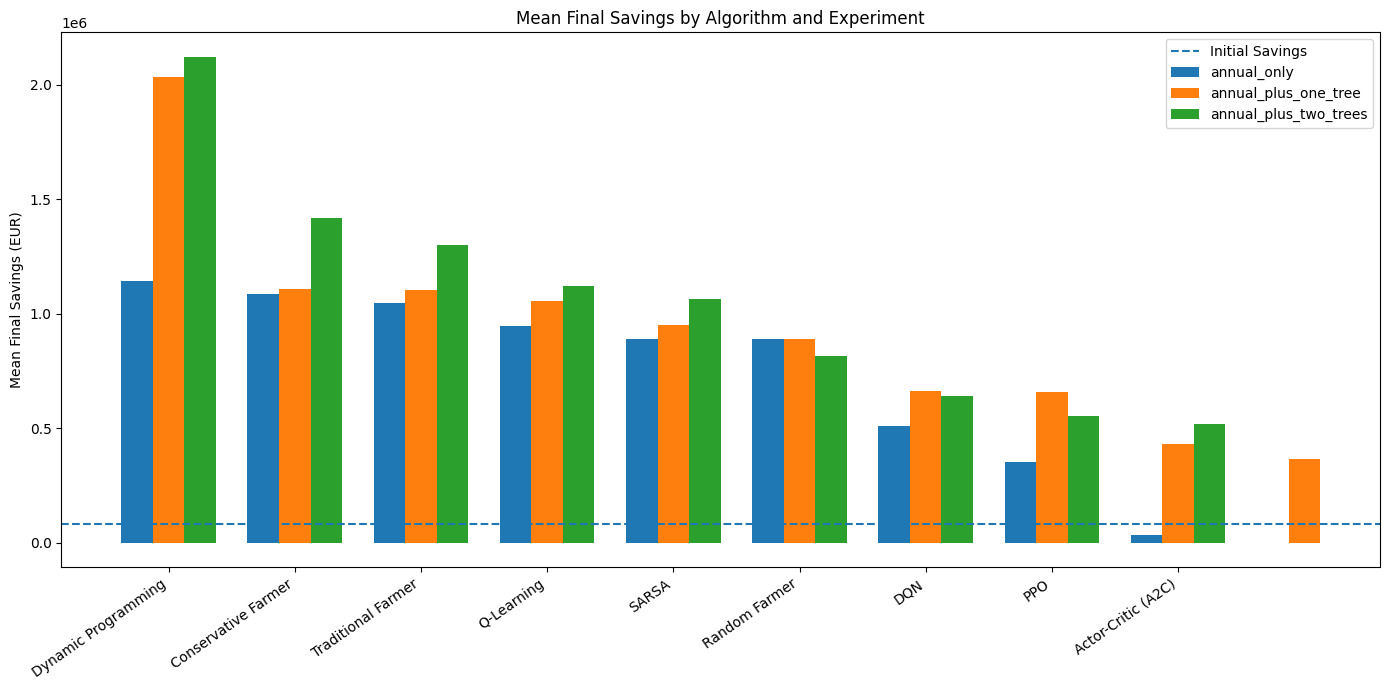

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


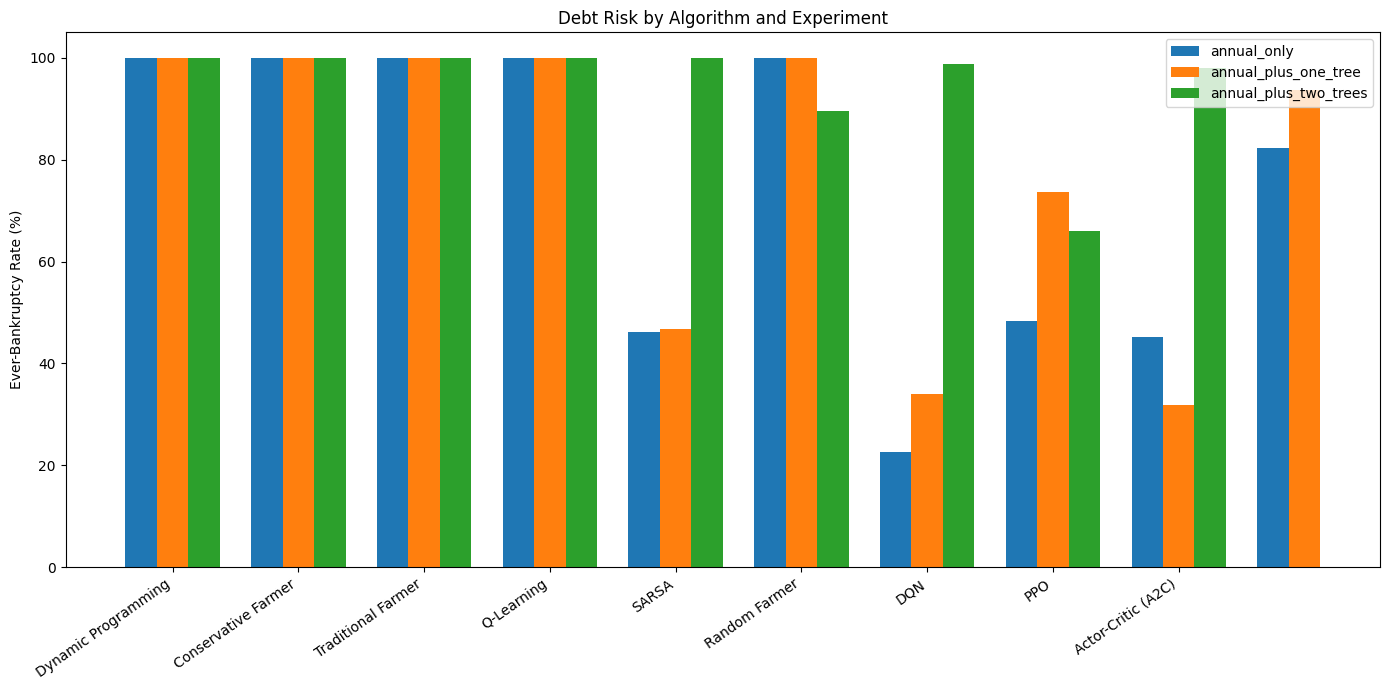

In [ ]:
# =============================================================================
# CELL 20: Visualisation Outputs
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell generates visualisations used for analysing and presenting the
# experimental results.
#
# Visualisation is an important component of this project because it enables:
#
#   - comparative performance analysis,
#   - pattern identification,
#   - clear communication of findings,
#   - and interpretable reinforcement learning evaluation.
#
# The figures generated in this section can be directly included in:
#
#   - dissertation chapters,
#   - presentations,
#   - and research reports.
#
# -----------------------------------------------------------------------------
# Two visualisations are created:
#
#   1. Mean Final Savings by algorithm and experiment
#   2. Bankruptcy Risk by algorithm and experiment
#
# Both plots compare algorithm performance across all farming scenarios.
# -----------------------------------------------------------------------------


# =============================================================================
# VISUALISATION 1:
# Mean Final Savings
# =============================================================================

# -----------------------------------------------------------------------------
# Step 1: Create new figure for plotting.
#
# figsize=(14, 7):
#   Defines figure width and height in inches.
#
# Larger figures improve readability for multiple algorithms.
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 7))

# -----------------------------------------------------------------------------
# Step 2: Iterate through each experiment configuration.
#
# combined_summary_table["Experiment"].unique():
#   Retrieves all unique experiment names.
#
# enumerate():
#   Returns:
#       i           -> experiment index
#       experiment  -> experiment name
# -----------------------------------------------------------------------------
for i, experiment in enumerate(

    combined_summary_table["Experiment"].unique()
):

    # -------------------------------------------------------------------------
    # Step 2.1: Filter summary table for current experiment only.
    #
    # Boolean indexing selects rows matching the experiment name.
    # -------------------------------------------------------------------------
    subset = combined_summary_table[

        combined_summary_table["Experiment"] == experiment
    ]

    # -------------------------------------------------------------------------
    # Step 2.2: Create x-axis positions for grouped bar chart.
    #
    # np.arange(len(subset)):
    #   Creates sequential x positions.
    #
    # + i * 0.25:
    #   Horizontally offsets bars for grouped comparison.
    # -------------------------------------------------------------------------
    x = np.arange(len(subset)) + i * 0.25

    # -------------------------------------------------------------------------
    # Step 2.3: Create bar chart for current experiment.
    #
    # Parameters:
    #
    #   x
    #       x-axis positions
    #
    #   subset["Mean Final Savings (EUR)"]
    #       Heights of bars
    #
    #   width=0.25
    #       Width of each bar
    #
    #   label=experiment
    #       Legend label
    # -------------------------------------------------------------------------
    plt.bar(

        x,

        subset["Mean Final Savings (EUR)"],

        width=0.25,

        label=experiment
    )

# -----------------------------------------------------------------------------
# Step 3: Draw horizontal reference line representing initial savings.
#
# plt.axhline():
#   Creates horizontal line across figure.
#
# linestyle="--":
#   Dashed line style.
#
# Useful for visually identifying algorithms that improve wealth.
# -----------------------------------------------------------------------------
plt.axhline(

    INITIAL_SAVINGS,

    linestyle="--",

    label="Initial Savings"
)

# -----------------------------------------------------------------------------
# Step 4: Label y-axis.
# -----------------------------------------------------------------------------
plt.ylabel("Mean Final Savings (EUR)")

# -----------------------------------------------------------------------------
# Step 5: Add chart title.
# -----------------------------------------------------------------------------
plt.title("Mean Final Savings by Algorithm and Experiment")

# -----------------------------------------------------------------------------
# Step 6: Configure x-axis tick labels.
#
# rotation=35:
#   Rotates algorithm names for readability.
#
# ha="right":
#   Aligns rotated labels neatly.
# -----------------------------------------------------------------------------
plt.xticks(

    np.arange(len(subset)) + 0.25,

    subset["Algorithm"],

    rotation=35,

    ha="right"
)

# -----------------------------------------------------------------------------
# Step 7: Display legend identifying experiment groups.
# -----------------------------------------------------------------------------
plt.legend()

# -----------------------------------------------------------------------------
# Step 8: Automatically adjust plot spacing.
#
# Prevents:
#   - label overlap,
#   - and clipping issues.
# -----------------------------------------------------------------------------
plt.tight_layout()

# -----------------------------------------------------------------------------
# Step 9: Save figure to output directory.
#
# dpi=300:
#   High-resolution image suitable for dissertations and publications.
# -----------------------------------------------------------------------------
plt.savefig(

    "outputs/figures/mean_final_savings_all_experiments.png",

    dpi=300
)

# -----------------------------------------------------------------------------
# Step 10: Display figure inside notebook.
# -----------------------------------------------------------------------------
plt.show()


# =============================================================================
# VISUALISATION 2:
# Bankruptcy Risk
# =============================================================================

# -----------------------------------------------------------------------------
# Step 11: Create new figure for bankruptcy-risk visualisation.
# -----------------------------------------------------------------------------
plt.figure(figsize=(14, 7))

# -----------------------------------------------------------------------------
# Step 12: Iterate through all experiment configurations again.
# -----------------------------------------------------------------------------
for i, experiment in enumerate(

    combined_summary_table["Experiment"].unique()
):

    # -------------------------------------------------------------------------
    # Step 12.1: Filter data for current experiment.
    # -------------------------------------------------------------------------
    subset = combined_summary_table[

        combined_summary_table["Experiment"] == experiment
    ]

    # -------------------------------------------------------------------------
    # Step 12.2: Compute grouped x-axis positions.
    # -------------------------------------------------------------------------
    x = np.arange(len(subset)) + i * 0.25

    # -------------------------------------------------------------------------
    # Step 12.3: Plot bankruptcy-rate bar chart.
    #
    # "Ever-Bankruptcy Rate (%)":
    #   Percentage of episodes where savings became negative at any point.
    # -------------------------------------------------------------------------
    plt.bar(

        x,

        subset["Ever-Bankruptcy Rate (%)"],

        width=0.25,

        label=experiment
    )

# -----------------------------------------------------------------------------
# Step 13: Label y-axis.
# -----------------------------------------------------------------------------
plt.ylabel("Ever-Bankruptcy Rate (%)")

# -----------------------------------------------------------------------------
# Step 14: Add chart title.
#
# This figure visualises financial risk associated with each algorithm.
# -----------------------------------------------------------------------------
plt.title("Debt Risk by Algorithm and Experiment")

# -----------------------------------------------------------------------------
# Step 15: Configure x-axis labels.
# -----------------------------------------------------------------------------
plt.xticks(

    np.arange(len(subset)) + 0.25,

    subset["Algorithm"],

    rotation=35,

    ha="right"
)

# -----------------------------------------------------------------------------
# Step 16: Display legend for experiment categories.
# -----------------------------------------------------------------------------
plt.legend()

# -----------------------------------------------------------------------------
# Step 17: Automatically optimise subplot spacing.
# -----------------------------------------------------------------------------
plt.tight_layout()

# -----------------------------------------------------------------------------
# Step 18: Save bankruptcy-rate figure as high-resolution PNG.
# -----------------------------------------------------------------------------
plt.savefig(

    "outputs/figures/ever_bankruptcy_rate_all_experiments.png",

    dpi=300
)

# -----------------------------------------------------------------------------
# Step 19: Display bankruptcy-rate figure.
# -----------------------------------------------------------------------------
plt.show()

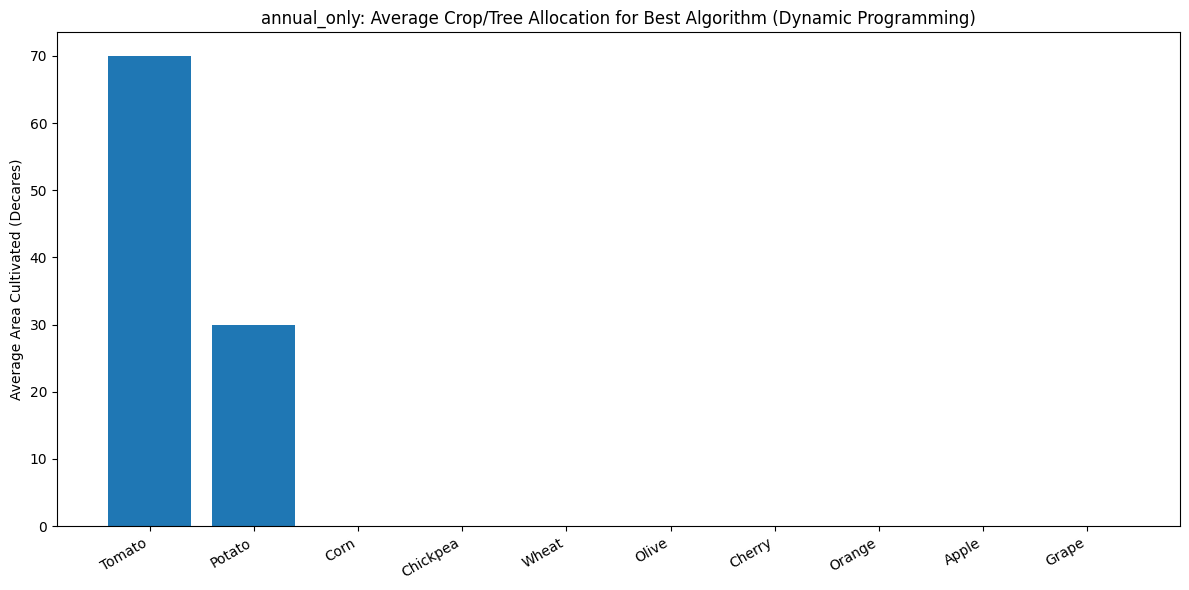

annual_only: best algorithm by mean final savings = Dynamic Programming


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Crop/Tree,Average Area Cultivated,Std Dev Area,Minimum Area,Maximum Area
0,Tomato,70.0,0.0,70.0,70.0
1,Potato,30.0,0.0,30.0,30.0
2,Corn,0.0,0.0,0.0,0.0
3,Chickpea,0.0,0.0,0.0,0.0
4,Wheat,0.0,0.0,0.0,0.0
5,Olive,0.0,0.0,0.0,0.0
6,Cherry,0.0,0.0,0.0,0.0
7,Orange,0.0,0.0,0.0,0.0
8,Apple,0.0,0.0,0.0,0.0
9,Grape,0.0,0.0,0.0,0.0


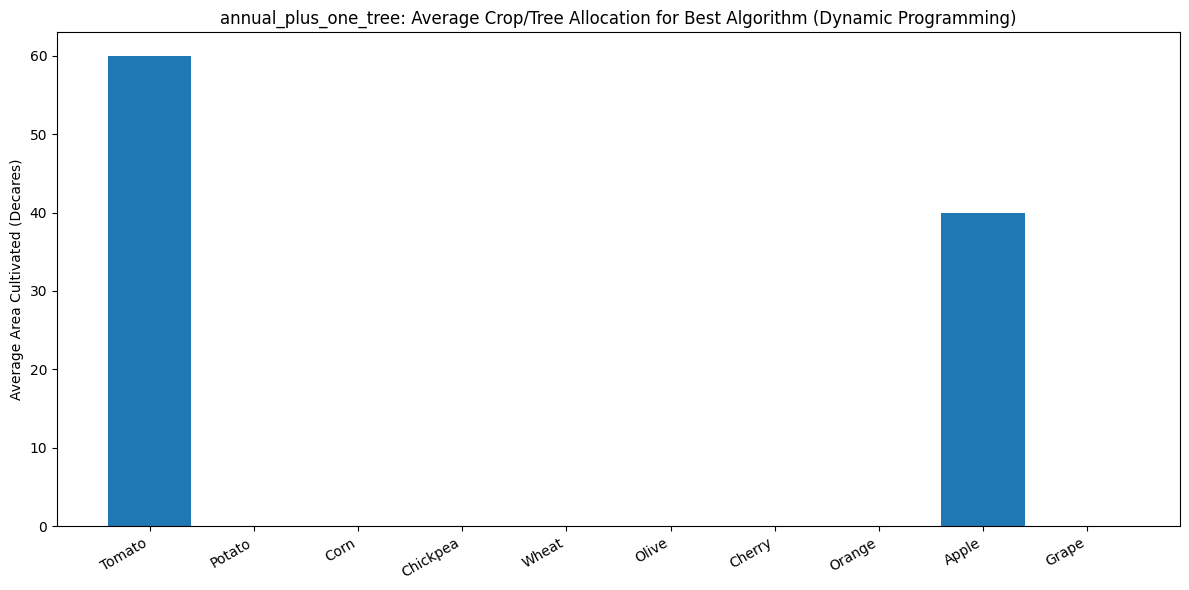

annual_plus_one_tree: best algorithm by mean final savings = Dynamic Programming


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Crop/Tree,Average Area Cultivated,Std Dev Area,Minimum Area,Maximum Area
0,Tomato,60.0,0.0,60.0,60.0
1,Potato,0.0,0.0,0.0,0.0
2,Corn,0.0,0.0,0.0,0.0
3,Chickpea,0.0,0.0,0.0,0.0
4,Wheat,0.0,0.0,0.0,0.0
5,Olive,0.0,0.0,0.0,0.0
6,Cherry,0.0,0.0,0.0,0.0
7,Orange,0.0,0.0,0.0,0.0
8,Apple,40.0,0.0,40.0,40.0
9,Grape,0.0,0.0,0.0,0.0


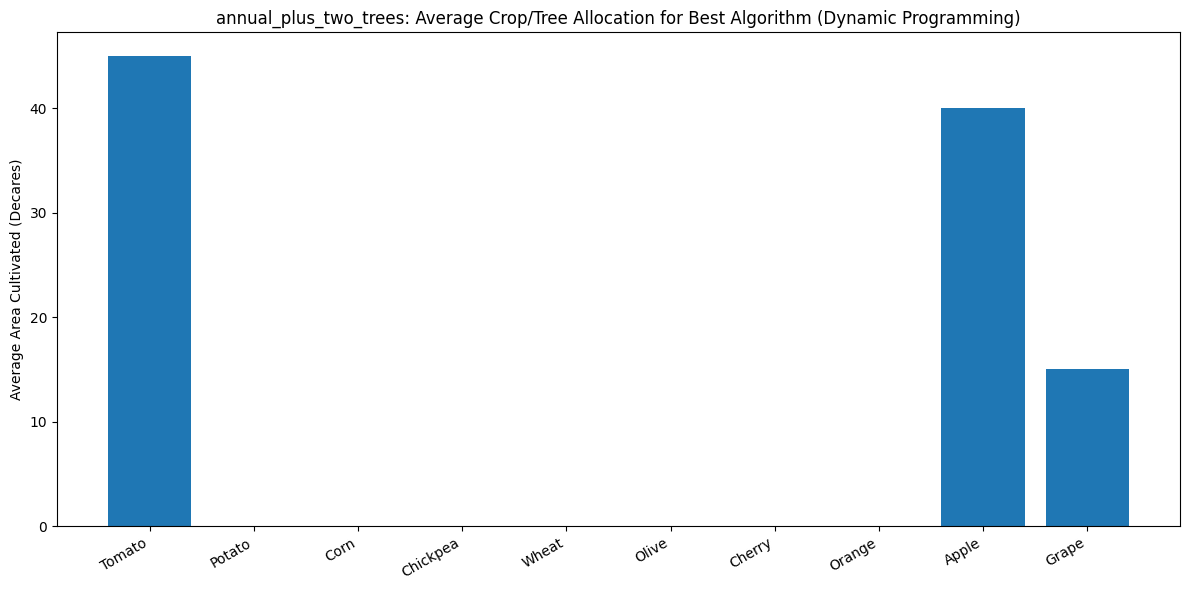

annual_plus_two_trees: best algorithm by mean final savings = Dynamic Programming


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Crop/Tree,Average Area Cultivated,Std Dev Area,Minimum Area,Maximum Area
0,Tomato,45.0,0.0,45.0,45.0
1,Potato,0.0,0.0,0.0,0.0
2,Corn,0.0,0.0,0.0,0.0
3,Chickpea,0.0,0.0,0.0,0.0
4,Wheat,0.0,0.0,0.0,0.0
5,Olive,0.0,0.0,0.0,0.0
6,Cherry,0.0,0.0,0.0,0.0
7,Orange,0.0,0.0,0.0,0.0
8,Apple,40.0,0.0,40.0,40.0
9,Grape,15.0,0.0,15.0,15.0


In [ ]:
# =============================================================================
# CELL 21: Crop Allocation Plots for Best Algorithm in Each Experiment
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell generates crop-allocation visualisations for the best-performing
# algorithm in each experiment configuration.
#
# The purpose of this analysis is to:
#
#   - identify optimal land-allocation strategies,
#   - understand algorithm decision behaviour,
#   - interpret learned agricultural policies,
#   - and compare crop-diversification patterns.
#
# -----------------------------------------------------------------------------
# Policy interpretation is important because high-performing models should not
# only achieve strong financial results, but also provide interpretable and
# explainable agricultural decision strategies.
#
# The generated plots show:
#
#   - average cultivated area per crop/tree type,
#   - land-allocation preferences,
#   - and long-term agricultural planning behaviour
#
# for the best-performing algorithm in each experiment.
# -----------------------------------------------------------------------------


# -----------------------------------------------------------------------------
# Step 1: Iterate through all experiment result dictionaries.
#
# all_results contains:
#
#   - annual_only results
#   - annual_plus_one_tree results
#   - annual_plus_two_trees results
# -----------------------------------------------------------------------------
for result in all_results:

    # -------------------------------------------------------------------------
    # Step 1.1: Retrieve experiment mode name.
    #
    # Examples:
    #   "annual_only"
    #   "annual_plus_one_tree"
    # -------------------------------------------------------------------------
    mode = result["mode"]

    # -------------------------------------------------------------------------
    # Step 1.2: Retrieve summary statistics DataFrame for current experiment.
    # -------------------------------------------------------------------------
    summary = result["summary"]

    # -------------------------------------------------------------------------
    # Step 1.3: Identify best-performing algorithm.
    #
    # sort_values():
    #   Sort algorithms by mean final savings.
    #
    # ascending=False:
    #   Highest-performing algorithm appears first.
    #
    # iloc[0]:
    #   Select first row after sorting.
    # -------------------------------------------------------------------------
    best_algo = (

        summary
        .sort_values(
            "Mean Final Savings (EUR)",
            ascending=False
        )

        .iloc[0]["Algorithm"]
    )

    # -------------------------------------------------------------------------
    # Step 1.4: Retrieve crop-allocation statistics for best algorithm.
    #
    # crop_stats contains:
    #
    #   - average cultivated area,
    #   - standard deviation,
    #   - minimum cultivated area,
    #   - and maximum cultivated area.
    # -------------------------------------------------------------------------
    crop_stats = result["crop_stats"][best_algo]

    # =========================================================================
    # Step 2: Create Crop-Allocation Visualisation
    # =========================================================================

    # -------------------------------------------------------------------------
    # Step 2.1: Create new figure.
    #
    # figsize=(12, 6):
    #   Wider figure improves readability for multiple crops.
    # -------------------------------------------------------------------------
    plt.figure(figsize=(12, 6))

    # -------------------------------------------------------------------------
    # Step 2.2: Create bar chart.
    #
    # x-axis:
    #   Crop/tree names
    #
    # y-axis:
    #   Average cultivated area
    # -------------------------------------------------------------------------
    plt.bar(

        crop_stats["Crop/Tree"],

        crop_stats["Average Area Cultivated"]
    )

    # -------------------------------------------------------------------------
    # Step 2.3: Label y-axis.
    #
    # Unit:
    #   Decares (land-area measurement)
    # -------------------------------------------------------------------------
    plt.ylabel("Average Area Cultivated (Decares)")

    # -------------------------------------------------------------------------
    # Step 2.4: Create figure title dynamically.
    #
    # Includes:
    #   - experiment mode,
    #   - and best algorithm name.
    #
    # f-string formatting improves readability.
    # -------------------------------------------------------------------------
    plt.title(

        f"{mode}: Average Crop/Tree Allocation "
        f"for Best Algorithm ({best_algo})"
    )

    # -------------------------------------------------------------------------
    # Step 2.5: Rotate x-axis labels for readability.
    #
    # rotation=30:
    #   Slight label rotation prevents overlap.
    #
    # ha="right":
    #   Right-align rotated labels.
    # -------------------------------------------------------------------------
    plt.xticks(

        rotation=30,

        ha="right"
    )

    # -------------------------------------------------------------------------
    # Step 2.6: Automatically adjust subplot spacing.
    #
    # Prevents clipping and overlap of labels.
    # -------------------------------------------------------------------------
    plt.tight_layout()

    # -------------------------------------------------------------------------
    # Step 2.7: Save figure to outputs directory.
    #
    # dpi=300:
    #   High-resolution image suitable for dissertation figures.
    # -------------------------------------------------------------------------
    plt.savefig(

        f"outputs/figures/"
        f"{mode}_best_algorithm_crop_allocation.png",

        dpi=300
    )

    # -------------------------------------------------------------------------
    # Step 2.8: Display figure inside notebook.
    # -------------------------------------------------------------------------
    plt.show()

    # =========================================================================
    # Step 3: Display Textual Summary
    # =========================================================================

    # -------------------------------------------------------------------------
    # Step 3.1: Print best-performing algorithm for current experiment.
    #
    # This helps identify strongest methods across scenarios.
    # -------------------------------------------------------------------------
    print(

        f"{mode}: "
        f"best algorithm by mean final savings = {best_algo}"
    )

    # -------------------------------------------------------------------------
    # Step 3.2: Display crop-allocation statistics table.
    #
    # round(2):
    #   Rounds numerical values to 2 decimal places for readability.
    # -------------------------------------------------------------------------
    display(crop_stats.round(2))

In [ ]:
# =============================================================================
# CELL 22: Yearly Policy Schedules and Land-Block Allocation Reports
# =============================================================================
# MSc Data Science Dissertation Project – Final Submission
# =============================================================================
#
# This cell generates detailed yearly policy schedules and land-block
# allocation reports for the best-performing algorithm in each experiment.
#
# The purpose of this analysis is to:
#
#   - interpret learned agricultural policies,
#   - analyse yearly decision behaviour,
#   - evaluate land-allocation strategies,
#   - and improve reinforcement learning explainability.
#
# -----------------------------------------------------------------------------
# The generated outputs include:
#
#   1. Year-by-year policy schedules
#   2. Land-block crop-allocation schedules
#
# These outputs provide detailed insight into:
#
#   - crop-selection behaviour,
#   - tree-investment timing,
#   - cultivated land allocation,
#   - and long-term agricultural planning decisions.
#
# -----------------------------------------------------------------------------
# The exported CSV files can be used for:
#
#   - dissertation appendices,
#   - result interpretation,
#   - visualisation generation,
#   - and agricultural policy analysis.
# -----------------------------------------------------------------------------


# -----------------------------------------------------------------------------
# Step 1: Initialise storage containers for yearly schedule tables.
# -----------------------------------------------------------------------------
yearly_schedule_tables = []

# -----------------------------------------------------------------------------
# Step 2: Initialise storage containers for land-block allocation tables.
# -----------------------------------------------------------------------------
yearly_land_block_tables = []

# -----------------------------------------------------------------------------
# Step 3: Iterate through all experiment result dictionaries.
#
# The experiments include:
#
#   - annual_only
#   - annual_plus_one_tree
#   - annual_plus_two_trees
# -----------------------------------------------------------------------------
for result in [experiment_1_results, experiment_2_results, experiment_3_results]:

    # -------------------------------------------------------------------------
    # Step 3.1: Retrieve experiment mode name.
    # -------------------------------------------------------------------------
    mode = result["mode"]

    # -------------------------------------------------------------------------
    # Step 3.2: Retrieve summary statistics DataFrame.
    # -------------------------------------------------------------------------
    summary = result["summary"]

    # -------------------------------------------------------------------------
    # Step 3.3: Identify best-performing algorithm.
    #
    # Algorithms are ranked using:
    #
    #   Mean Final Savings (EUR)
    #
    # Highest-performing algorithm is selected for policy interpretation.
    # -------------------------------------------------------------------------
    best_algo = (
        summary
        .sort_values("Mean Final Savings (EUR)", ascending=False)
        .iloc[0]["Algorithm"]
    )

    # -------------------------------------------------------------------------
    # Step 3.4: Retrieve trained model or policy objects for best algorithm.
    # -------------------------------------------------------------------------
    trained_kwargs = result["trained"][best_algo]

    # -------------------------------------------------------------------------
    # Step 3.5: Display progress information.
    # -------------------------------------------------------------------------
    print(
        f"Generating yearly policy schedule for "
        f"{mode}: {best_algo}"
    )

    # -------------------------------------------------------------------------
    # Step 3.6: Generate yearly policy and land-block schedules.
    #
    # Outputs:
    #
    #   schedule_df
    #       Year-by-year policy decisions
    #
    #   land_block_df
    #       Land-block crop-allocation details
    # -------------------------------------------------------------------------
    schedule_df, land_block_df = generate_yearly_policy_schedule(
        mode=mode,
        algorithm=best_algo,
        **trained_kwargs
    )

    # -------------------------------------------------------------------------
    # Step 3.7: Store generated schedule tables.
    # -------------------------------------------------------------------------
    yearly_schedule_tables.append(schedule_df)

    yearly_land_block_tables.append(land_block_df)

    # -------------------------------------------------------------------------
    # Step 3.8: Create filesystem-safe experiment name.
    # -------------------------------------------------------------------------
    safe_mode = mode.replace(" ", "_")

    # -------------------------------------------------------------------------
    # Step 3.9: Create filesystem-safe algorithm name.
    # -------------------------------------------------------------------------
    safe_algo = (
        best_algo
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
    )

    # -------------------------------------------------------------------------
    # Step 3.10: Export yearly policy schedule to CSV.
    # -------------------------------------------------------------------------
    schedule_df.to_csv(
        f"outputs/policies/{safe_mode}_{safe_algo}_yearly_policy_schedule.csv",
        index=False
    )

    # -------------------------------------------------------------------------
    # Step 3.11: Export land-block allocation schedule to CSV.
    # -------------------------------------------------------------------------
    land_block_df.to_csv(
        f"outputs/policies/{safe_mode}_{safe_algo}_land_block_schedule.csv",
        index=False
    )

    # -------------------------------------------------------------------------
    # Step 3.12: Display export completion message.
    # -------------------------------------------------------------------------
    print(
        "Yearly policy schedules and land-block reports "
        "saved successfully."
    )

    # -------------------------------------------------------------------------
    # Step 3.13: Display sample yearly policy schedule rows.
    #
    # head(3):
    #   Displays first three rows for readability.
    # -------------------------------------------------------------------------
    display(schedule_df.head(3))

    # -------------------------------------------------------------------------
    # Step 3.14: Display sample land-block allocation rows.
    #
    # head(5):
    #   Displays first five rows for readability.
    # -------------------------------------------------------------------------
    display(land_block_df.head(5))


# -----------------------------------------------------------------------------
# Step 4: Combine all yearly policy schedules into one DataFrame.
#
# ignore_index=True:
#   Resets row indices after concatenation.
# -----------------------------------------------------------------------------
combined_yearly_schedule_df = pd.concat(
    yearly_schedule_tables,
    ignore_index=True
)

# -----------------------------------------------------------------------------
# Step 5: Combine all land-block schedules into one DataFrame.
# -----------------------------------------------------------------------------
combined_land_block_schedule_df = pd.concat(
    yearly_land_block_tables,
    ignore_index=True
)

# -----------------------------------------------------------------------------
# Step 6: Export combined yearly policy schedule table.
# -----------------------------------------------------------------------------
combined_yearly_schedule_df.to_csv(
    "outputs/final_yearly_policy_schedule_best_algorithms.csv",
    index=False
)

# -----------------------------------------------------------------------------
# Step 7: Export combined land-block allocation schedule table.
# -----------------------------------------------------------------------------
combined_land_block_schedule_df.to_csv(
    "outputs/final_land_block_crop_schedule_best_algorithms.csv",
    index=False
)

# -----------------------------------------------------------------------------
# Step 8: Display final completion message.
# -----------------------------------------------------------------------------
print(
    "Yearly policy schedules and land-block allocation "
    "reports generated successfully."
)

Generating yearly policy schedule for annual_only: Dynamic Programming
Yearly policy schedules and land-block reports saved successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Experiment,Algorithm,Year,Planning Decision Period,Action Index,Action Plan,Active Crops/Trees,Savings End of Year,Savings After Upfront Cost,Tree Plan Fixed,Tree First Planted Year,Fixed Tree Names,Cold Happened,Low Rain Happened
0,annual_only,Dynamic Programming,1,Start of agricultural year,1,Tomato 70; Potato 30,"Tomato, Potato",122564.199648,-31722.198708,False,None,,False,False
1,annual_only,Dynamic Programming,2,Start of agricultural year,1,Tomato 70; Potato 30,"Tomato, Potato",188124.642046,7248.049976,False,None,,False,False
2,annual_only,Dynamic Programming,3,Start of agricultural year,1,Tomato 70; Potato 30,"Tomato, Potato",256065.321118,80025.994200,False,None,,False,False


,Land Block,Block Size (Decares),Crop/Tree,Allocated Area in Block,Planting Period,Harvest Period,Experiment,Algorithm,Year,Action Index
0,Block 1,15,Tomato,15.0,Spring,Summer,annual_only,Dynamic Programming,1,1
1,Block 2,15,Tomato,15.0,Spring,Summer,annual_only,Dynamic Programming,1,1
2,Block 3,20,Tomato,20.0,Spring,Summer,annual_only,Dynamic Programming,1,1
3,Block 4,20,Tomato,20.0,Spring,Summer,annual_only,Dynamic Programming,1,1
4,Block 5,30,Potato,30.0,Spring,Summer/Autumn,annual_only,Dynamic Programming,1,1


Generating yearly policy schedule for annual_plus_one_tree: Dynamic Programming
Yearly policy schedules and land-block reports saved successfully.


...

,Experiment,Algorithm,Year,Planning Decision Period,Action Index,Action Plan,Active Crops/Trees,Savings End of Year,Savings After Upfront Cost,Tree Plan Fixed,Tree First Planted Year,Fixed Tree Names,Cold Happened,Low Rain Happened
0,annual_plus_two_trees,Dynamic Programming,1,Start of agricultural year,1155,Tomato 45; Apple 40; Grape 15,"Tomato, Apple, Grape",68658.812825,-12670.773799,True,1,"apple, grape",False,False
1,annual_plus_two_trees,Dynamic Programming,2,Start of agricultural year,1155,Tomato 45; Apple 40; Grape 15,"Tomato, Apple, Grape",81371.349305,-22068.403576,True,1,"apple, grape",False,False
2,annual_plus_two_trees,Dynamic Programming,3,Start of agricultural year,1155,Tomato 45; Apple 40; Grape 15,"Tomato, Apple, Grape",76728.575501,-17313.800342,True,1,"apple, grape",False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Land Block,Block Size (Decares),Crop/Tree,Allocated Area in Block,Planting Period,Harvest Period,Experiment,Algorithm,Year,Action Index
0,Block 1,15,Tomato,15.0,Spring,Summer,annual_plus_two_trees,Dynamic Programming,1,1155
1,Block 2,15,Tomato,15.0,Spring,Summer,annual_plus_two_trees,Dynamic Programming,1,1155
2,Block 3,20,Tomato,15.0,Spring,Summer,annual_plus_two_trees,Dynamic Programming,1,1155
3,Block 3,20,Apple,5.0,Winter/Spring,Autumn after maturity,annual_plus_two_trees,Dynamic Programming,1,1155
4,Block 4,20,Apple,20.0,Winter/Spring,Autumn after maturity,annual_plus_two_trees,Dynamic Programming,1,1155


Yearly policy schedules and land-block allocation reports generated successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 14. Report Interpretation Guidance

The highest final-savings result should not automatically be interpreted as the best overall algorithm.

The evaluation objective contains two important components:

1. maximise long-term final savings;
2. avoid negative savings during the 30-year planning horizon.

Therefore, the discussion should compare:

* final savings;
* minimum savings observed during the simulation;
* ever-bankruptcy rate;
* crop-selection behaviour;
* whether tree investments improve or worsen long-term outcomes;
* whether the algorithm adopts highly concentrated monoculture strategies, such as allocating all land to tomato cultivation;
* and the timing of tree planting decisions within years 1–10.

The policy-analysis tables should be used to directly interpret:

* learned agricultural strategies,
* long-term investment behaviour,
* land-allocation decisions,
* and reinforcement learning policy preferences across experiments and algorithms.
